# 020. CLIP と対照学習 / CLIP and Contrastive Learning

## 1. 概要 / Overview

CLIP(Contrastive Language-Image Pre-training)は、画像とその説明文の組から、**どの文がどの画像に対応するか** を当てる対照学習
(Contrastive Learning)で、画像 encoder とテキスト encoder を同時に学習する(Radford et al. [1])。学習後は、クラス名から作った文の
埋め込みを分類器の重みとして使うことで、事前に決めたクラスの集合に依存しない zero-shot 分類ができる。本トピックでは、019 の ViT を
画像 encoder、因果マスクつきの Transformer(008 の小型 GPT と同じ構造)をテキスト encoder とする二重 encoder(dual encoder)を
スクラッチ実装し、規則で生成した合成の画像とキャプション(2 つの図形の色・形・位置関係)で学習する。学習に一度も出てこない
(色, 形) の組み合わせを含む画像での zero-shot の検索を指標として、(A)sigmoid 損失(SigLIP [4])の softmax 損失(InfoNCE [2])に
対する優位が、バッチサイズが大きいほど縮むか、(B)標準の対照学習で、語順・属性の結びつきが問われる 2 択の正解率が、ランダムな
負例との 2 択より低いか(bag-of-words 化 [5])、(C)困難な負例(hard negative)のキャプションを分母に加える NegCLIP [5] で、その
正解率が上がるか、を検証する。画像とテキストの埋め込みが別々の領域に分かれる modality gap [6] は、判定なしで観察する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
学習で見る事例数 $E$ の候補 $\{2^{19}, 2^{18}\}$ と **削る段階** 0〜3 を組み合わせた 8 通りの **実行計画**(6.1 節)のそれぞれに
ついて残りの実行時間を見積もり、予算に収まる計画のうち優先順位の最も高いもの($E$ の大きいものを優先)を自動で選ぶ。選択は
見積もりのみに基づき、どの実験の結果も参照しない。最も軽い計画でも予算を超える場合は、学習の前に例外で停止する。**選ばれた計画・
$E$・段階は 6.4 節の出力に印字される。** 本番の Colab での実行はこの 1 回だけで、事前の計測のための実行やセッションの分割はしない。

実験 C の NegCLIP・シード 0 のモデル(両方の encoder と射影)は、021 の入力になりうるので Hugging Face Hub の
`kojikojiprg/ai-theories-clip-synthetic-scenes`にアップロードする(6.13 節)。アップロードは`UPLOAD_ARTIFACTS = True`にしたときだけ
行う(既定は`False`、`SMOKE_TEST`とは独立)。

## 2. 参考論文 / References

1. Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G.,
   Sutskever, I., "Learning Transferable Visual Models From Natural Language Supervision", ICML 2021.
   https://arxiv.org/abs/2103.00020(本トピックの原典。3.1〜3.3・3.6・3.9 節)
2. van den Oord, A., Li, Y., Vinyals, O., "Representation Learning with Contrastive Predictive Coding", arXiv 2018.
   https://arxiv.org/abs/1807.03748(InfoNCE 損失と相互情報量の下界。3.3・3.4 節)
3. Poole, B., Ozair, S., van den Oord, A., Alemi, A. A., Tucker, G., "On Variational Bounds of Mutual Information", ICML 2019.
   https://arxiv.org/abs/1905.06922(InfoNCE の下界の厳密な導出と $\log K$ による頭打ち。3.4 節)
4. Zhai, X., Mustafa, B., Kolesnikov, A., Beyer, L., "Sigmoid Loss for Language Image Pre-Training", ICCV 2023.
   https://arxiv.org/abs/2303.15343(SigLIP。3.5 節、実験 A)
5. Yuksekgonul, M., Bianchi, F., Kalluri, P., Jurafsky, D., Zou, J.,
   "When and Why Vision-Language Models Behave like Bags-Of-Words, and What to Do About It?", ICLR 2023.
   https://arxiv.org/abs/2210.01936(bag-of-words 化と NegCLIP。3.7 節、実験 B・C)
6. Liang, W., Zhang, Y., Kwon, Y., Yeung, S., Zou, J.,
   "Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning", NeurIPS 2022.
   https://arxiv.org/abs/2203.02053(modality gap。3.8 節、6.10 節の観察)
7. Zhai, X., Wang, X., Mustafa, B., Steiner, A., Keysers, D., Kolesnikov, A., Beyer, L.,
   "LiT: Zero-Shot Transfer with Locked-image text Tuning", CVPR 2022. https://arxiv.org/abs/2111.07991(3.9 節、位置づけのみ)
8. Jia, C., Yang, Y., Xia, Y., Chen, Y.-T., Parekh, Z., Pham, H., Le, Q. V., Sung, Y., Li, Z., Duerig, T.,
   "Scaling Up Visual and Vision-Language Representation Learning With Noisy Text Supervision", ICML 2021.
   https://arxiv.org/abs/2102.05918(ALIGN。3.9 節、位置づけのみ)
9. Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M.,
   Heigold, G., Gelly, S., Uszkoreit, J., Houlsby, N.,
   "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale", ICLR 2021.
   https://arxiv.org/abs/2010.11929(ViT。画像 encoder、3.2 節)

本文で用いる既存トピックの部品: 多頭注意機構(Multi-Head Attention)と Decoder Block は
[001](../01_foundations/001_attention_mechanism.ipynb)・[002](../01_foundations/002_transformer_block.ipynb)、GELU は
[004](../01_foundations/004_normalization_and_activation.ipynb)、因果マスクつきの decoder-only のモデルは
[006](../02_pretraining/006_pretraining_small_gpt.ipynb)・[008](../02_pretraining/008_decoding_strategies.ipynb)、AdamW・warmup + cosine・
gradient clipping は [007](../02_pretraining/007_training_stabilization.ipynb)、混合精度学習は
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、ViT は [019](./019_vision_transformer.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 自然言語を教師信号にする

019 の ViT は、CIFAR-10 の 10 クラスのように **事前に決めたクラスの集合** のラベルで学習した。この方式には 2 つの制約がある。
(1)ラベル付けに人手がかかり、データの規模を増やしにくい。(2)学習したモデルが出力できるのは学習時のクラスだけであり、
新しいクラスを認識させるには、そのクラスのラベル付きデータで追加の学習が要る。

CLIP(Contrastive Language-Image Pre-training、Radford et al. [1])は、インターネットから集めた画像とその説明文(alt テキストなど)の
組 4 億個を使い、**どの文がどの画像に付いていたかを当てる** 課題で、画像 encoder とテキスト encoder を同時に学習する。自然言語は
人手のラベル付けなしに大量に集まり、しかも「クラスの集合」に縛られない。学習後は、クラス名から作った文(例: `a photo of a dog.`)の
テキストの埋め込みを分類器の重みとして使えば、**そのクラスの画像を 1 枚も学習していなくても** 分類できる(zero-shot 分類、3.6 節)。

原論文(2.3 節)は、画像から説明文を生成する予測的な目的関数よりも、正しい組を選ぶ **対照的な(contrastive)** 目的関数のほうが、
同じ zero-shot の正解率に達するまでの学習の効率が高かったと報告している。文の正確な単語列を当てるより、「どの文が対応するか」を
区別するほうが易しい課題であるためと説明されている。

本トピックでは、この対照学習を、規則で生成した合成の画像とキャプションでスクラッチ実装する。合成データなので、
(1)学習に一度も出てこない (色, 形) の組み合わせを含む画像で zero-shot の検索を評価でき、(2)語順や属性の結びつきだけが
異なる困難な負例(hard negative)を規則で正確に作れる。

### 3.2 二重 encoder(Dual Encoder)の構造

**記号**:

- $x$: 画像、$y$: テキスト(トークン列)。$N$: バッチサイズ。$(x_i, y_i)$($i = 1, \dots, N$)がバッチ内の正例の組。
- $f_I$: 画像 encoder。019 の ViT で、最終層の [CLS] トークンの位置の表現を層正規化したもの $f_I(x) \in \mathbb{R}^{d_i}$ を返す($d_i$ は画像 encoder の出力次元)。
- $f_T$: テキスト encoder。因果マスクつきの Transformer で、終端トークン(`<eot>`)の位置の表現を層正規化したもの $f_T(y) \in \mathbb{R}^{d_t}$ を返す($d_t$ はテキスト encoder の出力次元)。
- $W_I \in \mathbb{R}^{d_i \times d_e}$・$W_T \in \mathbb{R}^{d_t \times d_e}$: 共通の埋め込み空間(次元 $d_e$)への線形射影(バイアスなし)。
  記号 $d_i$・$d_t$・$d_e$ は CLIP の原論文の図 3 の擬似コードに従う(本トピックでは $E$ を学習で見る事例数に使う)。
- 埋め込み: $u_i = \dfrac{f_I(x_i) W_I}{\lVert f_I(x_i) W_I \rVert}$、$v_j = \dfrac{f_T(y_j) W_T}{\lVert f_T(y_j) W_T \rVert}$(L2 正規化して単位球面に載せる)。
- 類似度: $s_{ij} = u_i^\top v_j \in [-1, 1]$(コサイン類似度)。

**テキスト encoder**: 原論文(2.4 節)のテキスト encoder は、GPT-2 と同じ因果マスクつき(masked self-attention)の Transformer であり、
系列の先頭と末尾に開始・終端のトークンを置き、**最終層の終端トークンの位置の活性化** を層正規化して線形射影したものを文の表現とする。
因果マスクは、事前学習済みの言語モデルで初期化したり、言語モデルの損失を補助的に加えたりする余地を残すために使われている。
これは 008 の小型 GPT(`GPTLanguageModel`)と同じ構造(002 の Decoder Block を交差注意なしで積み、因果マスクを掛ける)であり、
違いは、語彙への射影で次のトークンを予測する代わりに、終端トークンの位置の特徴を文の埋め込みにする点である。因果マスクのもとでは、
終端トークンの位置は文の全トークンを参照できる唯一の位置であり、それより後ろのパディングは終端トークンの特徴に影響しない
(5.4 節で確かめる)。位置の情報は、CLIP と同じ学習可能な絶対位置埋め込みで与える(008 は RoPE)。

```mermaid
flowchart LR
    img["画像 x_i"] --> vit["画像 encoder f_I<br/>(019 の ViT、[CLS] の表現)"]
    vit --> pi["射影 W_I"] --> ni["L2 正規化 -> u_i"]
    txt["キャプション y_j<br/>[sot] a red circle ... [eot]"] --> tt["テキスト encoder f_T<br/>(因果マスクつき、008 と同じ構造)"]
    tt --> eot["[eot] の位置の表現"] --> pt["射影 W_T"] --> nt["L2 正規化 -> v_j"]
    ni --> sim["類似度 s_ij = u_i^T v_j<br/>(N x N の行列)"]
    nt --> sim
    sim --> loss["対照学習の損失<br/>(softmax / sigmoid / NegCLIP)"]
```

### 3.3 対称な InfoNCE 損失と学習可能な温度

**記号**(3.2 節に加えて): $\tau > 0$ は温度(temperature)、$t = \log(1/\tau)$ は温度を表す学習可能なスカラー、$\ell_{ij} = e^{t} s_{ij} = s_{ij}/\tau$ は logits である。

CLIP の損失は、類似度の行列 $\ell \in \mathbb{R}^{N \times N}$ の各行(画像 → テキスト)と各列(テキスト → 画像)を、それぞれ $N$ クラスの
分類とみなした交差エントロピーの平均である(原論文の図 3 の擬似コード)。

$$
\mathcal{L}_{I \to T} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\ell_{ii})}{\sum_{j=1}^{N} \exp(\ell_{ij})}, \qquad
\mathcal{L}_{T \to I} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\ell_{ii})}{\sum_{j=1}^{N} \exp(\ell_{ji})}, \qquad
\mathcal{L}_{\mathrm{CLIP}} = \frac{1}{2}\left(\mathcal{L}_{I \to T} + \mathcal{L}_{T \to I}\right)
$$

各項は、van den Oord et al. [2] の InfoNCE 損失(3.4 節)と同じ形である。

**温度の扱い**: 埋め込みは単位球面上にあるので $s_{ij} \in [-1, 1]$ であり、そのままでは logits の幅が 2 しかなく、softmax の出力が
一様分布から離れられない。$1/\tau$ 倍して幅を広げる。原論文(2.5 節)は $\tau$ を手で調整する代わりに、対数でパラメータ化した
$t = \log(1/\tau)$ を学習し、初期値を $\tau = 0.07$ とし、学習が不安定にならないよう logits の倍率 $e^t$ を 100 以下に切り詰める。
本実装も同じく、各ステップの更新の後に $t \le \log 100$ に切り詰める。

**勾配と負例の役割**: 画像 → テキストの項の、類似度 $s_{ij}$ に対する勾配は

$$
\frac{\partial \mathcal{L}_{I \to T}}{\partial s_{ij}} = \frac{1}{N \tau}\left(p_{ij} - \delta_{ij}\right), \qquad
p_{ij} = \frac{\exp(\ell_{ij})}{\sum_{k=1}^{N} \exp(\ell_{ik})}
$$

である($\delta_{ij}$ はクロネッカーのデルタ)。負例 $j \ne i$ を押し下げる力は、その負例の softmax の確率 $p_{ij}$ に比例する。すでに
正例と十分に見分けられている負例は $p_{ij} \approx 0$ で、学習に寄与しない。**損失が学習を促すのは、バッチの中にある見分けにくい
負例だけである。** 見分けるのに語順や属性の結びつきが必要な負例がバッチにほとんど現れなければ、それを学ぶ誘因は弱い(3.7 節)。

### 3.4 InfoNCE は相互情報量の下界であり、下界は $\log N$ で頭打ちになる

**記号**: $(X, Y)$ は同時分布 $p(x, y)$ に従う確率変数(画像とテキスト)、$p(x)$・$p(y)$ は周辺分布、
$I(X; Y) = \mathbb{E}_{p(x, y)}\left[\log \dfrac{p(x, y)}{p(x) p(y)}\right]$ は相互情報量(mutual information)。
$g(x, y)$ は任意の実数値の関数(critic。CLIP では $g(x, y) = \ell = s/\tau$)。$K$ は 1 つの問題の候補の数(CLIP では $K = N$)。

**設定**: $x_1$ とその正例 $y_1 \sim p(y \mid x_1)$ を 1 つ引き、負例 $y_2, \dots, y_K$ を周辺分布 $p(y)$ から独立に引く。InfoNCE 損失は

$$
\mathcal{L}_{\mathrm{NCE}} = -\mathbb{E}\left[\log \frac{e^{g(x_1, y_1)}}{\sum_{j=1}^{K} e^{g(x_1, y_j)}}\right]
$$

である。van den Oord et al. [2](2.3 節と付録)は、これが $I(X; Y) \ge \log K - \mathcal{L}_{\mathrm{NCE}}$ を満たすことを示した。
Poole et al. [3] は、これを NWJ の下界(Nguyen, Wainwright, Jordan の変分下界)から厳密に導いた。その道筋を示す。

**NWJ の下界**: 任意の関数 $h$ に対して $I(A; B) \ge \mathbb{E}_{p(a, b)}[h(a, b)] - e^{-1}\, \mathbb{E}_{p(a) p(b)}[e^{h(a, b)}]$。
これは KL ダイバージェンスの変分表現(Fenchel 双対)から得られる。

**導出**:

1. $A = X_1$、$B = Y_{1:K} = (y_1, \dots, y_K)$ とする。$y_2, \dots, y_K$ は $X_1$ とも $y_1$ とも独立なので、
   $I(X_1; Y_{1:K}) = I(X_1; y_1) = I(X; Y)$ である。
2. NWJ の下界に $h = 1 + \log \dfrac{e^{g(x_1, y_1)}}{a(x_1, y_{1:K})}$、$a(x_1, y_{1:K}) = \dfrac{1}{K} \sum_{j=1}^{K} e^{g(x_1, y_j)}$ を代入する。
3. 第 2 項の期待値は周辺分布の積 $p(x_1) p(y_{1:K})$ のもとでとる。このとき $y_1, \dots, y_K$ はすべて $x_1$ と独立に同じ分布に従うので、
   添字について対称であり、$\mathbb{E}\left[e^{g(x_1, y_1)}/a\right] = \frac{1}{K} \sum_{i=1}^{K} \mathbb{E}\left[e^{g(x_1, y_i)}/a\right] = \mathbb{E}[K a / (K a)] = 1$。
   よって $e^{-1}\, \mathbb{E}[e^{h}] = e^{-1} \cdot e \cdot 1 = 1$。
4. 代入すると $I(X; Y) \ge 1 + \mathbb{E}_{p}\left[\log \dfrac{e^{g(x_1, y_1)}}{a}\right] - 1
   = \mathbb{E}_{p}\left[\log \dfrac{e^{g(x_1, y_1)}}{\sum_j e^{g(x_1, y_j)}}\right] + \log K = \log K - \mathcal{L}_{\mathrm{NCE}}$。$\square$

**頭打ち**: $\sum_{j} e^{g(x_1, y_j)} \ge e^{g(x_1, y_1)}$ なので、期待値の中の対数は常に 0 以下であり、$\mathcal{L}_{\mathrm{NCE}} \ge 0$。したがって
下界 $\log K - \mathcal{L}_{\mathrm{NCE}}$ は **どんな critic を使っても $\log K$ を超えない**。真の相互情報量が $\log K$ より大きいとき、損失を
下げきっても下界はそこで止まる。CLIP では $K = N$(バッチサイズ)なので、負例の数 $N - 1$ を増やすほど、推定できる相互情報量の
上限が上がる。対照学習で大きなバッチが有利とされる理由の 1 つである(CLIP の原論文のバッチサイズは 32,768)。

**注意**: これは損失の値が表せる範囲についての主張であり、「バッチが大きいほど下流の正解率が上がる」ことを直接には意味しない。
また、本トピックのバッチは同じキャプションを重複させないように作る(5.3 節)ので、負例は $p(y)$ からの独立な抽出ではなく、
正例と異なるキャプションからの非復元抽出になる。上の導出の独立性の仮定からのずれである。

### 3.5 sigmoid 損失(SigLIP)

**記号**: $t'$ は学習可能なスカラー(倍率 $e^{t'}$ の対数)、$b$ は学習可能なバイアス、$z_{ij} = 1$($i = j$)または $-1$($i \ne j$)は
組 $(i, j)$ が正例かどうかのラベル、$\sigma(a) = 1/(1 + e^{-a})$ はシグモイド関数。

Zhai et al. [4] の SigLIP(Sigmoid Loss for Language Image Pre-training)は、$N^2$ 個の組のそれぞれを、正例か負例かの **独立な二値分類**
として扱う(原論文の Algorithm 1)。

$$
\mathcal{L}_{\mathrm{sig}} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{N} \log \sigma\big(z_{ij} (e^{t'} s_{ij} + b)\big)
$$

- **初期値**: 原論文は $t' = \log 10$、$b = -10$ とする。バッチの組のうち正例は $N$ 個、負例は $N^2 - N$ 個で、負例が圧倒的に多い。
  $b = -10$ から始めると、初期状態の予測が「すべて負例」に近くなり、この不均衡による大きな初期の損失と勾配を避けられる。
- **softmax との違い**: softmax の損失は、各行・各列の分母 $\sum_j \exp(\ell_{ij})$ に **バッチ全体** が入る。1 つの組の損失が、同じ
  バッチの他のすべての組に依存する(分散学習では全デバイスの埋め込みを集め、正規化のために行方向と列方向の 2 回の集計が要る)。
  sigmoid の損失は組ごとに独立で、バッチ全体の正規化を要しない。
- **原論文の主張**(本トピックの実験 A の対象): 小さいバッチでは sigmoid の損失が softmax の損失より明らかに優れ、バッチを大きく
  するにつれて差が縮む(原論文のバッチサイズの比較)。原論文の比較は本トピックよりはるかに大きいバッチ(数百以上)であり、本トピックの
  $N \in \{16, 64, 256\}$ はそれよりずっと小さい。本トピックは、同じ傾向が小さい規模でも現れるかを確かめる。
- softmax の損失は行ごとに定数を加えても変わらないので、バイアス $b$ は意味を持たない。本実装では、softmax の損失のときバイアスの
  パラメータを持つが損失に使わない(勾配が計算されず、更新されない)。

sigmoid の損失は 3.4 節の InfoNCE の形ではないので、「下界が $\log N$ で頭打ちになる」という議論はそのままは当てはまらない。
各負例の組が、正規化の分母を通さずに直接損失に入る点が、バッチサイズへの依存の違いの源になっている。

### 3.6 zero-shot 分類・prompt・線形 probe(位置づけ)

- **zero-shot 分類**: クラス $k$ の名前から文 $y_k$(例: `a photo of a {label}.`)を作り、その埋め込み $v_k$ を分類器の重みとして、
  $\hat{k} = \arg\max_k u^\top v_k$ で予測する。学習時に特定のクラスの集合を使わないので、評価のたびにクラスの集合を変えられる。
  本トピックの評価(6.1 節)は、候補のキャプションの集合を「クラス」とみなした、同じ形の検索である。
- **prompt テンプレートと prompt ensembling**(原論文 3.1.4 節): クラス名 1 語だけでは、学習データの文(説明文)と分布が違ううえ、
  多義語の区別もつかない。`a photo of a {label}.`のようなテンプレートに埋めるだけで正解率が上がり、さらに複数のテンプレート
  (ImageNet では 80 個)から作った埋め込みを平均すると上がる。原論文は、この 2 つで ImageNet の正解率がおよそ 5 ポイント上がったと
  報告している。本トピックのキャプションは規則で生成するので、学習と評価で文の形が一致しており、テンプレートは使わない。
- **線形 probe との比較**(原論文 3.1.5 節・3.2 節): 画像 encoder を固定して、その特徴にロジスティック回帰を学習する評価(線形 probe)と
  比べた。原論文は、zero-shot の CLIP が、27 のデータセットのうち 16 で、ResNet-50 の特徴に対する全データの線形 probe を上回ったと
  報告している。一方、同じ CLIP の特徴に対する線形 probe は zero-shot より高く、zero-shot は特徴の持つ情報をすべて引き出しては
  いない。本トピックでは線形 probe は扱わない。

### 3.7 bag-of-words 化と NegCLIP

**現象**: Yuksekgonul et al. [5] は、属性の結びつき(`the paved road and the white house`と`the white road and the paved house`)、
関係(`the horse is eating the grass`と`the grass is eating the horse`)、語順の入れ替えを見分ける課題(ARO ベンチマーク)で、CLIP を
含む Vision-Language モデルの正解率がチャンス水準の付近かそれ以下になることを示した。単語の集合(bag of words)としては同じ 2 つの
文を区別できないので、モデルは文を **単語の袋として** 扱っている(bag-of-words 化)、と解釈される。

**原因の説明**: 対照学習で文を正しく選ぶには、バッチ内の負例と区別できれば十分である。ランダムに集めた負例の文は、
正例の文と単語そのものが違うことがほとんどで、**単語の集合を見るだけで見分けられる**。3.3 節の勾配の式のとおり、損失は見分けにくい
負例にしか学習を促さないので、語順や属性の結びつきを表現する誘因が弱い。

**NegCLIP**: 語順や属性を入れ替えた **困難な負例のキャプション** を規則で作り、画像 → テキスト方向の分母に加える。
記号: $\tilde{v}_k$($k = 1, \dots, M$)は、バッチ内の各正例のキャプションから作った困難な負例の埋め込み($M$ はバッチ全体の困難な負例の数)。

$$
\mathcal{L}^{\mathrm{neg}}_{I \to T} = -\frac{1}{N} \sum_{i=1}^{N} \log
\frac{\exp(\ell_{ii})}{\sum_{j=1}^{N} \exp(\ell_{ij}) + \sum_{k=1}^{M} \exp(u_i^\top \tilde{v}_k / \tau)}, \qquad
\mathcal{L}_{\mathrm{NegCLIP}} = \frac{1}{2}\left(\mathcal{L}^{\mathrm{neg}}_{I \to T} + \mathcal{L}_{T \to I}\right)
$$

困難な負例は画像を持たないので、テキスト → 画像の項は変わらない。原論文は、これに加えて **困難な負例の画像**(埋め込みが近い別の画像)
もバッチに加え、COCO で CLIP を微調整した。本トピックは画像の困難な負例を加えず、テキストの困難な負例のみの効果を見る(実験 C)。

**本トピックの困難な負例**(5.3 節): 2 つの図形の **色の入れ替え**(属性の入れ替え)と、関係語を保ったままの **図形の入れ替え**(順序の
入れ替え)。どちらも元のキャプションと単語の多重集合が同じで、単語の袋としては区別できない。

**学習中の困難な負例から、除外した組を含むキャプションを除く**: 学習用のキャプションの色を入れ替えると、除外した (色, 形) の組
(5.3 節)を含むキャプションになることがある(学習用の 1,444 個のうち 700 個、約 48%)。これを困難な負例として分母に入れると、
テキスト encoder が学習中に除外した組を含むキャプションを見ることになり、「学習に一度も出てこない組み合わせ」で評価するという前提が
崩れる。そこで、NegCLIP の学習では、除外した組を含むキャプションを困難な負例に使わない(テキスト encoder に入れず、分母にも加えない)。
順序の入れ替えは同じ 2 つの図形を使うので、常に学習用のキャプションのままであり、影響を受けない。その結果、色の入れ替えの困難な負例を
持つ正例は約 52% になる。

**本トピックの設定での注意**: 実画像のキャプションの空間に比べて、合成のキャプションの空間は小さい(学習用 1,444 個)。そのため、
標準の対照学習でも、あるキャプションの順序を入れ替えたキャプションが、偶然同じバッチの別の正例として現れることがある。その確率は
バッチの他の $N - 1$ 個のキャプションが残りの 1,443 個から一様に選ばれることから $(N - 1)/1443$ であり、$N = 16$ で約 1.0%、
$N = 64$ で約 4.4%、$N = 256$ で約 17.7% になる。色の入れ替えのキャプションが学習用として存在するのは正例の約 52% だけなので、
色の入れ替えが偶然同じバッチに入る確率は、存在する場合の $(N - 1)/1443$ に存在の割合を掛けた平均で、$N = 16$ で約 0.5%、$N = 64$ で
約 2.3%、$N = 256$ で約 9.1% と低い(5.3 節の出力)。**標準の学習にも困難な負例がある程度含まれ、その量がバッチ
サイズとともに増える** ことは、実画像での状況との違いであり、実験 A・B の解釈で考慮する。色を 8 色・形を 5 種類にしてキャプションの
空間を広げたのは、この確率を下げるためである(6 色・4 種類で同じ割合の組を除くと、学習用のキャプションは 456 個になり、$N = 256$ で約 56% になる。5.3 節の出力)。

### 3.8 modality gap

Liang et al. [6] は、CLIP の画像の埋め込みとテキストの埋め込みが、単位球面上の **別々の狭い領域(円錐)** に分かれて分布することを示し、
modality gap と名付けた。2 つの重心の差の大きさで測る。

$$
\Delta_{\mathrm{gap}} = \left\lVert \frac{1}{n} \sum_{i=1}^{n} u_i - \frac{1}{n} \sum_{i=1}^{n} v_i \right\rVert
$$

($u_i$・$v_i$ は対応する画像とテキストの埋め込み、$n$ は組の数)。原論文の説明は 2 段である。(1)深いネットワークは、乱数で初期化
した時点で、入力をすべて狭い円錐に写す(cone effect)。画像とテキストの encoder は別々に初期化されるので、最初から別の円錐にある。
(2)温度の低い対照学習の損失には、この隔たりを保つ局所的な平衡があり、学習で隔たりが消えない。本トピックでは、学習前(初期化の時点)
と学習後の $\Delta_{\mathrm{gap}}$ を記録し、2 次元への射影図を示す。**判定基準を設けない観察とする**(6.10 節)。

### 3.9 位置づけのみ扱うもの

- **LiT**(Locked-image text Tuning、Zhai et al. [7]): 事前学習済みの画像 encoder を **固定し**、テキスト encoder だけを対照学習で学習する。
  画像 encoder を固定すると、画像側の表現の質(大規模な画像分類で事前学習したもの)を保ったまま、比較的少ない画像とテキストの組で
  zero-shot の能力を得られると報告している。本トピックは両方の encoder をスクラッチから同時に学習する。
- **ALIGN**(Jia et al. [8]): 18 億の、ほとんど整理していない(noisy な)alt テキストと画像の組で、EfficientNet と BERT の二重 encoder を、
  CLIP と同じ形の正規化した softmax の対照損失で学習した。データの雑音を規模で補えることを示した。
- **実画像での CLIP の結果**(Radford et al. [1]): 最大のモデル(ViT-L/14 を 336 画素で学習したもの)は、ImageNet の訓練データを一切使わない
  zero-shot で top-1 の正解率 76.2% に達し、ImageNet で教師あり学習した ResNet-50 と同程度になった。また、ImageNet の分布をずらした
  評価集合(スケッチや敵対的に集めた画像など)での正解率の低下が、ImageNet で学習したモデルより小さかった。本トピックの合成データの
  結果は、これらの実画像での結果の再現ではない。

### 3.10 アルゴリズム(擬似コード)

```
入力: 学習用のシーン(画像とキャプションの番号)、バッチサイズ N、損失の種類(softmax / sigmoid / negclip)
各ステップ:
  1. 学習用のキャプションから N 個を重複なく選び、それぞれのシーンを 1 つずつ取り出す    # バッチ内のキャプションは互いに異なる
  2. u = normalize(f_I(images) @ W_I)、v = normalize(f_T(tokens) @ W_T)                 # (N, d_e)
  3. softmax:  logits = exp(t) * u @ v^T;  loss = (CE(logits, arange) + CE(logits^T, arange)) / 2
     sigmoid:  logits = exp(t') * u @ v^T + b;  z = 2 * eye(N) - 1;  loss = -sum(log_sigmoid(z * logits)) / N
     negclip:  困難な負例 = 正例ごとの色の入れ替え・順序の入れ替えのうち、除外した組を含まないもの   # 除外した組は学習で見せない
               v_neg = normalize(f_T(困難な負例の tokens) @ W_T)
               logits_i2t = exp(t) * u @ [v; v_neg]^T  (正例と同じキャプションになった負例の列は -inf)
               loss = (CE(logits_i2t, arange) + CE(exp(t) * v @ u^T, arange)) / 2
  4. 逆伝播、gradient clipping、AdamW の更新。softmax・negclip では t <= log 100 に切り詰める
評価(zero-shot の検索): 画像 u と候補のキャプション全体 v_1..v_C の類似度の argmax が正解なら正答
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/data/synthetic_scenes.py`: シーンの意味(`SceneMeaning`)と正準形のキャプション(`caption_text()`)、キャプションを意味に戻す
  `caption_meaning()`(`right of`・`below`の言い換えも正準形に直す。同義の言い換えの判定に使う)、有効な意味の全列挙、未見の組み合わせの
  分割(`holdout_pairs()`・`build_caption_universe()`)、困難な負例の生成規則(`swap_attributes()`・`swap_order()`)、単語単位の
  トークナイザ(`CaptionVocabulary`)、numpy でベクトル化した描画(`render_scenes()`)、バッチ内のキャプションが互いに異なるように
  切り出すサンプラ(`DistinctCaptionBatchSampler`)。
- `src/models/clip.py`: 因果マスクつきのテキスト encoder(`CausalTextTransformer`。002 の`DecoderBlock`を`use_cross_attention=False`で
  積み、終端トークンの位置の特徴を返す)、二重 encoder(`CLIPDualEncoder`。019 の`VisionTransformer`の`forward_features()`を画像側に使い、
  共通の埋め込み次元への線形射影・L2 正規化・温度とバイアスのパラメータを持つ)。
- `src/training/contrastive.py`: 対称 InfoNCE 損失`softmax_contrastive_loss()`、sigmoid 損失`sigmoid_contrastive_loss()`、NegCLIP の損失
  `negclip_loss()`、バッチ内のマージン`in_batch_margin()`、学習ループ`train_contrastive_model()`(困難な負例として使ってよい
  キャプションを`hard_negative_allowed`で指定し、除外した組を含むキャプションはテキスト encoder に入れない。学習中にテキスト encoder に
  入れたキャプションの集合を記録する)、評価(`evaluate_retrieval()`・
  `evaluate_two_alternative()`・`modality_gap()`)。

**既存モジュールの変更**(いずれも既定の挙動は変えない):

- `src/models/vit.py`: `VisionTransformer`に、分類ヘッドの直前の表現 $y = \mathrm{LN}(z_L^0)$ を返す`forward_features()`を追加し、
  `forward()`はその出力に分類ヘッドを掛ける形にした。変更前のコミットを`git worktree`で取得し、同一環境のサブプロセスで出力・注意の
  重み・勾配・`state_dict`が bit 単位で一致することを 5.4 節で確かめる(期待値はハードコードしない)。
- `src/training/optimizer.py`: `AdamW`に`foreach`引数(既定値`False`)を追加した。`True`のとき、同じ更新式を`torch._foreach_*`で
  全パラメータにまとめて適用する。本トピックのモデルは小さく、パラメータの数だけ小さな演算を起動する既定の経路では、起動の待ち時間が
  1 ステップの時間の大半を占めるためである。既定の経路が変更前と bit 単位で一致すること(上の`git worktree`の比較に含める)と、
  `foreach=True`の結果が既定の経路と CPU で bit 単位で一致することを 5.4 節で確かめる。

**ノートブック内に直接書く(020 固有)**: 描画したシーンのディスクキャッシュ(`.cache/020_synthetic_scenes/`)、条件の定義・学習率の
較正・判定・可視化・スケーリングの計測、アップロードのセル。

**アップロード方針**: 実験 C の NegCLIP・シード 0 のモデルのみを`kojikojiprg/ai-theories-clip-synthetic-scenes`にアップロードする
(021 の入力になりうるため)。既存のモデルのリポジトリ(小型 GPT など)とモデルの構造が異なるので、別のリポジトリとする。対象は結果を
見て選ばず、この指定で固定する。その他の条件のモデルは条件比較のためのものであり、アップロードしない。トークナイザとデータは
`src/data/synthetic_scenes.py`の規則から決定的に再生成できるので、リポジトリには同梱せず、モデルカードに再生成の方法を書く。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| 描画したシーン(学習用・既知の組み合わせの検証用・未見の組み合わせの評価用の画像) | `.cache/020_synthetic_scenes/`(規則とシードから決定的に再生成できる。セッション内でのみ再利用する) |
| 符号化したキャプション、ランダムな負例の添字、GPU 上の画像のテンソル | メモリ上のみ(固定のシードから決定的に再生成できる) |
| 学習したモデル(アップロードの対象以外) | メモリ上のみ(評価の直後に破棄する) |
| NegCLIP・シード 0 のモデル(`model_state.pt`・`config.json`・`README.md`) | Hugging Face Hub の`kojikojiprg/ai-theories-clip-synthetic-scenes`(`UPLOAD_ARTIFACTS = True`のときのみ) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力 |

**外部からの取得**: なし。データはすべてノートブック内で規則から生成する(Colab のセットアップセルのリポジトリの取得と依存関係の
インストール、6.13 節のアップロードを除き、ネットワークを使わない)。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)と`UPLOAD_ARTIFACTS`(Hub へのアップロードをするか)はこのセルでのみ切り替える。2 つは独立で、
本番(`SMOKE_TEST = False`)でも、アップロードは`UPLOAD_ARTIFACTS = True`にしたときだけ行う。

**混合精度**: encoder の順伝播は、CUDA のときのみ FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行う。
埋め込みの正規化・類似度・損失は FP32 で計算する。MPS・CPU では FP32 で学習する。評価は常に FP32 で行う。

**決定性**: `torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても、CUDA の演算の丸めの順序の違いで
結果が bit 単位では一致しないことがある。条件間の対応付け(同じシードの条件どうしで初期化とバッチの順序を揃えること)は乱数の
生成器によって決まり、演算の決定性には依存しない(6.11 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
UPLOAD_ARTIFACTS = False  # True のときのみ NegCLIP・シード 0 のモデルを Hub にアップロードする(SMOKE_TEST とは独立)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)

# 混合精度(011): FP16 の autocast と動的損失スケーリングは CUDA のときのみ有効にする
USE_FP16_AUTOCAST = device.type == "cuda"
INIT_LOSS_SCALE = 2.0**16  # torch.amp.GradScaler の既定値と同じ
LOSS_SCALE_GROWTH_INTERVAL = 2000  # 同上
print(
    f"SMOKE_TEST={SMOKE_TEST}、UPLOAD_ARTIFACTS={UPLOAD_ARTIFACTS}、混合精度: FP16 autocast={USE_FP16_AUTOCAST}、"
    f"動的損失スケーリング={'有効' if USE_FP16_AUTOCAST else '無効(FP32)'}"
    f"(初期スケール {INIT_LOSS_SCALE:g}、growth_interval {LOSS_SCALE_GROWTH_INTERVAL}、backoff 0.5、growth 2.0)、"
    f"評価は FP32、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 50820bf1d32d9971289db3c4f0dc0230dd14e819
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-09-30T08:44:05+00:00
SMOKE_TEST=True、UPLOAD_ARTIFACTS=False、混合精度: FP16 autocast=False、動的損失スケーリング=無効(FP32)(初期スケール 65536、growth_interval 2000、backoff 0.5、growth 2.0)、評価は FP32、決定的な演算の強制: False


In [2]:
import hashlib
import itertools
import json
import math
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.nn import functional

from src.data.synthetic_scenes import (
    COLOR_NAMES,
    RELATIONS,
    SHAPES,
    CaptionVocabulary,
    DistinctCaptionBatchSampler,
    SceneSet,
    build_caption_universe,
    caption_meaning,
    is_valid_meaning,
    render_scenes,
    repeat_caption_ids,
)
from src.models.clip import CausalTextTransformer, CLIPDualEncoder, count_parameters_by_part
from src.models.vit import VisionTransformer
from src.training.contrastive import (
    encode_images,
    encode_texts,
    evaluate_retrieval,
    evaluate_two_alternative,
    in_batch_margin,
    modality_gap,
    negclip_loss,
    sigmoid_contrastive_loss,
    softmax_contrastive_loss,
    train_contrastive_model,
)
from src.training.optimizer import AdamW
from src.utils.statistics import fit_power_law_exponent

ROOT = Path.cwd()


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def sha256_of_tensor(tensor: torch.Tensor) -> str:
    return hashlib.sha256(tensor.detach().contiguous().cpu().numpy().tobytes()).hexdigest()


def sha256_of_state(state: dict, exclude: tuple[str, ...] = ()) -> str:
    digest = hashlib.sha256()
    for name in sorted(state):
        if name not in exclude:
            digest.update(name.encode())
            digest.update(state[name].detach().contiguous().cpu().numpy().tobytes())
    return digest.hexdigest()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**:

- **縮小するのは、学習で見る事例数 $E$ の候補、シード数、スケーリングの計測点のみとする。**$E$ の候補は本番
  $\{2^{19}, 2^{18}\}$、スモークテスト $\{2^{13}, 2^{12}\}$ で、どちらも公比 2 の 2 点であり、本番とスモークテストの比
  ($2^6 = 64$ 倍)を候補の間で揃える。すべての候補がバッチサイズの最大値 256 で割り切れる(ステップ数 $T_N = E/N$ が整数)。
- **縮小しないもの**: データ(学習用 1,444 キャプション × 32 = 46,208 シーン、既知の組み合わせの検証集合 2,888 枚、未見の組み合わせの
  評価集合 3,184 枚の全件)、バッチサイズの水準 $N \in \{16, 64, 256\}$(公比 4)、損失の水準、モデルの構成、学習率の較正の格子と
  拡張の規則、学習率のスケジュールの形(warmup の比率・最小学習率の比率)、途中の評価の位置(ステップ数に対する比率)、実行計画の表の
  構造と優先順位、前提条件・判定の閾値。
- **シード数**: 本番は 5(削った段階で 3)。スモークテストは 3(削った段階で 2)とする。「削る前 > 削った後 $\ge 2$」の順序関係を保つ。
  標準条件 S(softmax・$N = 256$)は、実験 A の $N = 256$ の softmax と実験 B・C の標準のモデルで共有する。
- **スケーリングの計測点**: 学習は各条件で本番 64・128・256 ステップ、スモークテスト 8・16・32 ステップ(どちらも公比 2)。
- **テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`(0〜7)が設定されているときのみ、6.4 節で見積もりによる計画の選択の
  代わりにその計画を使う(スモークテストで各計画の経路を確かめるため)。本番では受け付けず、このセルで停止する。

**学習率の較正の方式**(`CALIBRATION_MODE`): `"all"`は、実験 A で学習する全条件(損失 × バッチサイズ)を本番と同じ規模でそれぞれ
較正する。`"representative"`は、$N = 256$ の 2 条件(softmax・sigmoid)のみを較正し、他のバッチサイズの学習率をべき乗の規則
$\eta_N = \eta_{256} (N / 256)^{3/4}$ で決める(6.1 節)。**本番の前に確定させ、本番の実行中には変えない。**

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
VISION_CONFIG = {
    "image_size": 32, "patch_size": 4, "in_channels": 3, "num_classes": 1,
    "d_model": 128, "num_layers": 4, "num_heads": 4, "d_ff": 512, "position_embedding": "learned",
}
TEXT_CONFIG = {"context_length": 10, "d_model": 128, "num_layers": 4, "num_heads": 4, "d_ff": 512}
EMBEDDING_DIM = 64  # 共通の埋め込みの次元 d_e(3.2 節の W_I・W_T の列数)
TRAIN_COPIES = 32  # 学習用のキャプションあたりのシーンの数
VALIDATION_COPIES = 2  # 既知の組み合わせの検証集合(学習率の較正と前提条件 P1 にのみ使う)
UNSEEN_COPIES = 4  # 未見の組み合わせの評価集合(判定に使う)
BATCH_SIZES = (16, 64, 256)  # 実験 A のバッチサイズ N(公比 4)
STANDARD_BATCH_SIZE = 256  # 実験 B・C と標準条件 S のバッチサイズ
A_LOSSES = ("softmax", "sigmoid")
WARMUP_RATIO = 0.1  # 最初の 10% のステップで線形 warmup
MIN_LEARNING_RATE_RATIO = 0.01  # cosine decay の下限 = 最大の学習率 x 0.01
WEIGHT_DECAY = 0.1  # 行列形の重みのみ(バイアス・正規化層・[CLS]・位置埋め込み・温度・バイアスには掛けない)
GRADIENT_CLIP_THRESHOLD = 1.0
INIT_LOGIT_SCALE = {"softmax": math.log(1 / 0.07), "negclip": math.log(1 / 0.07), "sigmoid": math.log(10.0)}
INIT_LOGIT_BIAS = -10.0  # sigmoid の損失のみが使う(SigLIP の初期値)
LOGIT_SCALE_MAX = {"softmax": math.log(100.0), "negclip": math.log(100.0), "sigmoid": None}  # CLIP の切り詰め
LR_CENTER_AT_STANDARD = {"softmax": 2e-3, "sigmoid": 1e-3}  # N = 256 の格子の中心(損失ごと。6.2 節の改訂 1・改訂 3)
LR_BATCH_EXPONENT = 0.75  # 格子の中心の N への依存: 中心 x (N / 256)^0.75(6.2 節のパイロットで決めた)
LR_GRID_MULTIPLIERS = (0.5, 1.0, 2.0)  # 格子 = 中心 x (N / 256)^0.75 x {1/2, 1, 2}(公比 2)
LR_GRID_RATIO = 2.0
CALIBRATION_MODE = "all"  # "all" / "representative"(5.2 節。本番の前に確定させる)
SEEN_RETRIEVAL_MIN = 0.1  # 前提条件 P1: 既知の組み合わせの検証集合の検索の正解率(チャンス水準 1/1444 の約 144 倍)
RANDOM_NEGATIVES_PER_IMAGE = 2  # ランダムな負例との 2 択の数(困難な負例の 2 種類と数を揃える)
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
INTERMEDIATE_EVAL_FRACTIONS = (0.25, 0.5, 0.75)  # 途中の検証集合の評価の位置(診断量、ステップ数に対する比率)
MARGIN_TAIL_FRACTION = 0.1  # 学習中のバッチ内のマージンを平均する末尾のステップの割合(診断量)
PROJECTION_IMAGES = 400  # modality gap の射影図に使う未見の組み合わせの評価集合の画像の数(シード 0 のみ)

# 乱数シード(学習のシード s とは独立に固定するもの)
TRAIN_RENDER_SEED = 20_001
VALIDATION_RENDER_SEED = 20_002
UNSEEN_RENDER_SEED = 20_003
RANDOM_NEGATIVE_SEED = 20_004
# 学習のシード s の初期化は torch.manual_seed(20100 + s)、バッチの順序は torch.Generator().manual_seed(20200 + s)
INIT_SEED_BASE = 20_100
DATA_SEED_BASE = 20_200
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
UPLOAD_KEY_SEED = 0  # アップロードするモデル: 実験 C の NegCLIP・シード 0(結果を見て選ばない)
HUB_REPO_ID = "kojikojiprg/ai-theories-clip-synthetic-scenes"

# 学習で見る事例数 E の候補(公比 2、大きい順)。6.4 節で実行計画として自動選択する(6.1・6.2 節)
EXAMPLE_CANDIDATES = {
    "smoke": (2**13, 2**12),
    "prod": (2**19, 2**18),
}
# --- 削る段階(6.1 節)。順序: 実験 A の N = 64(診断のみ)-> 実験 A のシード数 -> 実験 B・C のシード数 ---
STAGES = {
    "prod": {
        0: {"SEEDS_A": 5, "A_BATCH_SIZES": (16, 64, 256), "SEEDS_BC": 5},
        1: {"SEEDS_A": 5, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 5},
        2: {"SEEDS_A": 3, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 5},
        3: {"SEEDS_A": 3, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 3},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"SEEDS_A": 3, "A_BATCH_SIZES": (16, 64, 256), "SEEDS_BC": 3},
        1: {"SEEDS_A": 3, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 3},
        2: {"SEEDS_A": 2, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 3},
        3: {"SEEDS_A": 2, "A_BATCH_SIZES": (16, 256), "SEEDS_BC": 2},
    },
}
SCALING_STEP_COUNTS_BY_LEVEL = {"smoke": (8, 16, 32), "prod": (64, 128, 256)}


def build_plans(level: str) -> list[dict]:
    # 実行計画: E の大きい順を第 1 キー、段階の番号の小さい順を第 2 キーとして番号を付ける(6.1 節)
    return [
        {"plan": i, "E": e, "stage": stage}
        for i, (e, stage) in enumerate((e, stage) for e in EXAMPLE_CANDIDATES[level] for stage in sorted(STAGES[level]))
    ]


PLANS = {level: build_plans(level) for level in EXAMPLE_CANDIDATES}

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS[CURRENT_LEVEL_NAME]), FORCED_PLAN
assert CALIBRATION_MODE in ("all", "representative"), CALIBRATION_MODE

PROD_EXAMPLE_CANDIDATES = EXAMPLE_CANDIDATES["prod"]
SCALING_STEP_COUNTS = SCALING_STEP_COUNTS_BY_LEVEL[CURRENT_LEVEL_NAME]
# EXAMPLES(E)は 6.4 節で実行計画を選んだ後に決まる


def steps_for(examples: int, batch_size: int) -> int:
    assert examples % batch_size == 0, (examples, batch_size)
    return examples // batch_size


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def intermediate_eval_steps_for(num_steps: int) -> tuple[int, ...]:
    return tuple(round(f * num_steps) for f in INTERMEDIATE_EVAL_FRACTIONS)


def lr_grid_for(loss_type: str, batch_size: int) -> tuple[float, ...]:
    center = LR_CENTER_AT_STANDARD[loss_type] * (batch_size / STANDARD_BATCH_SIZE) ** LR_BATCH_EXPONENT
    return tuple(center * m for m in LR_GRID_MULTIPLIERS)


# --- 縮小規則と水準の構造の確認 ---
for _name, _candidates in EXAMPLE_CANDIDATES.items():
    assert len(_candidates) == 2 and all(a == 2 * b for a, b in zip(_candidates, _candidates[1:], strict=False))
    for _e in _candidates:
        for _n in BATCH_SIZES:
            _t = steps_for(_e, _n)
            assert len(set(intermediate_eval_steps_for(_t))) == 3 and warmup_steps_for(_t) < _t, (_e, _n)
    _plans = PLANS[_name]
    assert len(_plans) == 8 and [p["plan"] for p in _plans] == list(range(8))
    assert all(  # 優先順位: E の大きい順、同じ E では段階の小さい順
        (a["E"] > b["E"]) or (a["E"] == b["E"] and a["stage"] < b["stage"]) for a, b in zip(_plans, _plans[1:], strict=False)
    )
    _stages = STAGES[_name]
    assert set(_stages) == {0, 1, 2, 3}
    for _k in range(1, 4):  # 段階が上がるほど、どの量も減るか変わらない
        for _key in ("SEEDS_A", "SEEDS_BC"):
            assert _stages[_k][_key] <= _stages[_k - 1][_key]
        assert set(_stages[_k]["A_BATCH_SIZES"]) <= set(_stages[_k - 1]["A_BATCH_SIZES"])
    for _stage in _stages.values():
        assert min(_stage["SEEDS_A"], _stage["SEEDS_BC"]) >= 2
        assert {min(BATCH_SIZES), STANDARD_BATCH_SIZE} <= set(_stage["A_BATCH_SIZES"]) <= set(BATCH_SIZES)
_ratios = {p / s for p, s in zip(EXAMPLE_CANDIDATES["prod"], EXAMPLE_CANDIDATES["smoke"], strict=True)}
assert len(_ratios) == 1 and _ratios.pop() > 1  # 本番とスモークテストの比が候補の間で揃う
for _k in range(1, 4):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _key in ("SEEDS_A", "SEEDS_BC", "A_BATCH_SIZES"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
    assert STAGES["prod"][_k]["A_BATCH_SIZES"] == STAGES["smoke"][_k]["A_BATCH_SIZES"]
for _counts in SCALING_STEP_COUNTS_BY_LEVEL.values():
    assert all(b == 2 * a for a, b in zip(_counts, _counts[1:], strict=False))
assert all(b / a == 4 for a, b in zip(BATCH_SIZES, BATCH_SIZES[1:], strict=False))
for _n in BATCH_SIZES:
    for _loss in A_LOSSES:
        _grid = lr_grid_for(_loss, _n)
        assert all(math.isclose(b / a, LR_GRID_RATIO) for a, b in zip(_grid, _grid[1:], strict=False))

print(
    f"水準 {CURRENT_LEVEL_NAME!r}: E の候補 {EXAMPLE_CANDIDATES[CURRENT_LEVEL_NAME]}(本番 {PROD_EXAMPLE_CANDIDATES})、"
    f"較正の方式 CALIBRATION_MODE = {CALIBRATION_MODE!r}"
)
for _e in EXAMPLE_CANDIDATES[CURRENT_LEVEL_NAME]:
    print(
        f"  E = {_e:,}: ステップ数 T_N = E/N = "
        + "、".join(f"N={n}: {steps_for(_e, n):,}(warmup {warmup_steps_for(steps_for(_e, n))})" for n in BATCH_SIZES)
    )
print(f"画像 encoder(ViT): {VISION_CONFIG}")
print(f"テキスト encoder(因果マスク): {TEXT_CONFIG}、共通の埋め込みの次元 d_e = {EMBEDDING_DIM}")
print(
    f"学習: AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、"
    f"gradient clipping {GRADIENT_CLIP_THRESHOLD}、温度の初期値 {json.dumps({k: round(v, 4) for k, v in INIT_LOGIT_SCALE.items()})}、"
    f"sigmoid のバイアスの初期値 {INIT_LOGIT_BIAS}、倍率の上限(log){json.dumps({k: (round(v, 4) if v else None) for k, v in LOGIT_SCALE_MAX.items()})}"
)
for _loss in A_LOSSES:
    print(f"学習率の格子({_loss}、N ごと): " + "、".join(f"N={n}: {tuple(float(f'{x:.3g}') for x in lr_grid_for(_loss, n))}" for n in BATCH_SIZES))
print(f"スケーリングの計測点 {SCALING_STEP_COUNTS} ステップ")
print(f"削る段階({CURRENT_LEVEL_NAME!r}): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")
print(f"実行計画({CURRENT_LEVEL_NAME!r}、6.4 節で選ぶ、番号の小さいほど優先):")
for _p in PLANS[CURRENT_LEVEL_NAME]:
    print(f"  計画 {_p['plan']:2d}: E = {_p['E']:,}、段階 {_p['stage']}")

水準 'smoke': E の候補 (8192, 4096)(本番 (524288, 262144))、較正の方式 CALIBRATION_MODE = 'all'
  E = 8,192: ステップ数 T_N = E/N = N=16: 512(warmup 51)、N=64: 128(warmup 13)、N=256: 32(warmup 3)
  E = 4,096: ステップ数 T_N = E/N = N=16: 256(warmup 26)、N=64: 64(warmup 6)、N=256: 16(warmup 2)
画像 encoder(ViT): {'image_size': 32, 'patch_size': 4, 'in_channels': 3, 'num_classes': 1, 'd_model': 128, 'num_layers': 4, 'num_heads': 4, 'd_ff': 512, 'position_embedding': 'learned'}
テキスト encoder(因果マスク): {'context_length': 10, 'd_model': 128, 'num_layers': 4, 'num_heads': 4, 'd_ff': 512}、共通の埋め込みの次元 d_e = 64
学習: AdamW(重み減衰 0.1、foreach)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0、温度の初期値 {"softmax": 2.6593, "negclip": 2.6593, "sigmoid": 2.3026}、sigmoid のバイアスの初期値 -10.0、倍率の上限(log){"softmax": 4.6052, "negclip": 4.6052, "sigmoid": null}
学習率の格子(softmax、N ごと): N=16: (0.000125, 0.00025, 0.0005)、N=64: (0.000354, 0.000707, 0.00141)、N=256: (0.001, 0.002, 0.004)
学習率の格子(sigmoid、N ごと): N=16: (6.25e-05, 0.000125, 0.00025)、N=64: (0.

### 5.3 データ: 合成のシーンとキャプション

- **語彙**: 特殊トークン 3 個(`<pad>`・`<sot>`・`<eot>`)、機能語 4 個(`a`・`left`・`of`・`above`)、色 8 個、形 5 個の計 20 個の単語単位の
  トークナイザ。系列は`[<sot>, 単語..., <eot>, <pad>...]`で長さ 10 にそろえる。**全キャプションで符号化と復号がラウンドトリップで
  一致すること** を確かめる。
- **キャプションの空間**: 2 つの図形の (色, 形) が色も形も異なる組を、左右(`left of`)・上下(`above`)の 2 通りに並べた全 2,240 個
  (3.7 節の注意と 5.3 節の出力)。キャプションは意味から一意に決まる正準形で、`right of`・`below`は使わない。
- **未見の組み合わせ**: (色, 形) の 40 組のうち 8 組(20%、色 $i$ に形 $i \bmod 5$ を対応させる)を学習データの **どちらの図形にも出さず**、
  それを 1 つ以上含むキャプション 796 個を未見の組み合わせの評価集合に回す。残る 1,444 個が学習用のキャプションである。除外が
  守られていること(学習・検証のシーンのどちらの図形にも除外した組がないこと、各色・各形は学習データに現れること)をアサーションで
  確かめる。
- **困難な負例**: 色の入れ替えと順序の入れ替え(3.7 節)。いずれも (1)元のキャプションと **意味が異なる**(`caption_meaning()`で
  正準形の意味に戻して比べる。`B right of A`のような言い換えも正準形に直してから比べるので、同義の言い換えが負例に混ざらない)、
  (2)単語の多重集合が元と同じ、(3)有効なキャプション(色も形も異なる)であることを確かめる。
- **描画**: 学習用(各キャプション 32 枚、シード`20001`)、既知の組み合わせの検証集合(各 2 枚、シード`20002`)、未見の組み合わせの
  評価集合(各 4 枚、シード`20003`)。**描画した画像は`.cache/020_synthetic_scenes/`にキャッシュする。** キャッシュの鍵は
  `src/data/synthetic_scenes.py`のソースのハッシュ・キャプションの番号・シードで、規則を変えると別の鍵になる。**キャッシュから読んだ
  画像、ディスクから読み直した画像、キャッシュを使わずに描き直した画像(一度に描く数を変えて描く)の 3 つが bit 単位で一致すること**
  を確かめる。
- **学習中の困難な負例の除外**: 学習用のキャプションの色の入れ替えのうち、除外した組を含むものを数えて印字する。NegCLIP の学習では
  これらを困難な負例に使わない(3.7 節)。順序の入れ替えが常に学習用のキャプションであることを確かめる。
- **ランダムな負例**(実験 B、シード`20004`): 未見の組み合わせの評価集合の各画像に 2 個を選ぶ。1 個目は順序の入れ替えに対応させ、
  正例以外の未見の組み合わせのキャプションから一様に選ぶ。2 個目は色の入れ替えに対応させ、その画像の色の入れ替えのキャプションと
  同じ集合(学習用 / 未見の組み合わせ)から、正例とその困難な負例を除いて一様に選ぶ(6.1 節)。診断量のために、旧定義(2 個とも
  未見の組み合わせから、以前と同じ乱数の列)と、学習用のキャプションから一様に選んだ 1 個も用意する。
- 画像は uint8 のまま GPU に載せ、全条件・全シードで再利用する。

train: 46,208 枚(キャッシュから読み込み)。キャッシュ・ディスクから読み直し・描き直しが bit 単位で一致: OK、SHA-256 2e89f47c75dc1a60...、見えている画素数の最小値 29
validation: 2,888 枚(キャッシュから読み込み)。キャッシュ・ディスクから読み直し・描き直しが bit 単位で一致: OK、SHA-256 b994bfd499633c25...、見えている画素数の最小値 32


unseen: 3,184 枚(キャッシュから読み込み)。キャッシュ・ディスクから読み直し・描き直しが bit 単位で一致: OK、SHA-256 c390c156be2ab3b7...、見えている画素数の最小値 30


語彙 20 語 ('<pad>', '<sot>', '<eot>', 'a', 'left', 'of', 'above', 'red', 'green', 'blue', 'yellow', 'magenta', 'cyan', 'orange', 'white', 'circle', 'square', 'triangle', 'diamond', 'cross')、系列長 10。全 2,240 キャプションで符号化・復号のラウンドトリップが一致: OK
除外した (色, 形) の組 H(40 組のうち 8 組): red circle、green square、blue triangle、yellow diamond、magenta cross、cyan circle、orange square、white triangle
キャプション: 全 2,240 = 学習用 1,444 + 未見の組み合わせ 796。除外した組は学習・検証のどちらの図形にも出ない、各色・各形は学習データに現れる: OK
困難な負例(色の入れ替え・順序の入れ替え): 全キャプションで意味が異なり(同義の言い換えなし)、単語の多重集合が同じ、有効: OK。未見の組み合わせのキャプションの色の入れ替えが未見の組み合わせのキャプションになる割合 0.121(順序の入れ替えは常に未見の組み合わせのまま)
学習用のキャプションの色の入れ替えのうち、除外した組を含むもの: 700 / 1,444 個(0.485)。NegCLIP の学習ではこれらを困難な負例に使わないので、色の入れ替えの困難な負例を持つ正例は 0.515。順序の入れ替えは常に学習用のキャプション: OK
ランダムな負例(新定義): 各画像に 2 個。1 個目は未見の組み合わせから、2 個目は色の入れ替えと同じ集合から(学習用 0.879・未見 0.121)。既知 / 未見の状態が色の入れ替えと対応し、正例と困難な負例を含まない: OK。旧定義(すべて未見の組み合わせから)と既知性の偏りの診断用の負例も用意した
バッチ内に、ある正例の困難な負例のキャプションが別の正例として偶然現れる確率(3.7 節):
  N = 16: 順序の入れ替え 0.0104、色の入れ替え 0.0054(学習用として存在する割合 0.515 を掛けた平均

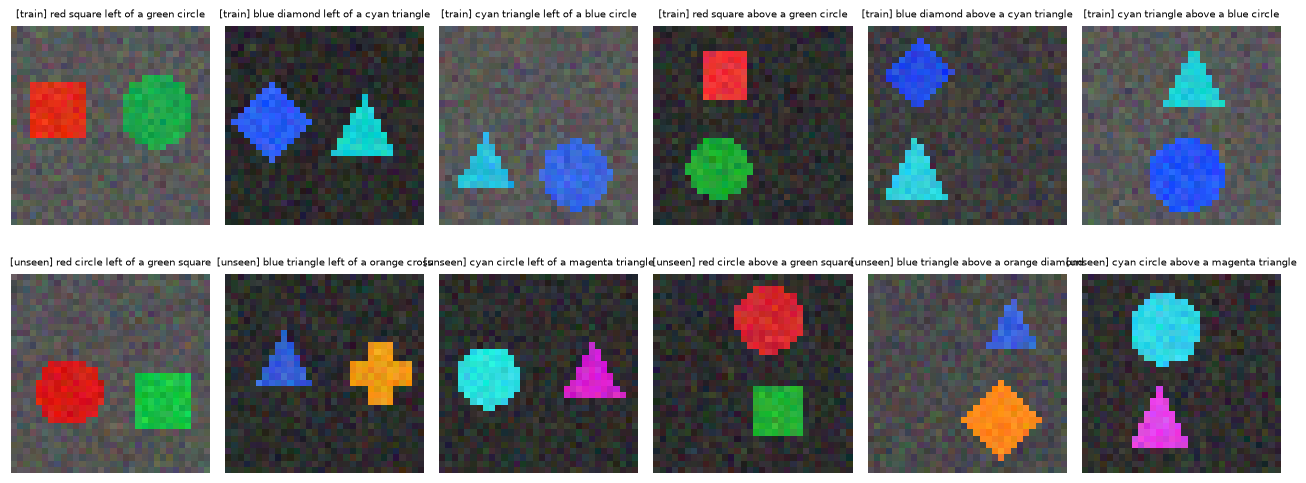

In [4]:
_t0_data = time.time()
VOCABULARY = CaptionVocabulary(TEXT_CONFIG["context_length"])
UNIVERSE = build_caption_universe(VOCABULARY)
NUM_CAPTIONS = UNIVERSE.num_captions
TRAIN_CAPTION_IDS = UNIVERSE.train_caption_ids
UNSEEN_CAPTION_IDS = UNIVERSE.unseen_caption_ids

# --- 語彙と符号化のラウンドトリップ ---
assert len(VOCABULARY) == 3 + 4 + len(COLOR_NAMES) + len(SHAPES) == 20
_token_rows = UNIVERSE.token_ids.tolist()
for _caption, _ids in zip(UNIVERSE.captions, _token_rows, strict=True):
    assert VOCABULARY.encode(_caption) == _ids and VOCABULARY.decode(_ids) == _caption
    assert _ids.count(VOCABULARY.end_id) == 1 and _ids[0] == VOCABULARY.start_id
    _end = _ids.index(VOCABULARY.end_id)
    assert all(t == VOCABULARY.pad_id for t in _ids[_end + 1 :]) and VOCABULARY.pad_id not in _ids[:_end]
assert len(set(UNIVERSE.captions)) == NUM_CAPTIONS  # キャプションの文字列が互いに異なる

# --- 意味と正準形 ---
assert NUM_CAPTIONS == len(RELATIONS) * 40 * (7 * 4) == 2240
for _m, _c in zip(UNIVERSE.meanings, UNIVERSE.captions, strict=True):
    assert caption_meaning(_c) == _m and is_valid_meaning(_m)
_example = UNIVERSE.meanings[0]
_c1, _c2 = (f"{COLOR_NAMES[o[0]]} {SHAPES[o[1]]}" for o in (_example.first, _example.second))
assert caption_meaning(f"a {_c2} right of a {_c1}") == _example  # 同義の言い換えは同じ意味に戻る
_vertical = next(m for m in UNIVERSE.meanings if m.relation == RELATIONS.index("above"))
_v1, _v2 = (f"{COLOR_NAMES[o[0]]} {SHAPES[o[1]]}" for o in (_vertical.first, _vertical.second))
assert caption_meaning(f"a {_v2} below a {_v1}") == _vertical

# --- 未見の組み合わせの分割 ---
HOLDOUT = UNIVERSE.holdout
_all_objects = set(itertools.product(range(len(COLOR_NAMES)), range(len(SHAPES))))
assert len(HOLDOUT) == 8 and HOLDOUT < _all_objects and len(HOLDOUT) / len(_all_objects) == 0.2
_train_objects = _all_objects - HOLDOUT
assert {c for c, _ in _train_objects} == set(range(len(COLOR_NAMES)))  # 各色は学習データに現れる
assert {s for _, s in _train_objects} == set(range(len(SHAPES)))  # 各形は学習データに現れる
assert np.intersect1d(TRAIN_CAPTION_IDS, UNSEEN_CAPTION_IDS).size == 0
assert len(TRAIN_CAPTION_IDS) + len(UNSEEN_CAPTION_IDS) == NUM_CAPTIONS
for _i in TRAIN_CAPTION_IDS:
    _m = UNIVERSE.meanings[_i]
    assert _m.first not in HOLDOUT and _m.second not in HOLDOUT
for _i in UNSEEN_CAPTION_IDS:
    _m = UNIVERSE.meanings[_i]
    assert _m.first in HOLDOUT or _m.second in HOLDOUT

# --- 困難な負例: 意味が異なる・単語の多重集合が同じ・有効 ---
for _rule, _neg_ids in UNIVERSE.hard_negative_ids.items():
    for _i, _j in enumerate(_neg_ids):
        _orig, _neg = UNIVERSE.captions[_i], UNIVERSE.captions[_j]
        assert caption_meaning(_neg) != caption_meaning(_orig), (_rule, _orig, _neg)  # 同義の言い換えではない
        assert sorted(_neg.split()) == sorted(_orig.split()), (_rule, _orig, _neg)  # 単語の袋としては同じ
        assert is_valid_meaning(UNIVERSE.meanings[_j])
assert (UNIVERSE.hard_negative_ids["attribute_swap"] != UNIVERSE.hard_negative_ids["order_swap"]).all()
# 順序の入れ替えは未見 / 既知の分割を保つ(同じ 2 つの図形を使う)
assert np.isin(UNIVERSE.hard_negative_ids["order_swap"][UNSEEN_CAPTION_IDS], UNSEEN_CAPTION_IDS).all()
_attr_neg_unseen = np.isin(UNIVERSE.hard_negative_ids["attribute_swap"][UNSEEN_CAPTION_IDS], UNSEEN_CAPTION_IDS)

# --- 描画とキャッシュ ---
SCENE_CACHE_DIR = ROOT / ".cache" / "020_synthetic_scenes"
_SCENE_SOURCE_HASH = hashlib.sha256((ROOT / "src" / "data" / "synthetic_scenes.py").read_bytes()).hexdigest()


def scene_cache_path(name: str, caption_ids: np.ndarray, seed: int) -> Path:
    digest = hashlib.sha256(_SCENE_SOURCE_HASH.encode() + np.asarray(caption_ids).tobytes() + str(seed).encode())
    return SCENE_CACHE_DIR / f"{name}_{digest.hexdigest()[:16]}.npz"


def load_scene_file(path: Path) -> SceneSet:
    with np.load(path) as data:
        return SceneSet(torch.from_numpy(data["images"]), data["caption_ids"], data["visible_pixels"])


def load_or_render(name: str, caption_ids: np.ndarray, seed: int) -> tuple[SceneSet, str]:
    path = scene_cache_path(name, caption_ids, seed)
    if path.exists():
        return load_scene_file(path), "キャッシュから読み込み"
    scenes = render_scenes(UNIVERSE, caption_ids, seed)
    SCENE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(path, images=scenes.images.numpy(), caption_ids=scenes.caption_ids, visible_pixels=scenes.visible_pixels)
    return scenes, "描画してキャッシュに保存"


SCENE_SPECS = {
    "train": (repeat_caption_ids(TRAIN_CAPTION_IDS, TRAIN_COPIES), TRAIN_RENDER_SEED),
    "validation": (repeat_caption_ids(TRAIN_CAPTION_IDS, VALIDATION_COPIES), VALIDATION_RENDER_SEED),
    "unseen": (repeat_caption_ids(UNSEEN_CAPTION_IDS, UNSEEN_COPIES), UNSEEN_RENDER_SEED),
}
SCENES: dict[str, SceneSet] = {}
SCENE_SHA256: dict[str, str] = {}
for _name, (_ids, _seed) in SCENE_SPECS.items():
    SCENES[_name], _source = load_or_render(_name, _ids, _seed)
    _reloaded = load_scene_file(scene_cache_path(_name, _ids, _seed))  # ディスクから読み直す
    _fresh = render_scenes(UNIVERSE, _ids, _seed, chunk_size=1000)  # キャッシュを使わず、一度に描く数を変えて描き直す
    assert torch.equal(SCENES[_name].images, _reloaded.images) and torch.equal(SCENES[_name].images, _fresh.images)
    assert np.array_equal(SCENES[_name].caption_ids, _ids) and np.array_equal(_fresh.caption_ids, _ids)
    assert np.array_equal(SCENES[_name].visible_pixels, _fresh.visible_pixels)
    SCENE_SHA256[_name] = sha256_of_tensor(SCENES[_name].images)
    print(
        f"{_name}: {len(_ids):,} 枚({_source})。キャッシュ・ディスクから読み直し・描き直しが bit 単位で一致: OK、"
        f"SHA-256 {SCENE_SHA256[_name][:16]}...、見えている画素数の最小値 {SCENES[_name].visible_pixels.min()}"
    )
    assert SCENES[_name].visible_pixels.min() >= 20  # 2 つの図形がどちらも見えている
    for _i in np.unique(_ids):  # 除外した組がどちらの図形にも出ない(学習・検証)/ 1 つ以上出る(評価)
        _m = UNIVERSE.meanings[_i]
        assert (_m.first in HOLDOUT or _m.second in HOLDOUT) == (_name == "unseen")
    del _reloaded, _fresh
assert np.array_equal(np.bincount(SCENES["unseen"].caption_ids, minlength=NUM_CAPTIONS)[UNSEEN_CAPTION_IDS], np.full(len(UNSEEN_CAPTION_IDS), UNSEEN_COPIES))

# --- 学習中の困難な負例の除外(NegCLIP): 除外した組を含むキャプションは困難な負例に使わない ---
TRAIN_CAPTION_MASK = np.zeros(NUM_CAPTIONS, dtype=bool)
TRAIN_CAPTION_MASK[TRAIN_CAPTION_IDS] = True
_train_attr_ok = TRAIN_CAPTION_MASK[UNIVERSE.hard_negative_ids["attribute_swap"][TRAIN_CAPTION_IDS]]
assert TRAIN_CAPTION_MASK[UNIVERSE.hard_negative_ids["order_swap"][TRAIN_CAPTION_IDS]].all()  # 順序の入れ替えは常に学習用
ATTRIBUTE_SWAP_TRAIN_FRACTION = float(_train_attr_ok.mean())

# --- ランダムな負例(実験 B) ---
_rng = np.random.default_rng(RANDOM_NEGATIVE_SEED)
_unseen_positive = SCENES["unseen"].caption_ids
_candidate_positions = {c: i for i, c in enumerate(UNSEEN_CAPTION_IDS)}
_positive_positions = np.array([_candidate_positions[c] for c in _unseen_positive])


def _uniform_unseen_except_positive(rng, size: int) -> np.ndarray:
    draw = rng.integers(0, len(UNSEEN_CAPTION_IDS) - 1, size=(len(_unseen_positive), size))
    return UNSEEN_CAPTION_IDS[draw + (draw >= _positive_positions[:, None])]  # 正例の位置を飛ばす


# 旧定義(診断量): 2 個とも、正例以外の未見の組み合わせのキャプションから一様に選ぶ(以前と同じ乱数の列)
RANDOM_NEGATIVE_IDS_OLD = _uniform_unseen_except_positive(_rng, RANDOM_NEGATIVES_PER_IMAGE)
# 新定義: 1 個目は順序の入れ替えに対応させて未見の組み合わせから(正例を除く)、2 個目は色の入れ替えに対応させ、
# その画像の色の入れ替えのキャプションと同じ集合(学習用 / 未見の組み合わせ)から、正例とその困難な負例を除いて選ぶ
_new_first = _uniform_unseen_except_positive(_rng, 1)[:, 0]
_attr_swap_of_positive = UNIVERSE.hard_negative_ids["attribute_swap"][_unseen_positive]
_order_swap_of_positive = UNIVERSE.hard_negative_ids["order_swap"][_unseen_positive]
_new_second = np.empty(len(_unseen_positive), dtype=np.int64)
for _i, (_p, _a, _o) in enumerate(zip(_unseen_positive, _attr_swap_of_positive, _order_swap_of_positive, strict=True)):
    _pool = TRAIN_CAPTION_IDS if TRAIN_CAPTION_MASK[_a] else UNSEEN_CAPTION_IDS
    while True:  # 除く 3 個以外から一様に選ぶ(棄却法)
        _c = _pool[_rng.integers(0, len(_pool))]
        if _c not in (_p, _a, _o):
            break
    _new_second[_i] = _c
RANDOM_NEGATIVE_IDS = np.stack([_new_first, _new_second], axis=1)  # (枚数, 2)
# 既知性の偏りの診断量: 未見の正例 vs 学習用のキャプション(一様)の 2 択と、未見の正例 vs 未見の組み合わせのキャプション
# (新定義の 1 個目)の 2 択
RANDOM_TRAIN_IDS = TRAIN_CAPTION_IDS[_rng.integers(0, len(TRAIN_CAPTION_IDS), size=len(_unseen_positive))]
assert (RANDOM_NEGATIVE_IDS != _unseen_positive[:, None]).all() and (RANDOM_NEGATIVE_IDS_OLD != _unseen_positive[:, None]).all()
assert np.isin(RANDOM_NEGATIVE_IDS_OLD, UNSEEN_CAPTION_IDS).all() and np.isin(_new_first, UNSEEN_CAPTION_IDS).all()
assert (TRAIN_CAPTION_MASK[_new_second] == TRAIN_CAPTION_MASK[_attr_swap_of_positive]).all()  # 既知 / 未見の状態が対応する
assert ((_new_second != _attr_swap_of_positive) & (_new_second != _order_swap_of_positive)).all()
assert TRAIN_CAPTION_MASK[RANDOM_TRAIN_IDS].all()

# --- GPU に載せる(全条件・全シードで再利用) ---
TOKENS = UNIVERSE.token_ids.to(device)
TRAIN_IMAGES = SCENES["train"].images.to(device)
VALIDATION_IMAGES = SCENES["validation"].images.to(device)
UNSEEN_IMAGES = SCENES["unseen"].images.to(device)
TRAIN_SCENE_CAPTION_IDS = SCENES["train"].caption_ids
TRAIN_CANDIDATES = torch.as_tensor(TRAIN_CAPTION_IDS, device=device)
UNSEEN_CANDIDATES = torch.as_tensor(UNSEEN_CAPTION_IDS, device=device)
_train_pos = {c: i for i, c in enumerate(TRAIN_CAPTION_IDS)}
VALIDATION_TRUE_INDEX = torch.as_tensor([_train_pos[c] for c in SCENES["validation"].caption_ids], device=device)
UNSEEN_TRUE_INDEX = torch.as_tensor(_positive_positions, device=device)
UNSEEN_POSITIVE_IDS = torch.as_tensor(_unseen_positive, device=device)
VALIDATION_POSITIVE_IDS = torch.as_tensor(SCENES["validation"].caption_ids, device=device)
HARD_NEGATIVE_IDS_DEVICE = {k: torch.as_tensor(v, device=device) for k, v in UNIVERSE.hard_negative_ids.items()}
RANDOM_NEGATIVE_SETS_DEVICE = {  # 名前 -> (枚数, k) の負例のキャプションの番号
    "random": torch.as_tensor(RANDOM_NEGATIVE_IDS, device=device),  # 判定に使う(新定義)
    "random_old": torch.as_tensor(RANDOM_NEGATIVE_IDS_OLD, device=device),  # 旧定義(診断量)
    "random_train": torch.as_tensor(RANDOM_TRAIN_IDS[:, None], device=device),  # 既知性の偏り(診断量)
    "random_unseen": torch.as_tensor(_new_first[:, None], device=device),  # 既知性の偏り(診断量)
}
assert torch.equal(TRAIN_IMAGES.cpu(), SCENES["train"].images) and torch.equal(UNSEEN_IMAGES.cpu(), SCENES["unseen"].images)
UNSEEN_IMAGES_SHA256 = sha256_of_tensor(UNSEEN_IMAGES)
DATA_SECONDS = time.time() - _t0_data

print(
    f"語彙 {len(VOCABULARY)} 語 {VOCABULARY.tokens}、系列長 {VOCABULARY.context_length}。"
    f"全 {NUM_CAPTIONS:,} キャプションで符号化・復号のラウンドトリップが一致: OK"
)
print(
    f"除外した (色, 形) の組 H(40 組のうち {len(HOLDOUT)} 組): "
    + "、".join(f"{COLOR_NAMES[c]} {SHAPES[s]}" for c, s in sorted(HOLDOUT))
)
print(
    f"キャプション: 全 {NUM_CAPTIONS:,} = 学習用 {len(TRAIN_CAPTION_IDS):,} + 未見の組み合わせ {len(UNSEEN_CAPTION_IDS):,}。"
    "除外した組は学習・検証のどちらの図形にも出ない、各色・各形は学習データに現れる: OK"
)
print(
    "困難な負例(色の入れ替え・順序の入れ替え): 全キャプションで意味が異なり(同義の言い換えなし)、単語の多重集合が同じ、有効: OK。"
    f"未見の組み合わせのキャプションの色の入れ替えが未見の組み合わせのキャプションになる割合 {_attr_neg_unseen.mean():.3f}"
    "(順序の入れ替えは常に未見の組み合わせのまま)"
)
print(
    f"学習用のキャプションの色の入れ替えのうち、除外した組を含むもの: {int((~_train_attr_ok).sum())} / {len(TRAIN_CAPTION_IDS):,} 個"
    f"({1 - ATTRIBUTE_SWAP_TRAIN_FRACTION:.3f})。NegCLIP の学習ではこれらを困難な負例に使わないので、色の入れ替えの困難な負例を持つ正例は"
    f" {ATTRIBUTE_SWAP_TRAIN_FRACTION:.3f}。順序の入れ替えは常に学習用のキャプション: OK"
)
_second_is_train = TRAIN_CAPTION_MASK[_new_second].mean()
print(
    f"ランダムな負例(新定義): 各画像に 2 個。1 個目は未見の組み合わせから、2 個目は色の入れ替えと同じ集合から(学習用 {_second_is_train:.3f}・"
    f"未見 {1 - _second_is_train:.3f})。既知 / 未見の状態が色の入れ替えと対応し、正例と困難な負例を含まない: OK。"
    "旧定義(すべて未見の組み合わせから)と既知性の偏りの診断用の負例も用意した"
)
print("バッチ内に、ある正例の困難な負例のキャプションが別の正例として偶然現れる確率(3.7 節):")
for _n in BATCH_SIZES:
    _p_order = (_n - 1) / (len(TRAIN_CAPTION_IDS) - 1)
    print(
        f"  N = {_n}: 順序の入れ替え {_p_order:.4f}、色の入れ替え {_p_order * ATTRIBUTE_SWAP_TRAIN_FRACTION:.4f}"
        f"(学習用として存在する割合 {ATTRIBUTE_SWAP_TRAIN_FRACTION:.3f} を掛けた平均)"
    )
# 3.7 節の比較: 6 色 x 4 種類(除外 5 組)にした場合の学習用のキャプションの数と同じ確率(N = 256)
_objects_64 = [o for o in itertools.product(range(6), range(4)) if o not in {(i, i % 4) for i in range(5)}]
_captions_64 = 2 * sum(1 for a in _objects_64 for b in _objects_64 if a[0] != b[0] and a[1] != b[1])
print(f"  (参考)6 色 x 4 種類なら学習用のキャプション {_captions_64} 個、N = 256 で {(256 - 1) / (_captions_64 - 1):.4f}")
print(f"データの準備: {DATA_SECONDS:.1f}s")

_fig, _axes = plt.subplots(2, 6, figsize=(13, 5.4))
for _k, _ax in enumerate(_axes.flat):
    _set = "train" if _k < 6 else "unseen"
    _j = (_k % 6) * (len(SCENES[_set].caption_ids) // 6) + 3
    _ax.imshow(SCENES[_set].images[_j].permute(1, 2, 0).numpy())
    _ax.set_title(("[train] " if _set == "train" else "[unseen] ") + UNIVERSE.captions[SCENES[_set].caption_ids[_j]][2:], fontsize=7)
    _ax.axis("off")
plt.tight_layout()
plt.show()

### 5.4 モデルの構築と不変条件の確認

- **パラメータ数**: 画像 encoder・テキスト encoder・射影・温度とバイアスのパラメータ数を印字する。
- **初期化の一致**: 同じシードで構築した softmax・sigmoid・NegCLIP のモデルの重みが、温度とバイアス(初期値が損失ごとに違う
  スカラー)を除いて bit 単位で一致すること。実験 A・C の対応のある差の前提である。
- **テキスト encoder**: 終端トークンより後ろのパディングを別のトークンに置き換えても、終端トークンの位置の特徴が bit 単位で変わらない
  こと(因果マスクの確認)と、終端トークンより前のトークンを変えると特徴が変わること(確認の検出力)。
- **損失**: 3 つの損失が、ループで書いた参照実装と FP64 で一致すること。NegCLIP の損失は、困難な負例が 0 個なら softmax の損失と
  一致し、正例と同じキャプションになった困難な負例をその行の分母から除くこと。バッチ内のマージンと検索の正解率も参照実装と比べる。
- **困難な負例の除外**: NegCLIP の学習ループを 3 ステップ回し、テキスト encoder に入れた全系列が学習用のキャプション(除外した組を
  含まない)であること、色の入れ替えの一部だけが分母から除かれ、順序の入れ替えは除かれないことを確かめる。除外をしない設定では
  除外した組を含むキャプションが入ることも確かめる(確認の検出力)。
- **バッチの切り出し**: `DistinctCaptionBatchSampler`の各バッチでキャプションが互いに異なり、各キャプションのシーンが巡回的に
  (使われた回数の差が 1 以内で)使われること。
- **既存モジュールの後方互換性**: `src/models/vit.py`・`src/training/optimizer.py`を変更する前のコミット(`50820bf`、019 の最終
  コミット)を`git worktree`で取得し、その worktree の`src`と現行の`src`で同じスクリプトをサブプロセスとして実行する
  (`sys.executable`で起動するので同一の環境)。スクリプトは CPU で、3 通りの ViT(パッチサイズ・位置埋め込みの方式)の logits・注意の
  重み・勾配・`state_dict`と、既定の`AdamW`で 3 ステップ更新した後の重みの SHA-256 を出力する。**期待値をハードコードせず、2 つの
  サブプロセスの出力どうしを比べる。** 参照側が worktree 配下の`src`を読み込み、変更前の実装(`forward_features`・`foreach`を持たない)
  であることも確かめる。
- **`AdamW(foreach=True)`**: 既定の経路と CPU で bit 単位で一致すること。実行したデバイスでの差の最大値も印字する(演算の起動の
  まとめ方が違うので、GPU では丸めの差がありうる。本トピックの全学習は同じ`foreach=True`の経路を使うので、条件間の比較には影響しない)。

In [5]:
_t0_checks = time.time()


def build_clip(loss_type: str) -> CLIPDualEncoder:
    # 乱数の状態は呼び出し側が torch.manual_seed で決める
    vision = VisionTransformer(**VISION_CONFIG)
    text = CausalTextTransformer(len(VOCABULARY), end_token_id=VOCABULARY.end_id, **TEXT_CONFIG)
    return CLIPDualEncoder(vision, text, EMBEDDING_DIM, INIT_LOGIT_SCALE[loss_type], INIT_LOGIT_BIAS)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# --- パラメータ数と、損失の間での初期化の一致 ---
_init_hashes = {}
for _loss in ("softmax", "sigmoid", "negclip"):
    torch.manual_seed(INIT_SEED_BASE)
    _m = build_clip(_loss)
    _init_hashes[_loss] = sha256_of_state(_m.state_dict(), exclude=("logit_scale", "logit_bias"))
PARAMETER_COUNTS = count_parameters_by_part(_m)
assert len(set(_init_hashes.values())) == 1, _init_hashes
print(
    "パラメータ数: "
    + "、".join(f"{k} {v:,}" for k, v in PARAMETER_COUNTS.items())
    + f"、合計 {count_parameters(_m):,}"
)
print("同じシードの softmax・sigmoid・NegCLIP のモデルの初期値が、温度とバイアスを除いて bit 単位で一致: OK")

# --- テキスト encoder: 因果マスクと終端トークンの位置 ---
torch.manual_seed(0)
_text = CausalTextTransformer(len(VOCABULARY), end_token_id=VOCABULARY.end_id, **TEXT_CONFIG).eval()
_tokens = UNIVERSE.token_ids[:: max(1, NUM_CAPTIONS // 64)][:64].clone()
_tokens = _tokens[(_tokens == VOCABULARY.pad_id).any(dim=1)]  # パディングを持つ(above の)キャプション
assert len(_tokens) > 0
_scrambled = _tokens.clone()
_pads = _scrambled == VOCABULARY.pad_id
_scrambled[_pads] = torch.randint(3, len(VOCABULARY), (int(_pads.sum()),), generator=torch.Generator().manual_seed(1))
_changed = _tokens.clone()
_changed[:, 2] = (_changed[:, 2] - 7 + 1) % len(COLOR_NAMES) + 7  # 1 つ目の図形の色を変える(終端より前)
assert VOCABULARY.tokens[7] == COLOR_NAMES[0]
with torch.no_grad():
    _f, _f_scrambled, _f_changed = _text(_tokens), _text(_scrambled), _text(_changed)
    _hidden = _text.token_embedding(_tokens) + _text.position_embedding
    _mask = _text.causal_mask
    for _block in _text.blocks:
        _hidden, _, _ = _block(_hidden, None, tgt_mask=_mask)
    _hidden = _text.final_norm(_hidden)
    _end = (_tokens == VOCABULARY.end_id).int().argmax(dim=1)
assert torch.equal(_f, _f_scrambled)  # 終端より後ろは特徴に影響しない
assert (_f - _f_changed).abs().max() > 1e-3  # 終端より前のトークンは影響する(確認の検出力)
assert torch.equal(_f, _hidden[torch.arange(len(_tokens)), _end])
print(
    f"テキスト encoder: 終端より後ろのパディングを置き換えても特徴が bit 単位で不変({len(_tokens)} 文)、終端より前を変えると変わる、"
    "終端トークンの位置の表現を取り出している: OK"
)

# --- 損失と評価の関数を参照実装と比べる(FP64、CPU) ---
_gen = torch.Generator().manual_seed(2)
_n, _e = 6, 5
_u = functional.normalize(torch.randn(_n, _e, generator=_gen, dtype=torch.float64), dim=-1)
_v = functional.normalize(torch.randn(_n, _e, generator=_gen, dtype=torch.float64), dim=-1)
_hard = functional.normalize(torch.randn(4, _e, generator=_gen, dtype=torch.float64), dim=-1)
_t, _b = torch.tensor(2.3, dtype=torch.float64), torch.tensor(-4.0, dtype=torch.float64)
_s = (_u @ _v.t()).tolist()
_scale = math.exp(2.3)
_ref_i2t = -sum(_scale * _s[i][i] - math.log(sum(math.exp(_scale * _s[i][j]) for j in range(_n))) for i in range(_n)) / _n
_ref_t2i = -sum(_scale * _s[i][i] - math.log(sum(math.exp(_scale * _s[j][i]) for j in range(_n))) for i in range(_n)) / _n
assert math.isclose(float(softmax_contrastive_loss(_u, _v, _t)), (_ref_i2t + _ref_t2i) / 2, rel_tol=1e-12)
_ref_sig = -sum(
    math.log(1 / (1 + math.exp(-(1 if i == j else -1) * (_scale * _s[i][j] - 4.0)))) for i in range(_n) for j in range(_n)
) / _n
assert math.isclose(float(sigmoid_contrastive_loss(_u, _v, _t, _b)), _ref_sig, rel_tol=1e-12)
_pos_ids = torch.tensor([10, 11, 12, 13, 14, 15])
assert torch.equal(
    negclip_loss(_u, _v, _hard[:0], _t, _pos_ids, torch.tensor([], dtype=torch.int64)), softmax_contrastive_loss(_u, _v, _t)
)
_hard_ids = torch.tensor([11, 20, 21, 22])  # 1 つ目の困難な負例は、行 1 の正例と同じキャプション
_sh = (_u @ _hard.t()).tolist()
_ref_neg_i2t = 0.0
for i in range(_n):
    _terms = [math.exp(_scale * _s[i][j]) for j in range(_n)]
    _terms += [math.exp(_scale * _sh[i][k]) for k in range(4) if int(_hard_ids[k]) != int(_pos_ids[i])]
    _ref_neg_i2t += -(_scale * _s[i][i] - math.log(sum(_terms))) / _n
assert math.isclose(float(negclip_loss(_u, _v, _hard, _t, _pos_ids, _hard_ids)), (_ref_neg_i2t + _ref_t2i) / 2, rel_tol=1e-12)
_ref_margin = sum(_s[i][i] - max(_s[i][j] for j in range(_n) if j != i) for i in range(_n)) / _n
assert math.isclose(float(in_batch_margin(_u, _v)), _ref_margin, rel_tol=1e-12)
_true = torch.tensor([0, 1, 3, 3, 4, 2])
_r = evaluate_retrieval(_u, _v, _true)
assert _r["num_candidates"] == _n and np.array_equal(_r["correct"], (torch.tensor(_s).argmax(dim=1) == _true).numpy())
print("損失(softmax・sigmoid・NegCLIP)・バッチ内のマージン・検索の正解率が参照実装と一致(FP64)、NegCLIP の偽の負例の除外: OK")

# --- バッチの切り出し ---
_sampler = DistinctCaptionBatchSampler(TRAIN_SCENE_CAPTION_IDS, TRAIN_COPIES, STANDARD_BATCH_SIZE, torch.Generator().manual_seed(3))
_uses = np.zeros(len(TRAIN_SCENE_CAPTION_IDS), dtype=np.int64)
for _ in range(400):
    _batch = _sampler.next_batch().numpy()
    assert len(np.unique(TRAIN_SCENE_CAPTION_IDS[_batch])) == STANDARD_BATCH_SIZE
    np.add.at(_uses, _batch, 1)
_per_caption = _uses.reshape(len(TRAIN_CAPTION_IDS), TRAIN_COPIES)
assert (_per_caption.max(axis=1) - _per_caption.min(axis=1) <= 1).all()
print(
    f"バッチの切り出し: 400 バッチ(N = {STANDARD_BATCH_SIZE})でキャプションが互いに異なり、各キャプションのシーンの使用回数の差が 1 以内: OK"
)

# --- NegCLIP の困難な負例から、除外した組を含むキャプションを除く(学習ループの確認) ---
_filter_check = {}
for _label, _allowed in (("除外あり", TRAIN_CAPTION_MASK), ("除外なし(確認の検出力)", None)):
    torch.manual_seed(INIT_SEED_BASE)
    _h = train_contrastive_model(
        build_clip("negclip").to(device), TRAIN_IMAGES, TOKENS, TRAIN_SCENE_CAPTION_IDS, TRAIN_COPIES, "negclip",
        num_steps=3, batch_size=64, peak_learning_rate=1e-4, warmup_steps=1, min_learning_rate=1e-6, weight_decay=WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, data_seed=5, hard_negative_ids=UNIVERSE.hard_negative_ids,
        hard_negative_allowed=_allowed, logit_scale_max=LOGIT_SCALE_MAX["negclip"],
    )
    _filter_check[_label] = _h
_h = _filter_check["除外あり"]
assert TRAIN_CAPTION_MASK[_h["text_caption_ids"]].all()  # テキスト encoder に入れた系列はすべて学習用のキャプション
assert _h["hard_negatives_used"]["order_swap"] == _h["hard_negatives_generated"]["order_swap"]
assert _h["hard_negatives_used"]["attribute_swap"] < _h["hard_negatives_generated"]["attribute_swap"]
assert not TRAIN_CAPTION_MASK[_filter_check["除外なし(確認の検出力)"]["text_caption_ids"]].all()
print(
    "NegCLIP の困難な負例の除外(3 ステップ、N = 64): 除外ありではテキスト encoder に入れた全系列が学習用のキャプション、"
    f"分母に加えた数 {_h['hard_negatives_used']}(規則が作った数 {_h['hard_negatives_generated']})。除外なしでは除外した組を含む"
    "キャプションが入る(確認の検出力): OK"
)
del _filter_check, _h

# --- 既存モジュールの後方互換性(変更前のコミットとの bit 単位の一致) ---
_REFERENCE_COMMIT = "50820bf"  # src/models/vit.py・src/training/optimizer.py を 020 で変更する前の最後のコミット
_WORKTREE_DIR = ROOT / ".cache" / "_020_backward_compat_worktree"
_compat_script = '''
import hashlib
import inspect
import json
import sys

import torch

from src.models.vit import VisionTransformer
from src.training.optimizer import AdamW

print("SRC_FILE:" + __import__("src").__file__, file=sys.stderr)
print("HAS_FORWARD_FEATURES:" + str(hasattr(VisionTransformer, "forward_features")), file=sys.stderr)
print("HAS_FOREACH:" + str("foreach" in inspect.signature(AdamW.__init__).parameters), file=sys.stderr)


def h(t):
    return hashlib.sha256(t.detach().contiguous().numpy().tobytes()).hexdigest()


out = {}
generator = torch.Generator().manual_seed(0)
images = torch.randn(4, 3, 32, 32, generator=generator)
labels = torch.randint(0, 10, (4,), generator=generator)
for patch, pe in ((4, "learned"), (8, "sinusoidal_2d"), (4, "none")):
    torch.manual_seed(5)
    model = VisionTransformer(32, patch, 3, 10, 64, 2, 4, 128, pe)
    torch.nn.init.normal_(model.head.weight, std=0.5)
    key = f"P{patch}_{pe}"
    out[key + "_state"] = {n: h(t) for n, t in model.state_dict().items()}
    logits, weights = model(images, return_attention_weights=True)
    out[key + "_logits"] = h(logits)
    out[key + "_logits_plain"] = h(model(images))
    out[key + "_attention"] = [h(w) for w in weights]
    torch.nn.functional.cross_entropy(logits, labels).backward()
    out[key + "_gradients"] = {n: h(p.grad) for n, p in model.named_parameters() if p.grad is not None}
    optimizer = AdamW(list(model.parameters()), lr=1e-2, weight_decay=0.1)
    for _ in range(3):
        optimizer.step()
    out[key + "_after_adamw"] = {n: h(p) for n, p in model.named_parameters()}
print(json.dumps(out))
'''
subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
_r = subprocess.run(["git", "worktree", "add", "--detach", str(_WORKTREE_DIR), _REFERENCE_COMMIT], capture_output=True, text=True)
assert _r.returncode == 0, _r.stderr
(_WORKTREE_DIR / "_compat_script.py").write_text(_compat_script)
(ROOT / "_compat_script.py").write_text(_compat_script)
try:
    _ref = subprocess.run([sys.executable, "_compat_script.py"], cwd=_WORKTREE_DIR, capture_output=True, text=True)
    assert _ref.returncode == 0, _ref.stderr
    assert "SRC_FILE:" + str((_WORKTREE_DIR / "src" / "__init__.py").resolve()) in _ref.stderr, _ref.stderr
    assert "HAS_FORWARD_FEATURES:False" in _ref.stderr and "HAS_FOREACH:False" in _ref.stderr, "参照側が変更後の実装を読み込んでいる"
    _new = subprocess.run([sys.executable, "_compat_script.py"], cwd=ROOT, capture_output=True, text=True)
    assert _new.returncode == 0, _new.stderr
    assert "SRC_FILE:" + str((ROOT / "src" / "__init__.py").resolve()) in _new.stderr, _new.stderr
    assert "HAS_FORWARD_FEATURES:True" in _new.stderr and "HAS_FOREACH:True" in _new.stderr, "現行側が変更後の実装を読み込んでいない"
    _ref_out, _new_out = json.loads(_ref.stdout), json.loads(_new.stdout)
    assert set(_ref_out) == set(_new_out)
    _mismatch = [k for k in _ref_out if _ref_out[k] != _new_out[k]]
    print(f"  比べた項目 {len(_ref_out)} 個(logits・注意の重み・勾配・state_dict・AdamW の 3 ステップ後の重み)、不一致 {len(_mismatch)} 個")
    assert not _mismatch, _mismatch
    print(
        f"参照コミット {_REFERENCE_COMMIT}(worktree 配下の src を読み込んだことを確認)と現行の src で、VisionTransformer の出力・"
        "注意の重み・勾配・state_dict と、既定の AdamW の更新が bit 単位で一致: OK"
    )
finally:
    (ROOT / "_compat_script.py").unlink(missing_ok=True)
    subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)

# --- AdamW(foreach=True)と既定の経路の一致 ---
ADAMW_FOREACH_MAX_DIFF = {}
for _dev in sorted({torch.device("cpu"), device}, key=str):
    _models = []
    for _ in range(2):
        torch.manual_seed(INIT_SEED_BASE)
        _models.append(build_clip("softmax").to(_dev))
    _opts = [
        AdamW(list(_models[0].parameters()), lr=1e-3, weight_decay=WEIGHT_DECAY),
        AdamW(list(_models[1].parameters()), lr=1e-3, weight_decay=WEIGHT_DECAY, foreach=True),
    ]
    _g = torch.Generator().manual_seed(4)
    for _step in range(5):
        _grads = [torch.randn(p.shape, generator=_g) for p in _models[0].parameters()]
        for _model in _models:
            for _p, _gr in zip(_model.parameters(), _grads, strict=True):
                _p.grad = _gr.to(_dev)
        for _o in _opts:
            _o.step()
    ADAMW_FOREACH_MAX_DIFF[_dev.type] = max(
        float((a - b).detach().abs().max()) for a, b in zip(_models[0].parameters(), _models[1].parameters(), strict=True)
    )
    if _dev.type == "cpu":
        assert all(torch.equal(a, b) for a, b in zip(_models[0].parameters(), _models[1].parameters(), strict=True))
    assert ADAMW_FOREACH_MAX_DIFF[_dev.type] < 1e-6, ADAMW_FOREACH_MAX_DIFF
print(
    "AdamW(foreach=True)と既定の経路(CLIP の全パラメータ、5 ステップ): CPU で bit 単位で一致: OK。差の最大値 "
    + "、".join(f"{k}: {v:.1e}" for k, v in ADAMW_FOREACH_MAX_DIFF.items())
)
del _m, _text, _models, _opts
CHECK_SECONDS = time.time() - _t0_checks
print(f"確認の実行時間: {CHECK_SECONDS:.1f}s")

パラメータ数: vision 806,016、text 795,136、projection 16,384、scale_and_bias 2、合計 1,617,538
同じシードの softmax・sigmoid・NegCLIP のモデルの初期値が、温度とバイアスを除いて bit 単位で一致: OK
テキスト encoder: 終端より後ろのパディングを置き換えても特徴が bit 単位で不変(32 文)、終端より前を変えると変わる、終端トークンの位置の表現を取り出している: OK
損失(softmax・sigmoid・NegCLIP)・バッチ内のマージン・検索の正解率が参照実装と一致(FP64)、NegCLIP の偽の負例の除外: OK
バッチの切り出し: 400 バッチ(N = 256)でキャプションが互いに異なり、各キャプションのシーンの使用回数の差が 1 以内: OK


NegCLIP の困難な負例の除外(3 ステップ、N = 64): 除外ありではテキスト encoder に入れた全系列が学習用のキャプション、分母に加えた数 {'attribute_swap': 94, 'order_swap': 192}(規則が作った数 {'attribute_swap': 192, 'order_swap': 192})。除外なしでは除外した組を含むキャプションが入る(確認の検出力): OK


  比べた項目 18 個(logits・注意の重み・勾配・state_dict・AdamW の 3 ステップ後の重み)、不一致 0 個
参照コミット 50820bf(worktree 配下の src を読み込んだことを確認)と現行の src で、VisionTransformer の出力・注意の重み・勾配・state_dict と、既定の AdamW の更新が bit 単位で一致: OK


AdamW(foreach=True)と既定の経路(CLIP の全パラメータ、5 ステップ): CPU で bit 単位で一致: OK。差の最大値 cpu: 0.0e+00、mps: 0.0e+00
確認の実行時間: 3.5s


### 5.5 学習と評価のヘルパー

- **学習の鍵**: 1 つの学習を`(損失, N, s)`の組で表す。標準条件 S は`("softmax", 256, s)`であり、実験 A の $N = 256$ の softmax・実験 B の
  モデル・実験 C の標準のモデルはすべてこの鍵になる。同じ鍵の学習は 1 回だけ行い、記録を共有する。
- **シード $s$ が決めるもの**: 初期化(`torch.manual_seed(20100 + s)`でモデルを構築)と、バッチの順序(CPU の生成器`20200 + s`)。
  同じ $s$ の学習どうしは、損失によらず同じ初期値から始まり(温度とバイアスを除く)、同じ $N$ なら同じ順序で同じシーンを見る
  (6.11 節でアサーションにより確かめる)。
- **評価**(学習の最終ステップの重み、FP32): 既知の組み合わせの検証集合の検索(途中の 25%・50%・75% と最後)、未見の組み合わせの
  評価集合の検索の正解率 $M$ とマージン、2 択の正解率(色の入れ替え・順序の入れ替え・ランダムな負例)、既知の組み合わせの検証集合での
  2 択の正解率(実験 C の診断量)、modality gap(学習の前と後)、学習中のバッチ内のマージン(末尾 10% のステップの平均)。シード 0 では
  射影図のための埋め込みを残す。
- **較正の学習**(`purpose="calibration"`)では、未見の組み合わせの評価集合を一切評価しない(記録に評価集合の鍵を持たないことを
  6.11 節で確かめる)。
- 学習で見る事例数`EXAMPLES`は、6.4 節で実行計画を選んだ後に決まる。

In [6]:
def key_of(loss_type: str, batch_size: int, seed: int) -> tuple:
    return (loss_type, batch_size, seed)


def build_model_for(key: tuple) -> CLIPDualEncoder:
    torch.manual_seed(INIT_SEED_BASE + key[2])
    return build_clip(key[0]).to(device)


def train_run(model, key, learning_rate, num_steps, evaluation_steps=(), evaluation_fn=None) -> dict:
    return train_contrastive_model(
        model,
        TRAIN_IMAGES,
        TOKENS,
        TRAIN_SCENE_CAPTION_IDS,
        TRAIN_COPIES,
        key[0],
        num_steps=num_steps,
        batch_size=key[1],
        peak_learning_rate=learning_rate,
        warmup_steps=warmup_steps_for(num_steps),
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
        weight_decay=WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        data_seed=DATA_SEED_BASE + key[2],
        hard_negative_ids=UNIVERSE.hard_negative_ids if key[0] == "negclip" else None,
        hard_negative_allowed=TRAIN_CAPTION_MASK,  # 除外した組を含むキャプションは困難な負例に使わない
        logit_scale_max=LOGIT_SCALE_MAX[key[0]],
        use_fp16_autocast=USE_FP16_AUTOCAST,
        init_loss_scale=INIT_LOSS_SCALE,
        loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        evaluation_steps=evaluation_steps,
        evaluation_fn=evaluation_fn,
    )


def summary(result: dict) -> dict:
    return {k: v for k, v in result.items() if k != "correct"}


def evaluate_seen(model) -> dict:
    # 既知の組み合わせの検証集合の検索(候補は学習用の全キャプション)。学習率の較正と前提条件 P1 に使う
    text = encode_texts(model, TOKENS)
    return summary(evaluate_retrieval(encode_images(model, VALIDATION_IMAGES), text[TRAIN_CANDIDATES], VALIDATION_TRUE_INDEX))


def two_alternative_accuracies(image_embeddings, text_embeddings, positive_ids, random_sets=None) -> dict:
    # random_sets: 名前 -> (枚数, k) の負例のキャプションの番号。各列を 1 回の 2 択とし、列をまとめて正解率を出す
    result = {}
    for rule, ids in HARD_NEGATIVE_IDS_DEVICE.items():
        result[rule] = evaluate_two_alternative(image_embeddings, text_embeddings, positive_ids, ids[positive_ids])
    result["swap"] = np.concatenate([result["attribute_swap"], result["order_swap"]])
    for name, ids in (random_sets or {}).items():
        result[name] = np.concatenate(
            [evaluate_two_alternative(image_embeddings, text_embeddings, positive_ids, ids[:, k]) for k in range(ids.shape[1])]
        )
    return {k: float(v.mean()) for k, v in result.items()} | {f"{k}_count": int(v.size) for k, v in result.items()}


def evaluate_final(model, keep_projection: bool) -> dict:
    text = encode_texts(model, TOKENS)
    unseen_images = encode_images(model, UNSEEN_IMAGES)
    seen_images = encode_images(model, VALIDATION_IMAGES)
    unseen = evaluate_retrieval(unseen_images, text[UNSEEN_CANDIDATES], UNSEEN_TRUE_INDEX)
    result = {
        "unseen_retrieval": summary(unseen),
        "unseen_two_alternative": two_alternative_accuracies(unseen_images, text, UNSEEN_POSITIVE_IDS, RANDOM_NEGATIVE_SETS_DEVICE),
        "seen_two_alternative": two_alternative_accuracies(seen_images, text, VALIDATION_POSITIVE_IDS),
        "gap_unseen": modality_gap(unseen_images, text[UNSEEN_POSITIVE_IDS]),
        "gap_seen": modality_gap(seen_images, text[VALIDATION_POSITIVE_IDS]),
    }
    if keep_projection:
        result["projection"] = {
            "image": unseen_images[:PROJECTION_IMAGES].cpu().numpy(),
            "text": text[UNSEEN_POSITIVE_IDS[:PROJECTION_IMAGES]].cpu().numpy(),
        }
    return result


def learning_rate_for(key: tuple) -> float:
    # 6.5 節の較正の結果から、学習の鍵の学習率を決める(NegCLIP は標準条件 S の学習率を使う)
    loss_type, batch_size, _ = key
    base_loss = "softmax" if loss_type == "negclip" else loss_type
    if CALIBRATION_MODE == "all" or loss_type == "negclip":
        return CALIBRATION[(base_loss, batch_size)]["chosen"]
    return CALIBRATION[(base_loss, STANDARD_BATCH_SIZE)]["chosen"] * (batch_size / STANDARD_BATCH_SIZE) ** LR_BATCH_EXPONENT


def run(key: tuple, learning_rate: float, purpose: str, keep_state: bool = False) -> dict:
    assert purpose in ("calibration", "main")
    t0 = time.time()
    num_steps = steps_for(EXAMPLES, key[1])
    model = build_model_for(key)
    initial_hash = sha256_of_state(model.state_dict(), exclude=("logit_scale", "logit_bias"))
    record = {
        "key": key,
        "purpose": purpose,
        "learning_rate": learning_rate,
        "examples": EXAMPLES,
        "train_steps": num_steps,
        "initial_state_sha256": initial_hash,
    }
    if purpose == "main":  # 学習の前の modality gap(初期化の時点、3.8 節)
        _text0 = encode_texts(model, TOKENS)
        record["gap_unseen_at_init"] = modality_gap(encode_images(model, UNSEEN_IMAGES), _text0[UNSEEN_POSITIVE_IDS])
    record["history"] = train_run(
        model,
        key,
        learning_rate,
        num_steps,
        intermediate_eval_steps_for(num_steps),
        lambda m: {"seen_accuracy": evaluate_seen(m)["accuracy"]},
    )
    record["seen"] = evaluate_seen(model)  # 最終ステップの重み
    tail = max(1, round(MARGIN_TAIL_FRACTION * num_steps))
    record["train_margin_tail"] = float(np.mean(record["history"]["in_batch_margin"][-tail:]))
    if purpose == "main":  # 未見の組み合わせの評価集合は本番の学習でのみ評価する(較正では評価しない)
        record["final"] = evaluate_final(model, keep_projection=(key[2] == 0))
        if keep_state:
            record["state_dict"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    record["seconds"] = time.time() - t0
    del model
    empty_device_cache()
    return record


def describe(record: dict) -> str:
    loss_type, batch_size, seed = record["key"]
    text = f"{loss_type} N={batch_size} s={seed} lr={record['learning_rate']:.3g}: 既知の検証 {record['seen']['accuracy']:.4f}"
    if "final" in record:
        f = record["final"]
        text += (
            f"、M {f['unseen_retrieval']['accuracy']:.4f}、2 択 swap {f['unseen_two_alternative']['swap']:.4f}"
            f"・rand {f['unseen_two_alternative']['random']:.4f}"
        )
    h = record["history"]
    return (
        text + f"、最終の訓練損失 {np.mean(h['loss'][-10:]):.3f}、exp(t) {math.exp(h['logit_scale'][-1]):.1f}、"
        f"飛ばしたステップ {sum(h['step_skipped'])}、{record['seconds']:.0f}s"
    )


def judge(value: float, sigma: float) -> str:
    # 支持 / 反証 / 判定不能(前提不成立は 6.12 節で前提条件から決める)
    if value > SIGMA_MULTIPLIER * sigma:
        return "支持"
    if value < -SIGMA_MULTIPLIER * sigma:
        return "反証"
    return "判定不能"


def paired_contrast(values: np.ndarray) -> dict:
    # シードごとの対応のある量 d_s の平均と、その標準偏差 sd(d_s) / sqrt(n)
    values = np.asarray(values, dtype=np.float64)
    return {"value": float(values.mean()), "sigma": float(values.std(ddof=1) / math.sqrt(len(values))), "per_seed": values}


_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_plot_tag = "[smoke test, not a result] " if SMOKE_TEST else ""  # 図のタイトル用(英字のみ)

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- **モデル**: 画像 encoder は 019 の ViT($P = 4$ で系列長 64、出力次元 $d_i = 128$、4 層、4 ヘッド、$d_{\mathrm{ff}} = 512$、学習可能な 1 次元の
  位置埋め込み、[CLS] トークンによる読み出し)。テキスト encoder は因果マスクつきの Transformer(出力次元 $d_t = 128$、4 層、4 ヘッド、
  $d_{\mathrm{ff}} = 512$、系列長 10、語彙 20)。共通の埋め込みの次元 $d_e = 64$($E$ は学習で見る事例数に使う)。dropout なし、正規化前置、GELU。
- **学習**: AdamW(重み減衰 0.1、行列形の重みのみ)、最初の 10% のステップで線形 warmup の後 cosine で最大値の 0.01 倍まで減衰、
  gradient clipping の閾値 1.0、CUDA では encoder の順伝播に FP16 の autocast と動的損失スケーリング。温度の初期値と上限は損失ごとに
  原論文に従う(softmax・NegCLIP: $\tau = 0.07$、倍率 $e^t \le 100$。sigmoid: $t' = \log 10$、$b = -10$、切り詰めなし)。
- **データ**: 学習用のキャプション 1,444 個 × 各 32 枚 = 46,208 枚の固定のシーン。各バッチのキャプションは互いに異なる(5.3 節)。
- **学習量**: 学習で見る事例数 $E$(**6.4 節で実行計画として自動選択される値。候補は $2^{19}, 2^{18}$**)を全条件で揃え、
  バッチサイズ $N$ の条件のステップ数を $T_N = E / N$ とする(下の「学習量の揃え方」)。選ばれた $E$ は、較正を含む全条件・全シードで同一。
- **シード**: シード $s$ は初期化とバッチの順序を決める(5.5 節)。同じ $s$ の条件どうしは、損失によらず同じ初期値(温度とバイアスを
  除く)から始まり、同じ $N$ なら同じ順序で同じシーンを見る(対応のある比較)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる。
- **評価の指標 $M$**: 未見の組み合わせの評価集合(796 個のキャプション × 各 4 枚 = 3,184 枚)の各画像について、**評価集合のすべての
  異なるキャプション 796 個** を候補として画像 → テキストの検索(zero-shot 分類と同じ形、3.6 節)を行い、コサイン類似度が最大の候補が
  正解である割合。候補の数は全条件で同一(796、6.11 節でアサーション)で、チャンス水準は $1/796 \approx 0.0013$。学習の最終ステップの
  重みで評価する。
- **2 択の正解率**: 未見の組み合わせの評価集合の各画像について、正例のキャプションと負例のキャプション 1 つのどちらの類似度が高いかを
  判定し、正例が高ければ正答とする。負例は、色の入れ替え・順序の入れ替え(各 1 個、あわせて $\mathrm{acc}_{\mathrm{swap}}$)と、ランダムな
  負例 2 個(あわせて $\mathrm{acc}_{\mathrm{rand}}$)。ランダムな負例は困難な負例と「既知 / 未見」の状態で対応させる: 1 個目は順序の
  入れ替えに対応させ、未見の組み合わせのキャプション(正例を除く)から一様に選ぶ。2 個目は色の入れ替えに対応させ、その画像の色の
  入れ替えのキャプションと同じ集合(学習用、または未見の組み合わせ)から、正例とその困難な負例を除いて一様に選ぶ(実験 B の
  「解釈の注意」、6.2 節の改訂 5)。どちらも各画像 2 回の 2 択で、試行の数(6,368)を揃える。
- 既知の組み合わせの検証集合(1,444 個 × 各 2 枚 = 2,888 枚、候補 1,444 個)は、学習率の較正と前提条件 P1 にのみ使う。**未見の組み合わせの
  評価集合は較正に使わない。**

#### 学習量の揃え方(見た事例数を揃える)

実験 A は、バッチサイズ $N \in \{16, 64, 256\}$ の間で **見た事例数 $E$ を揃え**、ステップ数を $T_N = E/N$ とする($N = 16$ は $N = 256$ の
16 倍のステップを学習する)。理由は次のとおり。

- ステップ数を揃えると、$N = 256$ は $N = 16$ の 16 倍の事例を見る。$N$ を大きくする効果が「負例が多いこと」と「データを多く見ること」の
  和になり、3.4・3.5 節の主張(負例の数への依存)と、単に学習量が多いことの効果を分離できない。
- 見た事例数を揃えると、encoder の順伝播・逆伝播の総計算量もほぼ揃う(類似度の行列の計算量は $1$ ステップあたり $O(N^2 E)$ で、全体で
  $O(N \cdot E_{\mathrm{total}})$ だが、encoder に比べて無視できる)。
- 代わりに、$N$ の小さい条件ほど更新の回数が多く、1 回の更新の勾配の雑音が大きい。この違いは学習率の較正(条件ごと)で一部を
  吸収するが、「更新の回数」と「負例の数」の効果は分離できない(交絡)。

#### 学習率の較正(本番の冒頭、6.5 節)

- **較正する条件**: `CALIBRATION_MODE = "all"`(5.2 節)では、実験 A で学習する全条件(損失 × 段階が決める $N$ の水準)をそれぞれ較正する。
  `"representative"`では、$N = 256$ の softmax と sigmoid の 2 条件のみを較正し、他の $N$ の学習率をべき乗の規則
  $\eta_N = \eta_{256} (N/256)^{3/4}$ で決める。
- **格子**: 条件 $(\ell, N)$ の格子は、中心 $\eta_c(\ell, N) = \eta_{c,\ell} (N/256)^{3/4}$ の $\{1/2, 1, 2\}$ 倍(公比 2 の 3 点)。
  $\eta_{c,\ell}$ は $N = 256$ の中心で、softmax は $2 \times 10^{-3}$、sigmoid は $10^{-3}$。softmax の格子は $N = 256$ で
  $\{10^{-3}, 2 \times 10^{-3}, 4 \times 10^{-3}\}$、$N = 64$ で約 $\{3.5 \times 10^{-4}, 7.1 \times 10^{-4}, 1.4 \times 10^{-3}\}$、$N = 16$ で
  $\{1.25 \times 10^{-4}, 2.5 \times 10^{-4}, 5 \times 10^{-4}\}$。sigmoid の格子はそれぞれその 1/2 倍。softmax の中心と指数 $3/4$ は
  6.2 節のパイロット(softmax のみ)で、sigmoid の中心は 6.2 節の改訂 3(最良の格子点の位置のみを見たパイロット)で決めた。指数 $3/4$ は、
  Adam でよく使われる平方根の規則(指数 $1/2$)と、SGD でよく使われる線形の規則(指数 1)の間にあたる。
- 本番と同じ $E$・全学習データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードで各格子点を学習し、
  **既知の組み合わせの検証集合の検索の正解率** が最大の学習率を選ぶ(同点なら小さい方)。
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 2 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
  019 の実験 C は、較正の最良値が拡張後も格子の端に来て前提不成立になった。その対策として、格子の中心と、条件ごとに中心をずらす規則を
  パイロットで決めた(当初の平方根の規則では、$N = 16$ のパイロットの最良値が格子の下端に来たため、指数を $3/4$ に改めた。6.2 節)。
- **NegCLIP** は、標準条件 S(softmax・$N = 256$)で選んだ学習率をそのまま使う(較正しない)。実験 C の対比を「損失の違い」だけに
  するためである。NegCLIP の最適な学習率が S と異なる可能性は、交絡として残る。
- 較正のシードを実験のシードと分けるのは、検証集合で選ばれた学習(勝者)がそのまま実験のシード 0 になり、その値だけが選択によって
  楽観的に偏るのを避けるためである。

#### 共通の前提条件

- **P0(較正)**: 較正した各条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立)。
  `"representative"`では、平方根の規則で決めた条件の学習率は較正していないので、その条件の P0 は検証されない(較正した $N = 256$ の P0 で代える)。
- **P1(学習の成立)**: 各条件で、シード平均の **既知の組み合わせの検証集合の検索の正解率** が 0.1 以上であること(チャンス水準
  $1/1444 \approx 0.0007$ の約 144 倍)。検証したい仮説(損失・負例の種類による差)とは独立な、「学習が進んだか」の量である。

前提条件が 1 つでも成立しない実験は、判定関数の結果によらず **前提不成立** と記録する(判定不能とは区別する)。

#### 判定の形

各実験の対比量 $\Delta$ とその標準偏差 $\sigma$ に対し、$\Delta > 2\sigma$ なら **支持**、$\Delta < -2\sigma$ なら **反証**、それ以外は **判定不能** と
する。$\sigma$ はシード間のばらつきから求める(評価集合は全条件で共通なので、評価事例の抽出によるばらつきは条件間の比較では共通に効き、
対比量の標準偏差には含めない)。

#### 実行計画(学習で見る事例数 $E$ と削る段階の組)と、その自動選択

**削る段階**:

| 段階 | 内容 | 実験 A のシード数・$N$ の水準 | 実験 B・C のシード数 |
|---|---|---|---|
| 0 | 全実験 5 シード | 5、$N \in \{16, 64, 256\}$ | 5 |
| 1 | 実験 A の $N = 64$ を除く | 5、$N \in \{16, 256\}$ | 5 |
| 2 | 段階 1 に加え、実験 A のシード数を 3 にする | 3、$N \in \{16, 256\}$ | 5 |
| 3 | 段階 2 に加え、実験 B・C のシード数を 3 にする | 3、$N \in \{16, 256\}$ | 3 |

**学習で見る事例数の候補**: $E \in \{2^{19}, 2^{18}\}$(公比 2)。学習用の 46,208 枚に対するエポック数と、各条件のステップ数は次のとおり。

| $E$ | エポック数 | $T_{16}$ | $T_{64}$ | $T_{256}$ |
|---|---|---|---|---|
| $2^{19} = 524{,}288$ | 11.3 | 32,768 | 8,192 | 2,048 |
| $2^{18} = 262{,}144$ | 5.7 | 16,384 | 4,096 | 1,024 |

**実行計画**: $E$ の候補と段階 0〜3 を組み合わせた 8 通りに、優先順位の高い順に番号を付ける。優先順位は **$E$ の大きい順を第 1 キー、
段階の番号の小さい順を第 2 キー** とする。

| 計画 | $E$ | 段階 |
|---|---|---|
| 0〜3 | $2^{19}$ | 0〜3 |
| 4〜7 | $2^{18}$ | 0〜3 |

- **選択の規則**: 学習を始める前に(6.4 節、較正の前)、T4 上のスケーリングの計測(6.3 節)から、各計画の残りの実行時間(較正と本番の
  学習・評価)を見積もる。予算は「120 分 − データの準備・確認・計測にすでに使った実測時間(ノートブックの開始からの経過時間)」とし、
  予算内に収まる **番号の最も小さい計画** を選ぶ。計画 7 でも超える場合は、学習の前に例外で停止する。**選択は見積もりのみに基づき、
  どの実験の結果も参照しない。**
- **$E$ を優先する理由**: 019 では、学習ステップ数が足りず、ViT が学習データにもほとんど当てはまっていなかった可能性が事後的に
  指摘された。学習が足りない状態では、損失や負例の違いが指標に現れる前に学習を打ち切ることになり、主張の対象(十分に学習した状態での
  差)とは別の量(学習の速さ)を測ることにつながる。シード数と $N = 64$ の水準は判定の **検出力** を決めるだけで、検出力の低下は
  判定不能を増やすが、誤った量を測ることにはならない。
- **段階の順序の理由**(同じ $E$ の中): $N = 64$ は判定に使わない診断の水準なので最初に削る。次に、最も重い実験 A($N = 16$ の学習は
  ステップ数が $N = 256$ の 16 倍で、1 回の学習が最も長い)のシード数を削る。実験 B・C は $N = 256$ のみで学習が軽く、削っても
  節約が小さいので最後に削る。
- **$E$ の下限 $2^{18}$ の根拠**: 6.2 節のパイロットで、$E = 2^{18}$ では softmax の $N = 16$・$N = 256$ の既知の組み合わせの検証集合の
  検索の正解率が P1 の閾値 0.1 を上回り、sigmoid の $N = 16$ も閾値を上回った(sigmoid は閾値を上回ったかどうかのみを確認した)。
  当初の候補にあった $2^{17}$ は、sigmoid の $N = 16$ が閾値を下回ったので候補から除いた(6.2 節)。

#### 実験 A: 負例数と損失関数の交互作用

**検証すること**: sigmoid 損失の softmax 損失(InfoNCE)に対する優位が、バッチサイズ $N$ が大きいほど縮む(SigLIP [4] の主張、3.5 節)。

**条件**: 損失 $\ell \in \{\mathrm{softmax}, \mathrm{sigmoid}\}$ × $N \in \{16, 64, 256\}$(公比 4 の等比の水準。段階 1 以降は $N \in \{16, 256\}$)。
見た事例数 $E$ を揃え、学習率は条件ごとに較正した値。$(\mathrm{softmax}, 256)$ は標準条件 S。

**対比量**: $M_{\ell, N, s}$ を損失 $\ell$・バッチサイズ $N$・シード $s$ の未見の組み合わせの検索の正解率とし、

$$
\Delta_{N,s} = M_{\mathrm{sigmoid}, N, s} - M_{\mathrm{softmax}, N, s}, \qquad
d_s = \Delta_{16,s} - \Delta_{256,s}, \qquad
D = \frac{1}{n_A} \sum_{s} d_s
$$

($n_A$ は実験 A のシード数)。$D > 0$ は「$N = 16$ での sigmoid の優位が $N = 256$ より大きい」(優位が $N$ とともに縮む)ことを表す。

**標準偏差の導出(誤差伝播)**: $d_s$ は、同じシード $s$ の 4 つの学習(2 損失 × 2 バッチサイズ、同じ初期値)の線形結合
$d_s = M_{\mathrm{sig},16,s} - M_{\mathrm{soft},16,s} - M_{\mathrm{sig},256,s} + M_{\mathrm{soft},256,s}$ である。4 つの測定の分散が同程度 $\sigma_M^2$ で
互いに独立なら $\mathrm{Var}(d_s) = 4 \sigma_M^2$ となり、単一の測定の 4 倍になる(差の差の誤差伝播)。同じシードの学習は初期値を共有するので
測定どうしに相関がありうるが、$d_s$ をシードごとに作ってその標本標準偏差をとれば、相関を含めた分散を直接推定できる。シード間は独立
なので

$$
\sigma_D = \mathrm{sd}(d_s) / \sqrt{n_A}
$$

($\mathrm{sd}$ は不偏標本標準偏差)。診断量として、相関を無視した $\sqrt{\sum_c \mathrm{sd}(M_c)^2 / n_A}$(4 条件 $c$ の和)も併記する。

**判定**: $D > 2\sigma_D$ なら支持、$D < -2\sigma_D$ なら反証、それ以外は判定不能。

**前提条件**: 対比量に使う 4 条件(softmax・sigmoid × $N \in \{16, 256\}$)の P0(較正した条件のみ)と P1。$N = 64$(段階 0 のみ)は判定に
使わない診断の水準なので、その P0・P1 は参考として印字するのみとする。

**作用点の記述**: 損失関数が直接作用するのは、バッチ内の類似度の logits(正例の組と負例の組の類似度の差)であり、$N$ が直接作用するのは
1 つの正例に対する負例の数である。その量に最も近いのは、**バッチ内の正例の類似度と最も類似度の高い負例の類似度の差(マージン)** で
ある。$M$ は、そこから「学習で見た組み合わせの外への汎化」と「候補 796 個の中での順位」の 2 段を経た下流の量だが、zero-shot の性能という
主張そのものなので対比量に選んだ。診断量として、学習中のバッチ内のマージン(末尾 10% のステップの平均。$N$ によって負例の数が違うので
$N$ の間では直接比べられない)と、未見の組み合わせの評価集合での固定の候補 796 個に対するマージン(正解の類似度 − 正解以外の候補の類似度の
最大値)の平均を $N$ ごとに記録する。$N = 64$ の結果(段階 0 のみ)は判定に使わず、図に示す。

**交絡と注意**: (1)更新の回数と負例の数(上の「学習量の揃え方」)。(2)3.7 節のとおり、合成のキャプションの空間が小さいので、$N$ が
大きいほどバッチに困難な負例が偶然含まれる確率が上がる($N = 256$ で、順序の入れ替えが約 17.7%、色の入れ替えが約 9.1%)。これは実画像でもバッチを大きくしたときに起きる現象の
強調された形である。(3)原論文のバッチサイズ(数千以上)とは規模が大きく違う。

#### 実験 B: 標準の対照学習における bag-of-words 化の存在

**モデル**: 標準条件 S(softmax・$N = 256$)の学習済みモデルを再利用する(追加の学習なし。シード数は実験 B・C のシード数 $n_{BC}$)。

**検証すること**: 語順・属性の結びつきが問われる 2 択の正解率 $\mathrm{acc}_{\mathrm{swap}}$ が、ランダムな負例との 2 択の正解率
$\mathrm{acc}_{\mathrm{rand}}$ より低い(3.7 節)。

**対比量**: 未見の組み合わせの評価集合で、同じ 2 択の形式での差 $b_s = \mathrm{acc}_{\mathrm{rand},s} - \mathrm{acc}_{\mathrm{swap},s}$ のシード平均
$B = \frac{1}{n_{BC}} \sum_s b_s$。困難な負例は 2 種類(色の入れ替え・順序の入れ替え)をまとめて $\mathrm{acc}_{\mathrm{swap}}$ とし、種類ごとの
正解率は診断量とする。

**標準偏差の導出**: $b_s$ は同じモデル(シード $s$)の 2 つの正解率の差で、シード間で独立なので $\sigma_B = \mathrm{sd}(b_s) / \sqrt{n_{BC}}$。
同じモデルの同じ画像で評価するので、モデルの良し悪しによる共通の変動は差で打ち消される。

**判定**: $B > 2\sigma_B$ なら支持、$B < -2\sigma_B$ なら反証、それ以外は判定不能。

**前提条件**: P0(softmax・256)、P1(softmax・256)。

**作用点の記述**: この実験の「介入」は評価時の負例の種類であり、2 択の判定そのものに直接作用する。対比量はその 2 択の正解率の差で、
作用点との間に他の段を挟まない。

**解釈の注意**: $\mathrm{acc}_{\mathrm{rand}}$ が 1 に近いと(天井)、$\mathrm{acc}_{\mathrm{swap}}$ との差の上限が抑えられる。差が小さい場合に、
bag-of-words 化がないのか天井のためかを区別するため、種類ごとの正解率と既知の組み合わせの検証集合での同じ量を診断量として併記する。

**既知性の交絡と対処**: 未見の組み合わせのキャプションの色の入れ替えは、約 88% が学習用のキャプションになる(5.3 節)。一方、ランダムな
負例をすべて未見の組み合わせから選ぶと、モデルが「学習で見たキャプションに高い類似度を出す」傾向を持つだけで、bag-of-words 化がなくても
$\mathrm{acc}_{\mathrm{swap}}$ が $\mathrm{acc}_{\mathrm{rand}}$ より下がり、$B$ が支持の方向に偏る。順序の入れ替えは常に未見のままなので、この問題は
ない。そこで、ランダムな負例を困難な負例と「既知 / 未見」の状態で対応させた(共通の設定の「2 択の正解率」)。診断量として、(1)旧定義
(すべて未見の組み合わせから選ぶ)の $\mathrm{acc}_{\mathrm{rand}}$、(2)既知性の偏りの大きさ(未見の正例と一様に選んだ学習用のキャプションの
2 択の正解率から、未見の正例と未見の組み合わせのキャプションの 2 択の正解率を引いたもの。負の値は学習用のキャプションに引き寄せられる
傾向を表す)を併記する(判定なし)。

#### 実験 C: 困難な負例による改善(NegCLIP)

**検証すること**: 学習時に困難な負例のキャプションを画像 → テキスト方向の分母に加えると(NegCLIP、3.7 節)、$\mathrm{acc}_{\mathrm{swap}}$ が上がる。

**条件**: NegCLIP・$N = 256$・見た事例数 $E$ は S と同一・学習率は S と同一(上の較正の節)。各正例に色の入れ替えと順序の入れ替えの
2 つの困難な負例のキャプションを作り、画像 → テキストの分母に加える(正例と同じキャプションになった列は、その行の分母から除く)。
**除外した (色, 形) の組を含む困難な負例は使わない**(テキスト encoder に入れず、分母にも加えない。3.7 節)。これを入れると、テキスト
encoder が学習中に除外した組を見ることになり、未見の組み合わせによる評価の前提が崩れるためである。色の入れ替えの約 48% が該当し、
分母に加わる困難な負例は、バッチ全体で平均約 $1.52N$ 個になる(順序の入れ替え $N$ 個 + 色の入れ替え約 $0.52N$ 個)。**困難な負例の画像は加えない**(原論文との差)。同じシードの NegCLIP と S は、同じ初期値から始まり同じ順序で同じシーンを
見る(6.11 節でアサーション)。

**対比量**: $c_s = \mathrm{acc}_{\mathrm{swap}}(\mathrm{NegCLIP}, s) - \mathrm{acc}_{\mathrm{swap}}(\mathrm{S}, s)$ のシード平均 $C = \frac{1}{n_{BC}} \sum_s c_s$
(未見の組み合わせの評価集合)。

**標準偏差の導出**: $c_s$ は同じシードの対応のある 2 つの学習の差で、シード間で独立なので $\sigma_C = \mathrm{sd}(c_s) / \sqrt{n_{BC}}$。

**判定**: $C > 2\sigma_C$ なら支持、$C < -2\sigma_C$ なら反証、それ以外は判定不能。

**前提条件**: P0(softmax・256)、P1(softmax・256)、P1(NegCLIP)。

**作用点の記述**: NegCLIP が直接作用するのは、学習中の画像と困難な負例のキャプションの類似度(分母に入った項)であり、それに最も近いのは
**学習で見た組み合わせでの** 困難な負例との 2 択の正解率(既知の組み合わせの検証集合の $\mathrm{acc}_{\mathrm{swap}}$)である。対比量は、それを
未見の組み合わせへ汎化させた 1 段下流の量である。既知の組み合わせの検証集合での同じ差を診断量として併記する。

**診断量(代償)**: 困難な負例を加えることで、ランダムな負例に対する zero-shot の検索が悪くならないかを見るため、$M$ の差
$M(\mathrm{NegCLIP}) - M(\mathrm{S})$ と $\mathrm{acc}_{\mathrm{rand}}$ の差を記録する(判定なし)。

**本文に明記する限界**: 学習と評価で困難な負例の **生成規則が同じ** である(色の入れ替えと順序の入れ替え)。未見の組み合わせで評価する
ことで、「学習で見たキャプションそのものを覚えた」可能性は除けるが、「この 2 つの規則で作られる負例を見分ける」ことに特化した学習の
可能性は除けない。別の規則の負例(例えば形の入れ替えや関係語の置き換え)への汎化は検証しない。

#### 観察: modality gap(判定基準を設けない)

**判定基準を設けない観察である。** 実験 A・C の学習済みモデルについて、未見の組み合わせの評価集合の画像の埋め込みと、その正例の
キャプションの埋め込みの重心間距離 $\Delta_{\mathrm{gap}}$(3.8 節)を、学習の前(初期化の時点)と後で記録する。シード 0 のモデルについて、
画像とテキストの埋め込み(各 400 個)を主成分分析で 2 次元に射影した図を示す。

### 6.2 学習で見る事例数 $E$ の候補・学習率の格子・前提条件の閾値の決め方(パイロット)

**$E$ の候補**: $E$ は固定せず、候補 $\{2^{19}, 2^{18}\}$(公比 2)と削る段階を組み合わせた実行計画から、本番の冒頭の T4 の見積もりのみで
自動選択する(6.1 節・6.4 節)。最大の候補 $2^{19}$ は学習用のシーンの約 11 エポック、各キャプションを約 363 回見る量である。

**パイロット**(第 1 段階、ローカルの Apple M4 の MPS、FP32、本トピックの`src/`のコードそのもの)。**判定に使う量(未見の組み合わせの
評価集合の指標)は計算していない。** 見たのは、前提条件 P1 の量(既知の組み合わせの検証集合の検索の正解率)と訓練損失のみである。
**損失の間の比較になる softmax 以外の条件は、P1 の閾値 0.1 を上回ったかどうかの真偽のみを印字し、数値を見ていない。** パイロットのシーンは
本番と同じ規則・同じ枚数(学習用は各キャプション 32 枚、検証は各 2 枚)で、別のシードで描いた。

| 損失 | $N$ | $E$ | 学習率 | 既知の組み合わせの検証集合の検索の正解率 |
|---|---|---|---|---|
| softmax | 256 | $2^{17}$ | $2 \times 10^{-3}$ | 0.406 |
| softmax | 256 | $2^{18}$ | $10^{-3}$ | 0.702 |
| softmax | 256 | $2^{18}$ | $2 \times 10^{-3}$ | 0.768 |
| softmax | 256 | $2^{18}$ | $4 \times 10^{-3}$ | 0.597 |
| softmax | 256 | $2^{19}$ | $10^{-3}$ | 0.917 |
| softmax | 16 | $2^{17}$ | $5 \times 10^{-4}$ | 0.241 |
| softmax | 16 | $2^{18}$ | $1.25 \times 10^{-4}$ | 0.326 |
| softmax | 16 | $2^{18}$ | $2.5 \times 10^{-4}$ | 0.334 |
| softmax | 16 | $2^{18}$ | $5 \times 10^{-4}$ | 0.296 |
| softmax | 16 | $2^{18}$ | $10^{-3}$ | 0.116 |
| sigmoid | 256 | $2^{17}$ | $2 \times 10^{-3}$ | 閾値 0.1 以上: 成立 |
| sigmoid | 16 | $2^{17}$ | $5 \times 10^{-4}$ | 閾値 0.1 以上: **不成立** |
| sigmoid | 16 | $2^{18}$ | $2.5 \times 10^{-4}$ | 閾値 0.1 以上: 成立 |
| NegCLIP | 256 | $2^{17}$ | $2 \times 10^{-3}$ | 閾値 0.1 以上: 成立 |

**本番前の改訂 1: 学習率の格子**

- 当初は、格子の中心を $N = 256$ で $2 \times 10^{-3}$ とし、他の $N$ へ平方根の規則 $\sqrt{N/256}$ でずらす設計だった($N = 16$ の格子は
  $\{2.5 \times 10^{-4}, 5 \times 10^{-4}, 10^{-3}\}$)。softmax・$N = 16$・$E = 2^{18}$ のパイロットで、最良がこの格子の下端 $2.5 \times 10^{-4}$ に
  来た。このまま本番で較正すると拡張の 1 回に頼ることになり、019 の実験 C と同じ前提不成立の危険が大きい。
- softmax の最良値の比($N = 256$ の $2 \times 10^{-3}$ と $N = 16$ の $2.5 \times 10^{-4}$ で 8 倍 $= 16^{3/4}$)から、中心を
  $2 \times 10^{-3} (N/256)^{3/4}$ に改めた($N = 16$ の格子は $\{1.25 \times 10^{-4}, 2.5 \times 10^{-4}, 5 \times 10^{-4}\}$)。改めた格子では、
  softmax の最良が $N = 256$($10^{-3}$・$2 \times 10^{-3}$・$4 \times 10^{-3}$ で 0.702・0.768・0.597)・$N = 16$($1.25$・$2.5$・$5 \times 10^{-4}$ で
  0.326・0.334・0.296、ただし差は小さい)のどちらでも内点にある。
- **この改訂は判定基準(対比量・閾値の導出・期待する差の方向)を変えず、前提条件 P0 の定義も変えない。** 根拠は softmax のみの、判定に
  使わない量であり、sigmoid の最良の学習率がどこにあるかは見ていない。sigmoid の格子が softmax と同じ規則で適切かどうかは確かめておらず、
  P0 が不成立になる危険は残る。

**本番前の改訂 2: $E$ の候補から $2^{17}$ を除いた**

- 当初は候補を $\{2^{19}, 2^{18}, 2^{17}\}$(12 通りの実行計画)とし、下限 $2^{17}$ で全条件が P1 を満たす見込みをパイロットで確かめる予定だった。
  $E = 2^{17}$ で、softmax($N = 16$ で 0.24、$N = 256$ で 0.41)・sigmoid の $N = 256$・NegCLIP は閾値を上回ったが、**sigmoid の $N = 16$ は下回った。**
  $E = 2^{18}$ では sigmoid の $N = 16$ も閾値を上回った(改めた格子の中心 $2.5 \times 10^{-4}$)。そこで、全条件で前提条件 P1 を満たす見込みの
  ある $E = 2^{18}$ を下限とし、$2^{17}$ を候補から除いた(8 通りの実行計画)。
- 改訂の根拠は「ある条件で学習が進まない(前提条件の量が閾値に届かない)学習量を候補から除く」ことであり、全条件の学習量を一律に
  増やす方向の変更である。判定基準・P1 の閾値(0.1、「チャンス水準 1/1444 より十分高い」値として先に決めたもの)は変えていない。
- **この真偽の確認は、実験 A の対比量についての部分的な情報を含む。** $N = 16$・$E = 2^{17}$ の既知の組み合わせで、softmax が 0.24 だった
  設定の近く(学習率は同じ $5 \times 10^{-4}$)で、sigmoid が 0.1 に届かなかった。これは、少なくともこの設定では sigmoid が softmax より低い
  ことを示唆する(判定に使う $M$ ではなく、学習率も較正していない)。6.1 節の実験 A の宣言(対比量・標準偏差の導出・閾値・期待する差の
  方向)は、この結果を見る前に書いたものから変えていない。
- $E = 2^{18}$ でも、$N = 256$ の softmax の正解率(0.77)は $E = 2^{19}$(0.92)より低く、学習はまだ飽和していない。$E = 2^{18}$ が選ばれた場合、
  その点を結果・考察で明記する。

**P1 の閾値 0.1**: 「チャンス水準(1/1444)より十分高く、学習が進んでいない条件を除ける」値として 0.1 とした。パイロットは、候補の下限の
$E$ でこの閾値を満たせるかを確かめるために使った(閾値を満たすように $E$ の候補の下限を選んだのであり、閾値は動かしていない)。

**パイロットと本番の違い**: 上の表の sigmoid のパイロットでは、sigmoid の損失にも倍率 $e^{t'}$ の 100 以下への切り詰めを掛けていた
(本番では掛けない、6.1 節)。真偽のみを確かめたこれらの結果は、この点で本番の設定と異なる。下の改訂 3 のパイロットは切り詰めなしで
行った。パイロットはすべてシード 0・1 シードである。

#### 第 1 段階のレビューによる改訂(本番実行の前)

以下の改訂はすべて本番実行の前に行った。**判定基準(対比量の定義・閾値の導出式・期待する差の方向)と前提条件の定義は変えていない。**
改訂の根拠は、交絡の分離・評価の設計の整合性という一般論であり、観測結果の方向には依存しない。改訂の前に実行したのはスモークテスト
(縮小した規模、前提条件がすべて不成立で判定に意味がない)とパイロット(判定に使う量を計算していない)のみである。

**改訂 3: sigmoid の学習率の格子の中心**

- 旧定義: sigmoid の格子も softmax と同じ中心 $2 \times 10^{-3} (N/256)^{3/4}$(改訂 1)。sigmoid について格子の中心を確かめていなかった。
- パイロット: sigmoid・$N = 16$ と sigmoid・$N = 256$ を、$E = 2^{18}$・本番と同じ設定(倍率の切り詰めなし)・旧定義の格子の 3 点で学習した。
  **印字したのは、最良の格子点の位置と P1 の閾値を上回ったかの真偽のみであり、正解率の数値は見ていない。**

  | 損失 | $N$ | 旧定義の格子 | 最良の格子点の位置 | 最良の点で P1 の閾値 0.1 以上 |
  |---|---|---|---|---|
  | sigmoid | 16 | $\{1.25, 2.5, 5\} \times 10^{-4}$ | 下端 | 成立 |
  | sigmoid | 256 | $\{1, 2, 4\} \times 10^{-3}$ | 下端 | 成立 |

- 事前に決めた規則: 「最良が下端なら中心を公比 2 だけ下げ、上端なら上げる。内点なら変えない」。位置の情報のみを使う。
- 新定義: sigmoid の $N = 256$ の中心を $10^{-3}$ とし、格子を $\{5 \times 10^{-4}, 10^{-3}, 2 \times 10^{-3}\}$($N = 16$ は
  $\{6.25 \times 10^{-5}, 1.25 \times 10^{-4}, 2.5 \times 10^{-4}\}$)にした。旧定義の最良の点が新しい格子の中心になる。softmax の格子は変えない。
- 理由: 本番の較正で最良が格子の端に来ると、拡張の 1 回に頼ることになり、前提条件 P0 が不成立になる危険が大きい(019 の実験 C)。
- 以前の(切り詰めありの)sigmoid のパイロットとの関係: 以前のパイロットの学習率($N = 256$ で $2 \times 10^{-3}$、$N = 16$ で $5 \times 10^{-4}$ と
  $2.5 \times 10^{-4}$)は旧定義の格子の中心か上端で、今回のパイロットで最良ではなかった側にある。以前のパイロットは P1 の見込みの確認
  のみに使い、格子の決定には使っていない。切り詰めの有無が今回の位置の結果に影響したかどうかは確かめていない。
- 注意: 格子の中心が損失によって違うのは、損失ごとに最適な学習率が異なる可能性を反映したものであり、実験 A の比較は条件ごとの較正で
  選んだ学習率どうしで行う(6.1 節)ことに変わりはない。

**改訂 4: NegCLIP の困難な負例から、除外した組を含むキャプションを除いた**

- 旧定義: 各正例の色の入れ替え・順序の入れ替えを、すべて困難な負例として分母に加えていた。
- 新定義: 除外した (色, 形) の組を含むキャプションは困難な負例に使わない(テキスト encoder に入れず、分母にも加えない)。
- 理由: 学習用のキャプションの色の入れ替えのうち 700 個(約 48%、5.3 節の出力)が除外した組を含む。旧定義では NegCLIP のテキスト
  encoder が学習中に除外した組を見ることになり、「学習に一度も出てこない組み合わせ」で評価するという前提が崩れていた。全学習について、
  テキスト encoder に入れた系列が除外した組を含まないことを記録から確かめる(6.11 節)。

**改訂 5: 実験 B のランダムな負例を、困難な負例と「既知 / 未見」の状態で対応させた**

- 旧定義: ランダムな負例 2 個を、どちらも正例以外の未見の組み合わせのキャプションから一様に選ぶ。
- 新定義: 1 個目は順序の入れ替えに対応させて未見の組み合わせから、2 個目は色の入れ替えに対応させてその色の入れ替えと同じ集合
  (学習用 / 未見の組み合わせ)から、正例とその困難な負例を除いて選ぶ(6.1 節の共通の設定)。試行の数(6,368)とシード(`20004`)は変えない。
- 理由: 未見の組み合わせのキャプションの色の入れ替えは約 88% が学習用のキャプションであり、旧定義では「学習で見たキャプションに
  引き寄せられる」傾向が bag-of-words 化と区別できない(交絡。6.1 節の実験 B の「解釈の注意」)。旧定義の $\mathrm{acc}_{\mathrm{rand}}$ と、
  既知性の偏りの大きさは診断量として残す。実験 C の診断量の $\mathrm{acc}_{\mathrm{rand}}$ も新定義で計算する。

**改訂 6: 記号の衝突の解消**

- 旧定義: 共通の埋め込みの次元と学習で見る事例数に、同じ記号 $E$ を使っていた。各 encoder の出力次元を $D_I$・$D_T$ としていた。
- 新定義: CLIP の原論文の図 3 の擬似コードに従い、共通の埋め込みの次元を $d_e$、各 encoder の出力次元を $d_i$・$d_t$ とした。学習で見る
  事例数は $E$ のままとする。

**改訂 7(記述の訂正)**: 3.7 節で、色の入れ替えが偶然同じバッチに入る確率を順序の入れ替えと同じとしていたのを訂正した。色の入れ替えの
キャプションが学習用として存在するのは正例の約 52% だけなので、確率は $(N - 1)/1443$ にその割合を掛けた平均になる(5.3 節の出力)。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番で規模がスモークテストの何倍にもなる重い処理(描画・学習・評価)について、3 点の規模で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番の規模へ外挿する。本番では、この計測を **本番の実行の冒頭に T4 上で**
行い、その値のみから実行計画を選ぶ(6.4 節)。外挿値と、最大の計測点の実測値を比例で伸ばした値の大きいほうを見積もりとする
(固定費があると $b < 1$ となり、外挿値が過小になりうるため)。

| 処理 | 計測する規模 | 外挿先(本番) | 本番での回数 |
|---|---|---|---|
| 描画(numpy) | シーンの数 4,096・8,192・16,384 | 52,280 枚(学習用・検証・評価の合計) | 1 回(5.3 節で実行済み。実測値を使う) |
| 学習(損失 × $N$ の 7 種類: softmax・sigmoid × $N \in \{16, 64, 256\}$ と NegCLIP・$N = 256$。モデルの構築を含む) | ステップ数 64・128・256 | 各候補の $E$ の $T_N = E/N$ | 各計画の学習の数(6.4 節) + 較正 |
| 評価(画像の埋め込み・テキストの埋め込み、FP32) | 画像 800・1,600・3,200 枚、キャプション 560・1,120・2,240 個 | 1 枚・1 個あたりに換算 | 学習ごとに画像 20,808 枚・キャプション 13,440 個(較正は 11,552 枚・8,960 個) |

- 計測の前に、各条件で最小の計測点のステップ数の準備運転を 1 回行う(カーネルの準備の時間を計測から除く)。計測専用のシード(シード番号 91)を
  使い、学習率は $10^{-3}$ とする(時間は学習率によらない)。
- softmax と sigmoid は 1 ステップの計算がほぼ同じだが、別々に計測する。NegCLIP はテキスト encoder に平均約 2.5 倍の系列(正例 $N$ 個と、除外した組を含まない困難な負例約 $1.52N$ 個)を
  通すので別に計測する。計測は本番と同じ学習関数(困難な負例の除外を含む)で行うので、1 ステップの時間はこの除外を反映している。
- **スモークテストの出力の計画の見積もりは、ローカル(MPS)の値であり、T4 での本番の目安にならない。** 計画の選択には本番の冒頭の
  T4 での計測が使われる。

In [7]:
def fit_and_extrapolate(label: str, sizes, times, targets) -> dict:
    # 外挿値と、最大の計測点の実測値を比例で伸ばした値の大きい方を、外挿先ごとに返す
    fit = fit_power_law_exponent(sizes, times)
    detail = ", ".join(f"n={n:,}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    result, parts = {}, []
    for target in targets:
        extrapolated = fit.coefficient * target**fit.exponent
        proportional = times[-1] * target / sizes[-1]
        result[target] = max(extrapolated, proportional)
        parts.append(f"n={target:,.0f}: 外挿 {extrapolated:.1f}s・比例 {proportional:.1f}s")
    print(f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), R^2={fit.r_squared:.4f}; " + "、".join(parts))
    return result


_t0_scaling = time.time()
# (1) 描画
RENDER_TIMING_SIZES = (4096, 8192, 16384)
TOTAL_SCENES = sum(len(ids) for ids, _ in SCENE_SPECS.values())
_render_ids = np.resize(TRAIN_CAPTION_IDS, RENDER_TIMING_SIZES[-1])
render_scenes(UNIVERSE, _render_ids[:1024], 12345)  # 準備運転
_render_times = [timed_call(lambda n=n: render_scenes(UNIVERSE, _render_ids[:n], 12345)) for n in RENDER_TIMING_SIZES]
ESTIMATE_RENDER = fit_and_extrapolate("描画(シーンの数)", RENDER_TIMING_SIZES, _render_times, (TOTAL_SCENES,))[TOTAL_SCENES]

# (2) 学習
TRAINING_KINDS = [(loss, n) for loss in A_LOSSES for n in BATCH_SIZES] + [("negclip", STANDARD_BATCH_SIZE)]
ESTIMATE_TRAIN: dict[tuple, dict] = {}  # (損失, N) -> ステップ数 -> 学習 1 回の秒数
STEP_SECONDS: dict[tuple, float] = {}  # 最大の計測点での 1 ステップあたりの時間
for _kind in TRAINING_KINDS:
    _key = key_of(*_kind, TIMING_SEED_INDEX)
    train_run(build_model_for(_key), _key, 1e-3, SCALING_STEP_COUNTS[0])  # 準備運転(計測しない)
    _times = [timed_call(lambda n=n, k=_key: train_run(build_model_for(k), k, 1e-3, n)) for n in SCALING_STEP_COUNTS]
    _targets = sorted({steps_for(e, _kind[1]) for level in EXAMPLE_CANDIDATES for e in EXAMPLE_CANDIDATES[level]})
    ESTIMATE_TRAIN[_kind] = fit_and_extrapolate(f"{_kind[0]} N={_kind[1]} の学習(ステップ数)", SCALING_STEP_COUNTS, _times, _targets)
    STEP_SECONDS[_kind] = _times[-1] / SCALING_STEP_COUNTS[-1]
    empty_device_cache()

# (3) 評価
EVAL_IMAGE_TIMING_SIZES = (800, 1600, 3200)
EVAL_TEXT_TIMING_SIZES = (560, 1120, 2240)
_model = build_model_for(key_of("softmax", STANDARD_BATCH_SIZE, TIMING_SEED_INDEX))
encode_images(_model, UNSEEN_IMAGES[:400])  # 準備運転
_image_times = [timed_call(lambda n=n, m=_model: encode_images(m, UNSEEN_IMAGES[:n])) for n in EVAL_IMAGE_TIMING_SIZES]
_text_times = [timed_call(lambda n=n, m=_model: encode_texts(m, TOKENS[:n])) for n in EVAL_TEXT_TIMING_SIZES]
EVAL_SECONDS_PER_IMAGE = fit_and_extrapolate("評価: 画像の埋め込み(枚数)", EVAL_IMAGE_TIMING_SIZES, _image_times, (20_000,))[20_000] / 20_000
EVAL_SECONDS_PER_TEXT = fit_and_extrapolate("評価: テキストの埋め込み(個数)", EVAL_TEXT_TIMING_SIZES, _text_times, (20_000,))[20_000] / 20_000
del _model
empty_device_cache()

# 学習 1 回あたりの評価の量(5.5 節の run の手順から数える)
_seen, _unseen, _texts = len(VALIDATION_IMAGES), len(UNSEEN_IMAGES), NUM_CAPTIONS
_intermediate = len(INTERMEDIATE_EVAL_FRACTIONS)
EVAL_COUNTS = {
    # 途中の評価 3 回 + 最後の既知の検証 + 最後の評価(未見・既知の画像とテキスト)+ 学習前の modality gap
    "main": ((_intermediate + 1) * _seen + _unseen + _seen + _unseen, (_intermediate + 1) * _texts + _texts + _texts),
    "calibration": ((_intermediate + 1) * _seen, (_intermediate + 1) * _texts),
}
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測自体: {SCALING_SECONDS:.1f}s。描画の見積もり(全 {TOTAL_SCENES:,} 枚): {ESTIMATE_RENDER:.1f}s")
print(f"学習 1 回あたりの評価の量(画像, キャプション): {EVAL_COUNTS}")
print(f"1 ステップあたりの時間({device}、最大の計測点): " + "、".join(f"{k[0]} N={k[1]} {v * 1000:.1f} ms" for k, v in STEP_SECONDS.items()))

[描画(シーンの数)] n=4,096: 0.21s, n=8,192: 0.33s, n=16,384: 0.67s -> b=0.837(標準誤差 0.091), R^2=0.9884; n=52,280: 外挿 1.7s・比例 2.1s


[softmax N=16 の学習(ステップ数)] n=8: 0.19s, n=16: 0.35s, n=32: 0.67s -> b=0.913(標準誤差 0.013), R^2=0.9998; n=256: 外挿 4.5s・比例 5.4s、n=512: 外挿 8.4s・比例 10.8s、n=16,384: 外挿 199.4s・比例 344.5s、n=32,768: 外挿 375.4s・比例 689.1s


[softmax N=64 の学習(ステップ数)] n=8: 0.51s, n=16: 0.98s, n=32: 1.93s -> b=0.966(標準誤差 0.005), R^2=1.0000; n=64: 外挿 3.8s・比例 3.9s、n=128: 外挿 7.4s・比例 7.7s、n=4,096: 外挿 210.0s・比例 247.6s、n=8,192: 外挿 410.4s・比例 495.2s


[softmax N=256 の学習(ステップ数)] n=8: 1.77s, n=16: 3.51s, n=32: 7.02s -> b=0.992(標準誤差 0.003), R^2=1.0000; n=16: 外挿 3.5s・比例 3.5s、n=32: 外挿 7.0s・比例 7.0s、n=1,024: 外挿 218.2s・比例 224.5s、n=2,048: 外挿 434.1s・比例 449.0s


[sigmoid N=16 の学習(ステップ数)] n=8: 0.19s, n=16: 0.35s, n=32: 0.67s -> b=0.911(標準誤差 0.021), R^2=0.9995; n=256: 外挿 4.4s・比例 5.4s、n=512: 外挿 8.3s・比例 10.8s、n=16,384: 外挿 195.4s・比例 344.2s、n=32,768: 外挿 367.4s・比例 688.3s


[sigmoid N=64 の学習(ステップ数)] n=8: 0.51s, n=16: 0.99s, n=32: 1.93s -> b=0.960(標準誤差 0.008), R^2=0.9999; n=64: 外挿 3.8s・比例 3.9s、n=128: 外挿 7.3s・比例 7.7s、n=4,096: 外挿 203.0s・比例 247.6s、n=8,192: 外挿 394.9s・比例 495.2s


[sigmoid N=256 の学習(ステップ数)] n=8: 1.78s, n=16: 3.54s, n=32: 7.03s -> b=0.991(標準誤差 0.001), R^2=1.0000; n=16: 外挿 3.5s・比例 3.5s、n=32: 外挿 7.0s・比例 7.0s、n=1,024: 外挿 218.2s・比例 224.8s、n=2,048: 外挿 433.8s・比例 449.6s


[negclip N=256 の学習(ステップ数)] n=8: 2.15s, n=16: 4.37s, n=32: 8.54s -> b=0.996(標準誤差 0.016), R^2=0.9997; n=16: 外挿 4.3s・比例 4.3s、n=32: 外挿 8.6s・比例 8.5s、n=1,024: 外挿 270.9s・比例 273.3s、n=2,048: 外挿 540.0s・比例 546.7s


[評価: 画像の埋め込み(枚数)] n=800: 0.22s, n=1,600: 0.41s, n=3,200: 0.80s -> b=0.944(標準誤差 0.013), R^2=0.9998; n=20,000: 外挿 4.5s・比例 5.0s
[評価: テキストの埋め込み(個数)] n=560: 0.03s, n=1,120: 0.05s, n=2,240: 0.09s -> b=0.737(標準誤差 0.058), R^2=0.9939; n=20,000: 外挿 0.4s・比例 0.8s
スケーリングの計測自体: 60.1s。描画の見積もり(全 52,280 枚): 2.1s
学習 1 回あたりの評価の量(画像, キャプション): {'main': (20808, 13440), 'calibration': (11552, 8960)}
1 ステップあたりの時間(mps、最大の計測点): softmax N=16 21.0 ms、softmax N=64 60.5 ms、softmax N=256 219.2 ms、sigmoid N=16 21.0 ms、sigmoid N=64 60.4 ms、sigmoid N=256 219.5 ms、negclip N=256 266.9 ms


### 6.4 実行計画の選択($E$ と削る段階)

6.3 節の外挿値から、8 通りの実行計画(6.1 節)ごとに残りの実行時間(較正と本番の学習・評価)を見積もり、予算
「120 分 − ノートブックの開始からの経過時間」に収まる番号の最も小さい計画を選ぶ。**選択は見積もりのみに基づき、どの実験の結果も
参照しない。** この時点では、較正も本番の学習も行っていない。較正は、格子の拡張が起きる場合(各条件 4 回の学習)を、選ばれた $E$ で
行う前提で見積もりに含める(安全側)。

較正の方式の判断材料として、`CALIBRATION_MODE`の 2 つの値のそれぞれについて計画ごとの見積もりを印字する。**計画の選択に使うのは、
5.2 節で設定した方式の見積もりのみである。**

In [8]:
def run_estimate(kind: tuple, examples: int, purpose: str) -> float:
    images, texts = EVAL_COUNTS[purpose]
    return ESTIMATE_TRAIN[kind][steps_for(examples, kind[1])] + images * EVAL_SECONDS_PER_IMAGE + texts * EVAL_SECONDS_PER_TEXT


def plan_runs(stage: dict) -> list[tuple]:
    # 段階が決める本番の学習の鍵(重複を除き、実験 A -> 実験 B・C の順)
    keys: list[tuple] = []
    for s in range(stage["SEEDS_A"]):
        keys += [key_of(loss, n, s) for n in stage["A_BATCH_SIZES"] for loss in A_LOSSES]
    for s in range(stage["SEEDS_BC"]):
        keys += [key_of("softmax", STANDARD_BATCH_SIZE, s), key_of("negclip", STANDARD_BATCH_SIZE, s)]
    return list(dict.fromkeys(keys))


def calibration_conditions(stage: dict, mode: str) -> list[tuple]:
    batch_sizes = stage["A_BATCH_SIZES"] if mode == "all" else (STANDARD_BATCH_SIZE,)
    return [(loss, n) for n in batch_sizes for loss in A_LOSSES]


def estimate_plan(plan: dict, mode: str) -> dict:
    # 本番の値の計画(E は本番の候補)の残りの実行時間の内訳
    e = plan["E"]
    stage = STAGES["prod"][plan["stage"]]
    parts = {"較正(各条件 4 学習、拡張を含む安全側)": sum(
        (len(LR_GRID_MULTIPLIERS) + 1) * run_estimate(c, e, "calibration") for c in calibration_conditions(stage, mode)
    )}
    for key in plan_runs(stage):
        name = f"本番: {key[0]} N={key[1]}"
        parts[name] = parts.get(name, 0.0) + run_estimate((key[0], key[1]), e, "main")
    return parts


class PlanBudgetExceededError(RuntimeError):
    pass


def select_plan(totals: dict[int, float], budget_seconds: float) -> int:
    # 予算内に収まる番号の最も小さい計画
    for plan in sorted(totals):
        if totals[plan] <= budget_seconds:
            return plan
    raise PlanBudgetExceededError(
        f"計画 {max(totals)} でも見積もり {totals[max(totals)] / 60:.1f} 分が予算 {budget_seconds / 60:.1f} 分を超える"
    )


ELAPSED_BEFORE_SELECTION = time.time() - NOTEBOOK_START_TIME
REMAINING_BUDGET_SECONDS = SESSION_BUDGET_SECONDS - ELAPSED_BEFORE_SELECTION
PLAN_ESTIMATES = {mode: {p["plan"]: estimate_plan(p, mode) for p in PLANS["prod"]} for mode in ("all", "representative")}
PLAN_TOTALS_BY_MODE = {mode: {k: sum(v.values()) for k, v in est.items()} for mode, est in PLAN_ESTIMATES.items()}
PLAN_TOTALS = PLAN_TOTALS_BY_MODE[CALIBRATION_MODE]
print(
    f"すでに使った時間(ノートブックの開始から、データの準備・確認・計測を含む): {ELAPSED_BEFORE_SELECTION / 60:.1f} 分"
    f"(データの準備 {DATA_SECONDS:.0f}s、確認 {CHECK_SECONDS:.0f}s、スケーリングの計測 {SCALING_SECONDS:.0f}s)"
)
print(f"残りの予算: {SESSION_BUDGET_SECONDS / 60:.0f} 分 - {ELAPSED_BEFORE_SELECTION / 60:.1f} 分 = {REMAINING_BUDGET_SECONDS / 60:.1f} 分")
print("1 回の学習と評価の見積もり(秒、本番の E の候補ごと):")
for _kind in TRAINING_KINDS:
    print(f"  {_kind[0]} N={_kind[1]}: " + "、".join(f"E = 2^{int(math.log2(e))}: {run_estimate(_kind, e, 'main'):.1f}s" for e in PROD_EXAMPLE_CANDIDATES))
print(f"\n--- 実行計画ごとの残りの実行時間の見積もり({device} 基準、残りの予算 {REMAINING_BUDGET_SECONDS / 60:.1f} 分)---")
print("計画 | E | 段階 | 本番の学習の数 | 較正の条件数(all / representative) | 見積もり(分)all | representative | 選択に使う方式")
for _p in PLANS["prod"]:
    _stage = STAGES["prod"][_p["stage"]]
    print(
        f"{_p['plan']:4d} | 2^{int(math.log2(_p['E']))} | {_p['stage']} | {len(plan_runs(_stage)):3d} | "
        f"{len(calibration_conditions(_stage, 'all'))} / {len(calibration_conditions(_stage, 'representative'))} | "
        f"{PLAN_TOTALS_BY_MODE['all'][_p['plan']] / 60:8.1f} | {PLAN_TOTALS_BY_MODE['representative'][_p['plan']] / 60:8.1f} | {CALIBRATION_MODE}"
    )
for _mode, _totals in PLAN_TOTALS_BY_MODE.items():
    for _e in PROD_EXAMPLE_CANDIDATES:  # 同じ E では段階が上がると見積もりが減る
        _same = [_totals[p["plan"]] for p in PLANS["prod"] if p["E"] == _e]
        assert all(a >= b for a, b in zip(_same, _same[1:], strict=False)), (_mode, _e)
print(f"--- 優先順位の最も高い計画(計画 0)の内訳({CALIBRATION_MODE}) ---")
for _k, _v in PLAN_ESTIMATES[CALIBRATION_MODE][0].items():
    print(f"  {_k}: {_v:,.1f}s")
for _mode in ("all", "representative"):
    try:
        _sel = select_plan(PLAN_TOTALS_BY_MODE[_mode], REMAINING_BUDGET_SECONDS)
        print(f"(判断材料)CALIBRATION_MODE = {_mode!r} なら計画 {_sel}(見積もり {PLAN_TOTALS_BY_MODE[_mode][_sel] / 60:.1f} 分)が選ばれる")
    except PlanBudgetExceededError as _error:
        print(f"(判断材料)CALIBRATION_MODE = {_mode!r} なら {_error}")

try:
    SELECTED_PLAN = select_plan(PLAN_TOTALS, REMAINING_BUDGET_SECONDS)
    PLAN_SELECTION_MESSAGE = (
        f"残りの予算 {REMAINING_BUDGET_SECONDS / 60:.1f} 分に収まる番号の最も小さい計画として、計画 {SELECTED_PLAN} を選んだ"
        f"(見積もり {PLAN_TOTALS[SELECTED_PLAN] / 60:.1f} 分、{device} 基準、較正の方式 {CALIBRATION_MODE!r})"
    )
except PlanBudgetExceededError as _error:
    if not SMOKE_TEST:
        print(f"\n警告: {_error}。本番の学習を始める前に停止する。")
        raise
    SELECTED_PLAN = max(PLAN_TOTALS)
    PLAN_SELECTION_MESSAGE = f"{_error}(本番なら学習の前に停止する)。スモークテストのため停止せず、計画 {SELECTED_PLAN} で動作確認を続ける"
if FORCED_PLAN is not None:  # テスト専用の上書き(5.2 節。スモークテストでのみ有効)
    assert SMOKE_TEST
    print("\n" + "!" * 100)
    print(
        f"!!! テスト専用の上書き: AI_THEORIES_FORCE_PLAN={FORCED_PLAN} により、見積もりによる選択(計画 {SELECTED_PLAN})の"
        f"代わりに計画 {FORCED_PLAN} を使う(スモークテストのみ。この出力は通常の実行の記録ではない)"
    )
    print("!" * 100)
    PLAN_SELECTION_MESSAGE = f"テスト専用の上書きで計画 {FORCED_PLAN} を強制(見積もりによる選択は計画 {SELECTED_PLAN})"
    SELECTED_PLAN = FORCED_PLAN

if SMOKE_TEST:  # 予算を人為的に変えて、選択の規則の分岐を確かめる(予算の定数は変えない)
    for _budget in sorted(set(PLAN_TOTALS.values())):
        _expected = min(k for k, v in PLAN_TOTALS.items() if v <= _budget)
        assert select_plan(PLAN_TOTALS, _budget) == _expected
    try:
        select_plan(PLAN_TOTALS, 0.5 * min(PLAN_TOTALS.values()))
        raise AssertionError("どの計画でも超える予算で停止しなかった")
    except PlanBudgetExceededError:
        pass
    print(
        "選択の規則の確認(人為的な予算、確認のみ): 各計画の見積もりに等しい予算で「番号の最も小さい収まる計画」が選ばれる、"
        f"どの計画でも超える予算で停止する: OK。予算の定数は {SESSION_BUDGET_SECONDS / 60:.0f} 分のまま"
    )
    assert SESSION_BUDGET_SECONDS == 120 * 60

# --- 選ばれた計画の値(以降のすべてのセルがこれを使う) ---
SELECTED = PLANS[CURRENT_LEVEL_NAME][SELECTED_PLAN]
EXAMPLES = SELECTED["E"]  # E
SELECTED_STAGE = SELECTED["stage"]
STAGE = STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE]
SEEDS_A = tuple(range(STAGE["SEEDS_A"]))
SEEDS_BC = tuple(range(STAGE["SEEDS_BC"]))
A_BATCH_SIZES = STAGE["A_BATCH_SIZES"]
PLAN = plan_runs(STAGE)
CALIBRATION_CONDITIONS = calibration_conditions(STAGE, CALIBRATION_MODE)
UPLOAD_KEY = key_of("negclip", STANDARD_BATCH_SIZE, UPLOAD_KEY_SEED)
assert UPLOAD_KEY in PLAN
print(f"\n計画の選択: {PLAN_SELECTION_MESSAGE}")
print(
    f"選ばれた計画 {SELECTED_PLAN}(水準 {CURRENT_LEVEL_NAME!r}): E = {EXAMPLES:,}、段階 {SELECTED_STAGE}、"
    f"ステップ数 " + "、".join(f"T_{n} = {steps_for(EXAMPLES, n):,}" for n in BATCH_SIZES)
)
print(
    f"このノートブックで使う値: 実験 A のシード {SEEDS_A}・N {A_BATCH_SIZES}、実験 B・C のシード {SEEDS_BC}、"
    f"本番の学習 {len(PLAN)} 回、較正する条件 {CALIBRATION_CONDITIONS}"
)
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

すでに使った時間(ノートブックの開始から、データの準備・確認・計測を含む): 1.1 分(データの準備 3s、確認 3s、スケーリングの計測 60s)
残りの予算: 120 分 - 1.1 分 = 118.9 分
1 回の学習と評価の見積もり(秒、本番の E の候補ごと):
  softmax N=16: E = 2^19: 694.8s、E = 2^18: 350.2s
  softmax N=64: E = 2^19: 500.9s、E = 2^18: 253.3s
  softmax N=256: E = 2^19: 454.7s、E = 2^18: 230.2s
  sigmoid N=16: E = 2^19: 694.0s、E = 2^18: 349.9s
  sigmoid N=64: E = 2^19: 500.9s、E = 2^18: 253.3s
  sigmoid N=256: E = 2^19: 455.3s、E = 2^18: 230.5s
  negclip N=256: E = 2^19: 552.4s、E = 2^18: 279.1s

--- 実行計画ごとの残りの実行時間の見積もり(mps 基準、残りの予算 118.9 分)---
計画 | E | 段階 | 本番の学習の数 | 較正の条件数(all / representative) | 見積もり(分)all | representative | 選択に使う方式
   0 | 2^19 | 0 |  35 | 6 / 2 |    540.1 |    381.4 | all
   1 | 2^19 | 1 |  25 | 4 / 2 |    390.2 |    297.9 | all
   2 | 2^19 | 2 |  19 | 4 / 2 |    328.7 |    236.5 | all
   3 | 2^19 | 3 |  15 | 4 / 2 |    295.2 |    202.9 | all
   4 | 2^18 | 0 |  35 | 6 / 2 |    272.4 |    192.6 | all
   5 | 2^18 | 1 |  25 | 4 / 2 |    196.7 |    150.4 | all
   6 | 2^18 | 2 | 

### 6.5 学習率の較正(P0)

6.1 節の規則で、較正する条件ごとに学習率を選ぶ。各格子点で、6.4 節で選ばれた $E$・全学習データ・較正専用のシードで学習し、
**既知の組み合わせの検証集合の検索の正解率のみ** を見る(未見の組み合わせの評価集合は評価しない)。

In [9]:
_t0_calibration = time.time()


def calibrate(condition: tuple) -> dict:
    loss_type, batch_size = condition
    key = key_of(loss_type, batch_size, CALIBRATION_SEED_INDEX)
    records: dict[float, dict] = {}

    def best() -> float:  # 既知の組み合わせの検証集合の検索の正解率が最大(同点なら小さい学習率)
        return max(sorted(records), key=lambda lr: (records[lr]["seen"]["accuracy"], -lr))

    for lr in lr_grid_for(loss_type, batch_size):
        records[lr] = run(key, lr, "calibration")
        print(f"  {_tag}較正 {describe(records[lr])}")
    extended = None
    if best() == min(records):
        extended = min(records) / LR_GRID_RATIO
    elif best() == max(records):
        extended = max(records) * LR_GRID_RATIO
    if extended is not None:  # 端に来たら、その方向に 1 点だけ拡張する(1 回のみ)
        records[extended] = run(key, extended, "calibration")
        print(f"  {_tag}較正(拡張) {describe(records[extended])}")
    chosen = best()
    return {"records": records, "chosen": chosen, "extended": extended, "interior": min(records) < chosen < max(records)}


CALIBRATION: dict[tuple, dict] = {}
for _condition in CALIBRATION_CONDITIONS:
    print(f"--- {_condition[0]} N={_condition[1]} の較正(格子 {tuple(float(f'{x:.3g}') for x in lr_grid_for(*_condition))}) ---")
    CALIBRATION[_condition] = calibrate(_condition)
    precondition_status[f"P0({_condition[0]},{_condition[1]})"] = CALIBRATION[_condition]["interior"]
CALIBRATION_SECONDS = time.time() - _t0_calibration
for _condition, _c in CALIBRATION.items():
    _row = "、".join(f"{lr:.3g}: {r['seen']['accuracy']:.4f}" for lr, r in sorted(_c["records"].items()))
    print(
        f"{_tag}{_condition[0]} N={_condition[1]}: 既知の組み合わせの検証集合の正解率 {{{_row}}} -> 選んだ学習率 {_c['chosen']:.3g}"
        f"(拡張 {'なし' if _c['extended'] is None else format(_c['extended'], '.3g')}、内点 {_c['interior']})"
    )
_used_lrs = {k: learning_rate_for(k) for k in PLAN}
print(
    f"{_tag}本番で使う学習率(較正の方式 {CALIBRATION_MODE!r}、NegCLIP は S の値): "
    + "、".join(f"{k[0]} N={k[1]}: {v:.3g}" for k, v in sorted({(k[0], k[1]): v for k, v in _used_lrs.items()}.items()))
)
print(
    f"{_tag}前提条件 P0: " + "、".join(f"{k} = {v}" for k, v in precondition_status.items() if k.startswith("P0"))
    + f"、較正の実行時間 {CALIBRATION_SECONDS / 60:.1f} 分"
)

--- softmax N=16 の較正(格子 (0.000125, 0.00025, 0.0005)) ---


  [動作確認のみ、結論ではない] 較正 softmax N=16 s=90 lr=0.000125: 既知の検証 0.0419、最終の訓練損失 0.270、exp(t) 14.4、飛ばしたステップ 0、9s


  [動作確認のみ、結論ではない] 較正 softmax N=16 s=90 lr=0.00025: 既知の検証 0.0440、最終の訓練損失 0.271、exp(t) 14.6、飛ばしたステップ 0、9s


  [動作確認のみ、結論ではない] 較正 softmax N=16 s=90 lr=0.0005: 既知の検証 0.0357、最終の訓練損失 0.277、exp(t) 14.9、飛ばしたステップ 0、9s
--- sigmoid N=16 の較正(格子 (6.25e-05, 0.000125, 0.00025)) ---


  [動作確認のみ、結論ではない] 較正 sigmoid N=16 s=90 lr=6.25e-05: 既知の検証 0.0325、最終の訓練損失 1.501、exp(t) 10.1、飛ばしたステップ 0、9s


...

  [動作確認のみ、結論ではない] 較正(拡張) softmax N=256 s=90 lr=0.0005: 既知の検証 0.0087、最終の訓練損失 4.323、exp(t) 14.3、飛ばしたステップ 0、7s
--- sigmoid N=256 の較正(格子 (0.0005, 0.001, 0.002)) ---


  [動作確認のみ、結論ではない] 較正 sigmoid N=256 s=90 lr=0.0005: 既知の検証 0.0021、最終の訓練損失 6.545、exp(t) 10.0、飛ばしたステップ 0、7s


  [動作確認のみ、結論ではない] 較正 sigmoid N=256 s=90 lr=0.001: 既知の検証 0.0007、最終の訓練損失 7.632、exp(t) 10.0、飛ばしたステップ 0、7s


  [動作確認のみ、結論ではない] 較正 sigmoid N=256 s=90 lr=0.002: 既知の検証 0.0010、最終の訓練損失 6.597、exp(t) 9.9、飛ばしたステップ 0、7s


  [動作確認のみ、結論ではない] 較正(拡張) sigmoid N=256 s=90 lr=0.00025: 既知の検証 0.0007、最終の訓練損失 6.976、exp(t) 10.0、飛ばしたステップ 0、7s
[動作確認のみ、結論ではない] softmax N=16: 既知の組み合わせの検証集合の正解率 {0.000125: 0.0419、0.00025: 0.0440、0.0005: 0.0357} -> 選んだ学習率 0.00025(拡張 なし、内点 True)
[動作確認のみ、結論ではない] sigmoid N=16: 既知の組み合わせの検証集合の正解率 {6.25e-05: 0.0325、0.000125: 0.0364、0.00025: 0.0339} -> 選んだ学習率 0.000125(拡張 なし、内点 True)
[動作確認のみ、結論ではない] softmax N=256: 既知の組み合わせの検証集合の正解率 {0.0005: 0.0087、0.001: 0.0062、0.002: 0.0007、0.004: 0.0007} -> 選んだ学習率 0.0005(拡張 0.0005、内点 False)
[動作確認のみ、結論ではない] sigmoid N=256: 既知の組み合わせの検証集合の正解率 {0.00025: 0.0007、0.0005: 0.0021、0.001: 0.0007、0.002: 0.0010} -> 選んだ学習率 0.0005(拡張 0.00025、内点 True)
[動作確認のみ、結論ではない] 本番で使う学習率(較正の方式 'all'、NegCLIP は S の値): negclip N=256: 0.0005、sigmoid N=16: 0.000125、sigmoid N=256: 0.0005、softmax N=16: 0.00025、softmax N=256: 0.0005
[動作確認のみ、結論ではない] 前提条件 P0: P0(softmax,16) = True、P0(sigmoid,16) = True、P0(softmax,256) = False、P0(sigmoid,256) = True、較正の実行時間 1.8 分


### 6.6 本番の学習と評価(実験 A・B・C)

6.4 節で選んだ段階の学習(`PLAN`)をすべて行い、辞書`RECORDS`に鍵ごとに記録する。同じ鍵の学習は 1 回だけ行う(標準条件 S を
実験 A・B・C で共有する)。学習したモデルは評価の直後に破棄する(アップロードの対象の NegCLIP・シード 0 のみ、重みを CPU に残す)。

In [10]:
_t0_training = time.time()
RECORDS: dict[tuple, dict] = {}
for _i, _key in enumerate(PLAN):
    RECORDS[_key] = run(_key, learning_rate_for(_key), "main", keep_state=(_key == UPLOAD_KEY))
    print(f"{_tag}[{_i + 1}/{len(PLAN)}] {describe(RECORDS[_key])}")
TRAINING_SECONDS = time.time() - _t0_training
print(f"本番の学習と評価: {len(RECORDS)} 学習、{TRAINING_SECONDS / 60:.1f} 分")


def final_of(key: tuple) -> dict:
    return RECORDS[key]["final"]


def zero_shot_accuracy(key: tuple) -> float:
    return final_of(key)["unseen_retrieval"]["accuracy"]


def seen_accuracy_mean(loss_type: str, batch_size: int, seeds) -> float:
    return float(np.mean([RECORDS[key_of(loss_type, batch_size, s)]["seen"]["accuracy"] for s in seeds]))

[動作確認のみ、結論ではない] [1/10] softmax N=16 s=0 lr=0.00025: 既知の検証 0.0325、M 0.0459、2 択 swap 0.5334・rand 0.9852、最終の訓練損失 0.414、exp(t) 14.6、飛ばしたステップ 0、11s


[動作確認のみ、結論ではない] [2/10] sigmoid N=16 s=0 lr=0.000125: 既知の検証 0.0274、M 0.0437、2 択 swap 0.5144・rand 0.9819、最終の訓練損失 1.468、exp(t) 10.1、飛ばしたステップ 0、11s


[動作確認のみ、結論ではない] [3/10] softmax N=256 s=0 lr=0.0005: 既知の検証 0.0139、M 0.0217、2 択 swap 0.5008・rand 0.9563、最終の訓練損失 3.711、exp(t) 14.3、飛ばしたステップ 0、9s


[動作確認のみ、結論ではない] [4/10] sigmoid N=256 s=0 lr=0.0005: 既知の検証 0.0042、M 0.0053、2 択 swap 0.5133・rand 0.7390、最終の訓練損失 6.517、exp(t) 10.0、飛ばしたステップ 0、9s


[動作確認のみ、結論ではない] [5/10] softmax N=16 s=1 lr=0.00025: 既知の検証 0.0322、M 0.0459、2 択 swap 0.5675・rand 0.9849、最終の訓練損失 0.382、exp(t) 14.6、飛ばしたステップ 0、11s


[動作確認のみ、結論ではない] [6/10] sigmoid N=16 s=1 lr=0.000125: 既知の検証 0.0325、M 0.0484、2 択 swap 0.5446・rand 0.9812、最終の訓練損失 1.401、exp(t) 10.1、飛ばしたステップ 0、11s


[動作確認のみ、結論ではない] [7/10] softmax N=256 s=1 lr=0.0005: 既知の検証 0.0097、M 0.0185、2 択 swap 0.5107・rand 0.9146、最終の訓練損失 4.182、exp(t) 14.3、飛ばしたステップ 0、9s


[動作確認のみ、結論ではない] [8/10] sigmoid N=256 s=1 lr=0.0005: 既知の検証 0.0010、M 0.0009、2 択 swap 0.4959・rand 0.5912、最終の訓練損失 6.761、exp(t) 10.0、飛ばしたステップ 0、9s


[動作確認のみ、結論ではない] [9/10] negclip N=256 s=0 lr=0.0005: 既知の検証 0.0142、M 0.0289、2 択 swap 0.5036・rand 0.9540、最終の訓練損失 4.197、exp(t) 14.3、飛ばしたステップ 0、10s


[動作確認のみ、結論ではない] [10/10] negclip N=256 s=1 lr=0.0005: 既知の検証 0.0100、M 0.0176、2 択 swap 0.5064・rand 0.9122、最終の訓練損失 4.663、exp(t) 14.3、飛ばしたステップ 0、10s
本番の学習と評価: 10 学習、1.7 分


### 6.7 実験 A: 負例数と損失関数の交互作用

[動作確認のみ、結論ではない] 未見の組み合わせの検索の正解率 M(候補 796 個、チャンス水準 0.0013)、シード (0, 1)
[動作確認のみ、結論ではない]   N =  16 softmax: M [0.0459, 0.0459] 平均 0.0459、既知の検証 0.0324、評価集合のマージン -0.0233、学習中のバッチ内のマージン(末尾 10%)+0.2318、最終の倍率 exp(t) 14.6
[動作確認のみ、結論ではない]   N =  16 sigmoid: M [0.0437, 0.0484] 平均 0.0460、既知の検証 0.0300、評価集合のマージン -0.0200、学習中のバッチ内のマージン(末尾 10%)+0.1406、最終の倍率 exp(t) 10.1
[動作確認のみ、結論ではない]   N =  16: Delta_N = M_sigmoid - M_softmax = +0.0002(sd/sqrt(n) 0.0024、シードごと [-0.0022, 0.0025])
[動作確認のみ、結論ではない]   N = 256 softmax: M [0.0217, 0.0185] 平均 0.0201、既知の検証 0.0118、評価集合のマージン -0.0780、学習中のバッチ内のマージン(末尾 10%)-0.0615、最終の倍率 exp(t) 14.3
[動作確認のみ、結論ではない]   N = 256 sigmoid: M [0.0053, 0.0009] 平均 0.0031、既知の検証 0.0026、評価集合のマージン -0.0123、学習中のバッチ内のマージン(末尾 10%)-0.0107、最終の倍率 exp(t) 10.0
[動作確認のみ、結論ではない]   N = 256: Delta_N = M_sigmoid - M_softmax = -0.0170(sd/sqrt(n) 0.0006、シードごと [-0.0163, -0.0176])
[動作確認のみ、結論ではない] d_s = Delta_16 - Delta_256: [0.0141, 0.0201]
[動作確認のみ、結論ではない] 対比量 D = +0.0171、sigma_D = sd(d_s)/sqrt(2) = 0.0030、閾値 2 sigma

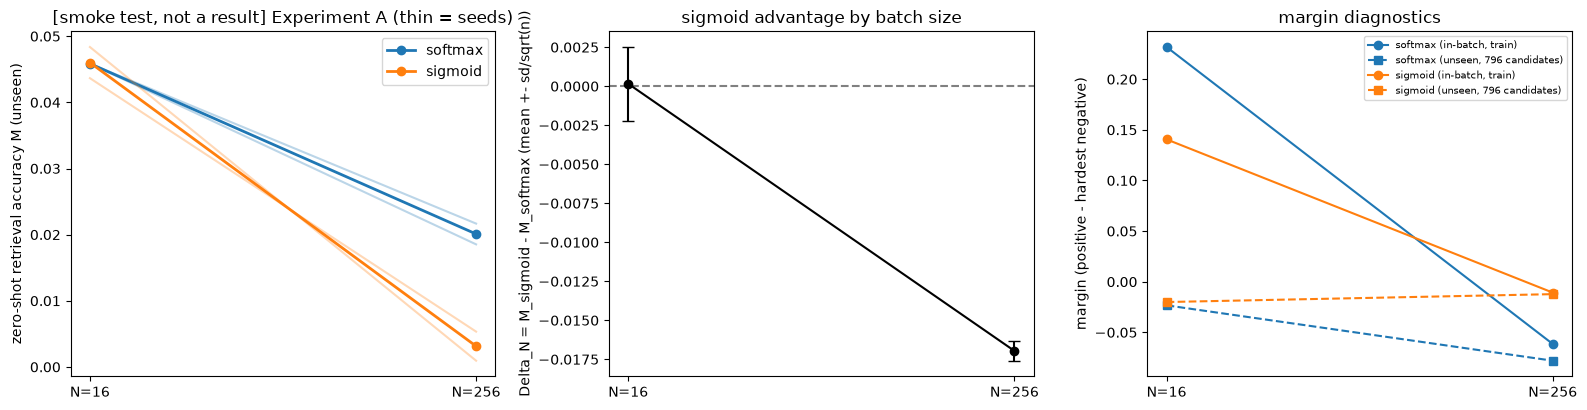

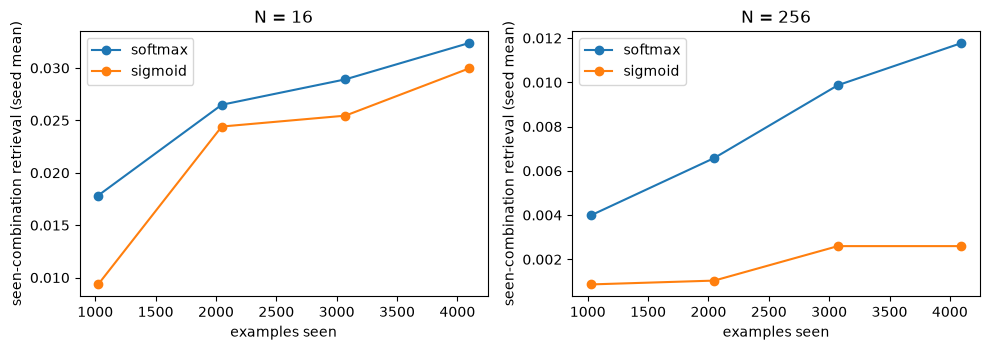

In [11]:
A_M = {
    (loss, n): np.array([zero_shot_accuracy(key_of(loss, n, s)) for s in SEEDS_A]) for loss in A_LOSSES for n in A_BATCH_SIZES
}
A_DELTA = {n: A_M[("sigmoid", n)] - A_M[("softmax", n)] for n in A_BATCH_SIZES}
_n_small, _n_large = min(A_BATCH_SIZES), max(A_BATCH_SIZES)
assert (_n_small, _n_large) == (16, 256)
CONTRAST_A = paired_contrast(A_DELTA[_n_small] - A_DELTA[_n_large])
verdict_A = judge(CONTRAST_A["value"], CONTRAST_A["sigma"])
_naive_sigma = math.sqrt(sum(A_M[(loss, n)].var(ddof=1) for loss in A_LOSSES for n in (_n_small, _n_large)) / len(SEEDS_A))
for _loss in A_LOSSES:
    for _n in A_BATCH_SIZES:
        precondition_status[f"P1({_loss},{_n})"] = seen_accuracy_mean(_loss, _n, SEEDS_A) >= SEEN_RETRIEVAL_MIN
# 前提条件は対比量 D に使う 4 条件(N = 16・256)のみ。N = 64(段階 0 のみ、診断)の P0・P1 は参考として印字する
A_CONTRAST_CONDITIONS = [(loss, n) for n in (_n_small, _n_large) for loss in A_LOSSES]
A_PRECONDITIONS = [f"P0({c[0]},{c[1]})" for c in CALIBRATION_CONDITIONS if c in A_CONTRAST_CONDITIONS] + [
    f"P1({c[0]},{c[1]})" for c in A_CONTRAST_CONDITIONS
]
_a_reference = [p for p in precondition_status if p.startswith(("P0(", "P1(")) and ",64)" in p]

print(f"{_tag}未見の組み合わせの検索の正解率 M(候補 {len(UNSEEN_CAPTION_IDS)} 個、チャンス水準 {1 / len(UNSEEN_CAPTION_IDS):.4f})、シード {SEEDS_A}")
for _n in A_BATCH_SIZES:
    for _loss in A_LOSSES:
        _keys = [key_of(_loss, _n, s) for s in SEEDS_A]
        _eval_margin = np.mean([final_of(k)["unseen_retrieval"]["mean_margin"] for k in _keys])
        _train_margin = np.mean([RECORDS[k]["train_margin_tail"] for k in _keys])
        _scale = np.mean([math.exp(RECORDS[k]["history"]["logit_scale"][-1]) for k in _keys])
        print(
            f"{_tag}  N = {_n:3d} {_loss:7s}: M {np.round(A_M[(_loss, _n)], 4).tolist()} 平均 {A_M[(_loss, _n)].mean():.4f}、"
            f"既知の検証 {seen_accuracy_mean(_loss, _n, SEEDS_A):.4f}、評価集合のマージン {_eval_margin:+.4f}、"
            f"学習中のバッチ内のマージン(末尾 10%){_train_margin:+.4f}、最終の倍率 exp(t) {_scale:.1f}"
        )
    _c = paired_contrast(A_DELTA[_n])
    print(f"{_tag}  N = {_n:3d}: Delta_N = M_sigmoid - M_softmax = {_c['value']:+.4f}(sd/sqrt(n) {_c['sigma']:.4f}、シードごと {np.round(_c['per_seed'], 4).tolist()})")
print(f"{_tag}d_s = Delta_16 - Delta_256: {np.round(CONTRAST_A['per_seed'], 4).tolist()}")
print(
    f"{_tag}対比量 D = {CONTRAST_A['value']:+.4f}、sigma_D = sd(d_s)/sqrt({len(SEEDS_A)}) = {CONTRAST_A['sigma']:.4f}、"
    f"閾値 2 sigma_D = {2 * CONTRAST_A['sigma']:.4f} -> 判定関数の結果: {verdict_A}"
)
print(f"{_tag}診断量: 相関を無視した標準偏差 sqrt(sum sd(M_c)^2 / n) = {_naive_sigma:.4f}")
print(f"{_tag}前提条件: " + "、".join(f"{p} = {precondition_status.get(p)}" for p in A_PRECONDITIONS) + f"(P1 の閾値 {SEEN_RETRIEVAL_MIN})")
if _a_reference:
    print(f"{_tag}参考(N = 64、判定に使わない): " + "、".join(f"{p} = {precondition_status[p]}" for p in _a_reference))

_fig, _axes = plt.subplots(1, 3, figsize=(16, 4.2))
_x = np.log2(A_BATCH_SIZES)
for _i, _loss in enumerate(A_LOSSES):
    _values = np.array([A_M[(_loss, n)] for n in A_BATCH_SIZES])  # (水準, シード)
    for _s in range(len(SEEDS_A)):
        _axes[0].plot(_x, _values[:, _s], color=f"C{_i}", alpha=0.3)
    _axes[0].plot(_x, _values.mean(axis=1), marker="o", color=f"C{_i}", lw=2, label=_loss)
    _margins = [np.mean([RECORDS[key_of(_loss, n, s)]["train_margin_tail"] for s in SEEDS_A]) for n in A_BATCH_SIZES]
    _axes[2].plot(_x, _margins, marker="o", color=f"C{_i}", label=f"{_loss} (in-batch, train)")
    _eval_margins = [np.mean([final_of(key_of(_loss, n, s))["unseen_retrieval"]["mean_margin"] for s in SEEDS_A]) for n in A_BATCH_SIZES]
    _axes[2].plot(_x, _eval_margins, marker="s", ls="--", color=f"C{_i}", label=f"{_loss} (unseen, 796 candidates)")
_axes[0].set_ylabel("zero-shot retrieval accuracy M (unseen)")
_axes[0].set_title(f"{_plot_tag}Experiment A (thin = seeds)")
_axes[0].legend()
_deltas = np.array([A_DELTA[n] for n in A_BATCH_SIZES])
_axes[1].errorbar(_x, _deltas.mean(axis=1), yerr=_deltas.std(axis=1, ddof=1) / math.sqrt(len(SEEDS_A)), marker="o", capsize=4, color="black")
_axes[1].axhline(0, color="gray", ls="--")
_axes[1].set_ylabel("Delta_N = M_sigmoid - M_softmax (mean +- sd/sqrt(n))")
_axes[1].set_title("sigmoid advantage by batch size")
_axes[2].set_ylabel("margin (positive - hardest negative)")
_axes[2].set_title("margin diagnostics")
_axes[2].legend(fontsize=7)
for _ax in _axes:
    _ax.set_xticks(_x, [f"N={n}" for n in A_BATCH_SIZES])
plt.tight_layout()
plt.show()

_fig, _axes = plt.subplots(1, len(A_BATCH_SIZES), figsize=(5 * len(A_BATCH_SIZES), 3.6), squeeze=False)
for _j, _n in enumerate(A_BATCH_SIZES):
    _t = steps_for(EXAMPLES, _n)
    _steps = list(intermediate_eval_steps_for(_t)) + [_t]
    for _i, _loss in enumerate(A_LOSSES):
        _curves = np.array(
            [[RECORDS[key_of(_loss, _n, s)]["history"]["evaluations"][t]["seen_accuracy"] for t in _steps[:-1]] + [RECORDS[key_of(_loss, _n, s)]["seen"]["accuracy"]] for s in SEEDS_A]
        )
        _axes[0, _j].plot(np.array(_steps) * _n, _curves.mean(axis=0), marker="o", color=f"C{_i}", label=_loss)
    _axes[0, _j].set_xlabel("examples seen")
    _axes[0, _j].set_ylabel("seen-combination retrieval (seed mean)")
    _axes[0, _j].set_title(f"N = {_n}")
    _axes[0, _j].legend()
plt.tight_layout()
plt.show()

### 6.8 実験 B: 標準の対照学習における bag-of-words 化の存在

[動作確認のみ、結論ではない] 標準条件 S(softmax・N = 256)、シード (0, 1)、2 択の試行の数 {'random': 6368, 'swap': 6368}
[動作確認のみ、結論ではない]   未見の組み合わせ acc_random: [0.9563, 0.9146] 平均 0.9355
[動作確認のみ、結論ではない]   未見の組み合わせ acc_swap: [0.5008, 0.5107] 平均 0.5057
[動作確認のみ、結論ではない]   未見の組み合わせ acc_attribute_swap: [0.5009, 0.5072] 平均 0.5041
[動作確認のみ、結論ではない]   未見の組み合わせ acc_order_swap: [0.5006, 0.5141] 平均 0.5074
[動作確認のみ、結論ではない]   既知の組み合わせ(診断量)acc_swap: 平均 0.5070
[動作確認のみ、結論ではない]   既知の組み合わせ(診断量)acc_attribute_swap: 平均 0.5135
[動作確認のみ、結論ではない]   既知の組み合わせ(診断量)acc_order_swap: 平均 0.5005
[動作確認のみ、結論ではない]   診断量: 旧定義(すべて未見の組み合わせから)の acc_rand 平均 0.9356(新定義との差 +0.0002)
[動作確認のみ、結論ではない]   診断量: 既知性の偏り = acc(未見の正例 vs 学習用のキャプション) - acc(未見の正例 vs 未見の組み合わせのキャプション) = -0.0052(sd/sqrt(n) 0.0046、シードごと [-0.0006, -0.0097])
[動作確認のみ、結論ではない] b_s = acc_rand - acc_swap: [0.4556, 0.4039]
[動作確認のみ、結論ではない] 対比量 B = +0.4297、sigma_B = sd(b_s)/sqrt(2) = 0.0258、閾値 0.0517 -> 判定関数の結果: 支持
[動作確認のみ、結論ではない] 前提条件: P0(softmax,256) = False、P1(softmax,256,BC) = False


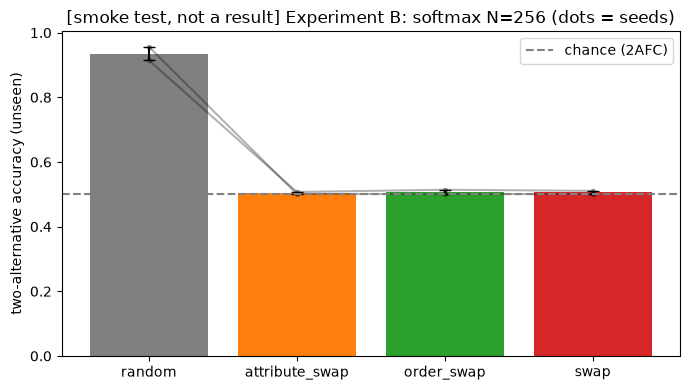

In [12]:
_b_keys = [key_of("softmax", STANDARD_BATCH_SIZE, s) for s in SEEDS_BC]
_two = {name: np.array([final_of(k)["unseen_two_alternative"][name] for k in _b_keys]) for name in ("random", "swap", "attribute_swap", "order_swap")}
_two_seen = {name: np.array([final_of(k)["seen_two_alternative"][name] for k in _b_keys]) for name in ("swap", "attribute_swap", "order_swap")}
CONTRAST_B = paired_contrast(_two["random"] - _two["swap"])
verdict_B = judge(CONTRAST_B["value"], CONTRAST_B["sigma"])
precondition_status[f"P1(softmax,{STANDARD_BATCH_SIZE},BC)"] = seen_accuracy_mean("softmax", STANDARD_BATCH_SIZE, SEEDS_BC) >= SEEN_RETRIEVAL_MIN
B_PRECONDITIONS = [f"P0(softmax,{STANDARD_BATCH_SIZE})", f"P1(softmax,{STANDARD_BATCH_SIZE},BC)"]

_counts = {name: final_of(_b_keys[0])["unseen_two_alternative"][f"{name}_count"] for name in ("random", "swap")}
print(f"{_tag}標準条件 S(softmax・N = {STANDARD_BATCH_SIZE})、シード {SEEDS_BC}、2 択の試行の数 {_counts}")
for _name, _values in _two.items():
    print(f"{_tag}  未見の組み合わせ acc_{_name}: {np.round(_values, 4).tolist()} 平均 {_values.mean():.4f}")
for _name, _values in _two_seen.items():
    print(f"{_tag}  既知の組み合わせ(診断量)acc_{_name}: 平均 {_values.mean():.4f}")
_old = np.array([final_of(k)["unseen_two_alternative"]["random_old"] for k in _b_keys])
_familiarity = np.array(
    [final_of(k)["unseen_two_alternative"]["random_train"] - final_of(k)["unseen_two_alternative"]["random_unseen"] for k in _b_keys]
)
print(f"{_tag}  診断量: 旧定義(すべて未見の組み合わせから)の acc_rand 平均 {_old.mean():.4f}(新定義との差 {(_old - _two['random']).mean():+.4f})")
_fam = paired_contrast(_familiarity)
print(
    f"{_tag}  診断量: 既知性の偏り = acc(未見の正例 vs 学習用のキャプション) - acc(未見の正例 vs 未見の組み合わせのキャプション) "
    f"= {_fam['value']:+.4f}(sd/sqrt(n) {_fam['sigma']:.4f}、シードごと {np.round(_familiarity, 4).tolist()})"
)
print(f"{_tag}b_s = acc_rand - acc_swap: {np.round(CONTRAST_B['per_seed'], 4).tolist()}")
print(
    f"{_tag}対比量 B = {CONTRAST_B['value']:+.4f}、sigma_B = sd(b_s)/sqrt({len(SEEDS_BC)}) = {CONTRAST_B['sigma']:.4f}、"
    f"閾値 {2 * CONTRAST_B['sigma']:.4f} -> 判定関数の結果: {verdict_B}"
)
print(f"{_tag}前提条件: " + "、".join(f"{p} = {precondition_status.get(p)}" for p in B_PRECONDITIONS))
assert _counts["random"] == _counts["swap"] == 2 * len(UNSEEN_IMAGES)

_fig, _ax = plt.subplots(figsize=(7, 4))
_names = ("random", "attribute_swap", "order_swap", "swap")
_ax.bar(range(4), [_two[n].mean() for n in _names], yerr=[_two[n].std(ddof=1) / math.sqrt(len(SEEDS_BC)) for n in _names], capsize=4, color=["gray", "C1", "C2", "C3"])
for _s in range(len(SEEDS_BC)):
    _ax.plot(range(4), [_two[n][_s] for n in _names], color="black", alpha=0.3, marker=".")
_ax.axhline(0.5, color="gray", ls="--", label="chance (2AFC)")
_ax.set_xticks(range(4), _names)
_ax.set_ylabel("two-alternative accuracy (unseen)")
_ax.set_title(f"{_plot_tag}Experiment B: softmax N={STANDARD_BATCH_SIZE} (dots = seeds)")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.9 実験 C: 困難な負例による改善(NegCLIP)

[動作確認のみ、結論ではない] NegCLIP と標準条件 S(N = 256、同じ E・同じ学習率 0.0005)、シード (0, 1)
[動作確認のみ、結論ではない]   S: 未見の組み合わせ acc_swap [0.5008, 0.5107] 平均 0.5057
[動作確認のみ、結論ではない]   NegCLIP: 未見の組み合わせ acc_swap [0.5036, 0.5064] 平均 0.5050
[動作確認のみ、結論ではない] c_s = acc_swap(NegCLIP) - acc_swap(S): [0.0028, -0.0042]
[動作確認のみ、結論ではない] 対比量 C = -0.0007、sigma_C = sd(c_s)/sqrt(2) = 0.0035、閾値 0.0071 -> 判定関数の結果: 判定不能
[動作確認のみ、結論ではない] 診断量(判定なし、NegCLIP - S のシード平均と sd/sqrt(n)):
[動作確認のみ、結論ではない]   既知の組み合わせの acc_swap(作用点に近い量): NegCLIP 0.5093・S 0.5070、差 +0.0023(0.0004)
[動作確認のみ、結論ではない]   未見の acc_attribute_swap: NegCLIP 0.5061・S 0.5041、差 +0.0020(0.0039)
[動作確認のみ、結論ではない]   未見の acc_order_swap: NegCLIP 0.5039・S 0.5074、差 -0.0035(0.0031)
[動作確認のみ、結論ではない]   未見の acc_rand(代償): NegCLIP 0.9331・S 0.9355、差 -0.0024(0.0000)
[動作確認のみ、結論ではない]   M(代償): NegCLIP 0.0232・S 0.0201、差 +0.0031(0.0041)
[動作確認のみ、結論ではない] 前提条件: P0(softmax,256) = False、P1(softmax,256,BC) = False、P1(negclip,256) = False


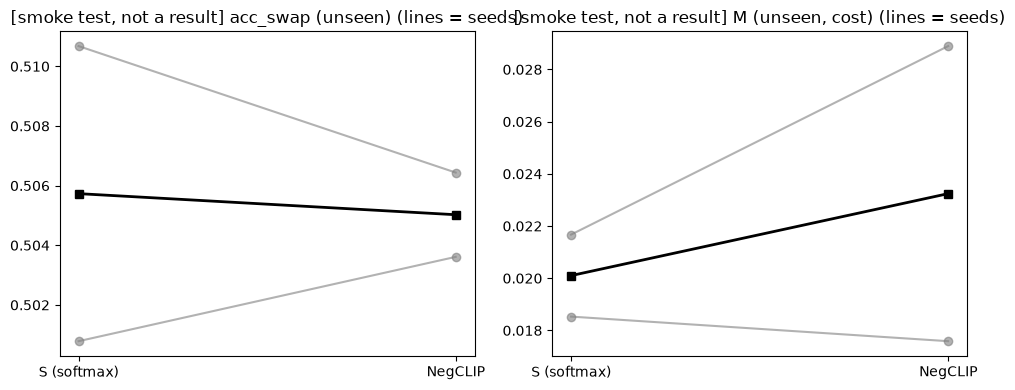

In [13]:
_std_keys = [key_of("softmax", STANDARD_BATCH_SIZE, s) for s in SEEDS_BC]
_neg_keys = [key_of("negclip", STANDARD_BATCH_SIZE, s) for s in SEEDS_BC]


def _collect(keys, group, name):
    return np.array([final_of(k)[group][name] for k in keys])


C_SWAP = {"S": _collect(_std_keys, "unseen_two_alternative", "swap"), "NegCLIP": _collect(_neg_keys, "unseen_two_alternative", "swap")}
CONTRAST_C = paired_contrast(C_SWAP["NegCLIP"] - C_SWAP["S"])
verdict_C = judge(CONTRAST_C["value"], CONTRAST_C["sigma"])
precondition_status[f"P1(negclip,{STANDARD_BATCH_SIZE})"] = seen_accuracy_mean("negclip", STANDARD_BATCH_SIZE, SEEDS_BC) >= SEEN_RETRIEVAL_MIN
C_PRECONDITIONS = B_PRECONDITIONS + [f"P1(negclip,{STANDARD_BATCH_SIZE})"]
_diag = {
    "既知の組み合わせの acc_swap(作用点に近い量)": (_collect(_neg_keys, "seen_two_alternative", "swap"), _collect(_std_keys, "seen_two_alternative", "swap")),
    "未見の acc_attribute_swap": (_collect(_neg_keys, "unseen_two_alternative", "attribute_swap"), _collect(_std_keys, "unseen_two_alternative", "attribute_swap")),
    "未見の acc_order_swap": (_collect(_neg_keys, "unseen_two_alternative", "order_swap"), _collect(_std_keys, "unseen_two_alternative", "order_swap")),
    "未見の acc_rand(代償)": (_collect(_neg_keys, "unseen_two_alternative", "random"), _collect(_std_keys, "unseen_two_alternative", "random")),
    "M(代償)": (np.array([zero_shot_accuracy(k) for k in _neg_keys]), np.array([zero_shot_accuracy(k) for k in _std_keys])),
}

print(f"{_tag}NegCLIP と標準条件 S(N = {STANDARD_BATCH_SIZE}、同じ E・同じ学習率 {learning_rate_for(_std_keys[0]):.3g})、シード {SEEDS_BC}")
for _name, _values in C_SWAP.items():
    print(f"{_tag}  {_name}: 未見の組み合わせ acc_swap {np.round(_values, 4).tolist()} 平均 {_values.mean():.4f}")
print(f"{_tag}c_s = acc_swap(NegCLIP) - acc_swap(S): {np.round(CONTRAST_C['per_seed'], 4).tolist()}")
print(
    f"{_tag}対比量 C = {CONTRAST_C['value']:+.4f}、sigma_C = sd(c_s)/sqrt({len(SEEDS_BC)}) = {CONTRAST_C['sigma']:.4f}、"
    f"閾値 {2 * CONTRAST_C['sigma']:.4f} -> 判定関数の結果: {verdict_C}"
)
print(f"{_tag}診断量(判定なし、NegCLIP - S のシード平均と sd/sqrt(n)):")
for _name, (_neg, _std) in _diag.items():
    _c = paired_contrast(_neg - _std)
    print(f"{_tag}  {_name}: NegCLIP {_neg.mean():.4f}・S {_std.mean():.4f}、差 {_c['value']:+.4f}({_c['sigma']:.4f})")
print(f"{_tag}前提条件: " + "、".join(f"{p} = {precondition_status.get(p)}" for p in C_PRECONDITIONS))

_fig, _axes = plt.subplots(1, 2, figsize=(10, 4))
for _j, (_title, _pair) in enumerate((("acc_swap (unseen)", (C_SWAP["S"], C_SWAP["NegCLIP"])), ("M (unseen, cost)", (_diag["M(代償)"][1], _diag["M(代償)"][0])))):
    for _s in range(len(SEEDS_BC)):
        _axes[_j].plot([0, 1], [_pair[0][_s], _pair[1][_s]], color="gray", marker="o", alpha=0.6)
    _axes[_j].plot([0, 1], [_pair[0].mean(), _pair[1].mean()], color="black", marker="s", lw=2)
    _axes[_j].set_xticks([0, 1], ["S (softmax)", "NegCLIP"])
    _axes[_j].set_title(f"{_plot_tag}{_title} (lines = seeds)")
plt.tight_layout()
plt.show()

### 6.10 観察: modality gap(判定基準を設けない)

**判定基準を設けない観察である。** 未見の組み合わせの評価集合で、画像の埋め込みの重心とキャプションの埋め込みの重心の距離
$\Delta_{\mathrm{gap}}$(3.8 節)を、学習の前(初期化の時点)と後で比べる。シード 0 のモデルについて、画像とテキストの埋め込み(各 400 個)を
合わせて主成分分析で 2 次元に射影した図を示す。単位球面上の埋め込みの重心間の距離は、最大で 2 である。

[動作確認のみ、結論ではない] modality gap(未見の組み合わせの評価集合、シード平均): 条件 | 学習前 | 学習後(未見)| 学習後(既知)
[動作確認のみ、結論ではない]   sigmoid N= 16: 1.372 | 0.054 | 0.031(2 シード)
[動作確認のみ、結論ではない]   softmax N= 16: 1.372 | 0.123 | 0.118(2 シード)
[動作確認のみ、結論ではない]   negclip N=256: 1.372 | 0.636 | 0.627(2 シード)
[動作確認のみ、結論ではない]   sigmoid N=256: 1.372 | 1.031 | 1.030(2 シード)
[動作確認のみ、結論ではない]   softmax N=256: 1.372 | 0.613 | 0.602(2 シード)


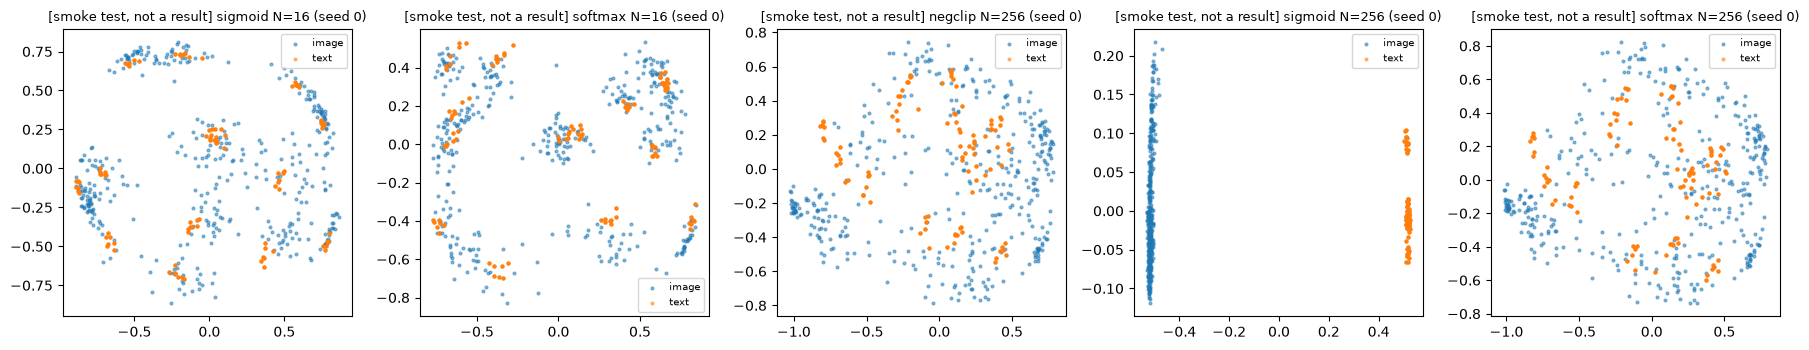

In [14]:
_gap_keys = sorted({(k[0], k[1]) for k in RECORDS}, key=lambda c: (c[1], c[0]))
print(f"{_tag}modality gap(未見の組み合わせの評価集合、シード平均): 条件 | 学習前 | 学習後(未見)| 学習後(既知)")
for _c in _gap_keys:
    _keys = [k for k in RECORDS if (k[0], k[1]) == _c]
    print(
        f"{_tag}  {_c[0]:7s} N={_c[1]:3d}: {np.mean([RECORDS[k]['gap_unseen_at_init'] for k in _keys]):.3f} | "
        f"{np.mean([final_of(k)['gap_unseen'] for k in _keys]):.3f} | {np.mean([final_of(k)['gap_seen'] for k in _keys]):.3f}"
        f"({len(_keys)} シード)"
    )
_proj_conditions = [c for c in _gap_keys if key_of(*c, 0) in RECORDS]
_fig, _axes = plt.subplots(1, len(_proj_conditions), figsize=(3.6 * len(_proj_conditions), 3.6), squeeze=False)
for _j, _c in enumerate(_proj_conditions):
    _p = final_of(key_of(*_c, 0))["projection"]
    _all = np.concatenate([_p["image"], _p["text"]])
    _centered = _all - _all.mean(axis=0)
    _, _, _vt = np.linalg.svd(_centered, full_matrices=False)
    _xy = _centered @ _vt[:2].T
    _k = len(_p["image"])
    _axes[0, _j].scatter(_xy[:_k, 0], _xy[:_k, 1], s=4, alpha=0.5, label="image")
    _axes[0, _j].scatter(_xy[_k:, 0], _xy[_k:, 1], s=4, alpha=0.5, label="text")
    _axes[0, _j].set_title(f"{_plot_tag}{_c[0]} N={_c[1]} (seed 0)", fontsize=9)
    _axes[0, _j].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.11 不変条件のアサーションと`SMOKE_TEST`の配線

- すべての学習(較正を含む)で、見た事例数が $E$、ステップ数が $E/N$、学習率のスケジュールの形(最大値で割った列)が同じ $N$ の間で
  同一、すべてのバッチでキャプションが互いに異なる。
- 同じシードの学習は、損失・$N$ によらず同じ初期値(温度とバイアスを除く)から始まった。同じシード・同じ $N$ の学習は、損失によらず
  同じ順序で同じシーンを見た(バッチの添字の列のハッシュが一致)。
- 本番の学習はすべて同じ未見の組み合わせの評価集合(3,184 枚、候補 796 個)で評価した(画像のテンソルが読み込み直後と一致、2 択の試行の数が
  一致)。較正の学習は未見の組み合わせの評価集合を評価していない。
- 標準条件 S の記録を、実験 A の $N = 256$ の softmax・実験 B・実験 C の標準のモデルで共有した(同じ鍵)。
- **`SMOKE_TEST`の配線**: 5.2 節・6.4 節で決まった実効値(水準・計画・$E$・段階・シード数・$N$ の水準)が計画の表どおりであり、実際に
  使われた値(記録の鍵・学習の記録の長さ)と一致する。

In [15]:
_all_records = list(RECORDS.values()) + [r for c in CALIBRATION.values() for r in c["records"].values()]
_shapes: dict[int, np.ndarray] = {}
for _r in _all_records:
    _h, _n = _r["history"], _r["key"][1]
    assert _r["examples"] == EXAMPLES and _h["examples_seen"] == EXAMPLES
    assert _r["train_steps"] == steps_for(EXAMPLES, _n) == len(_h["loss"]) == len(_h["learning_rate"])
    assert set(_h["evaluations"]) == set(intermediate_eval_steps_for(_r["train_steps"]))
    assert _h["distinct_captions_in_every_batch"]
    _normalized = np.array(_h["learning_rate"]) / _r["learning_rate"]
    _shapes.setdefault(_n, _normalized)
    assert np.allclose(_normalized, _shapes[_n], rtol=1e-12, atol=0), "学習率のスケジュールの形が異なる"
_init_by_seed: dict[int, set] = {}
_stream_by_seed_n: dict[tuple, set] = {}
for _r in _all_records:
    _init_by_seed.setdefault(_r["key"][2], set()).add(_r["initial_state_sha256"])
    _stream_by_seed_n.setdefault((_r["key"][2], _r["key"][1]), set()).add(_r["history"]["data_stream_hash"])
assert all(len(v) == 1 for v in _init_by_seed.values()), "同じシードで初期値が異なる"
assert all(len(v) == 1 for v in _stream_by_seed_n.values()), "同じシード・同じ N でバッチの順序が異なる"
for _r in _all_records:  # テキスト encoder に入れた系列(正例と困難な負例)は、除外した組を含まない
    assert TRAIN_CAPTION_MASK[_r["history"]["text_caption_ids"]].all(), _r["key"]
_negclip_records = [r for r in _all_records if r["key"][0] == "negclip"]
_attr_used = sum(r["history"]["hard_negatives_used"]["attribute_swap"] for r in _negclip_records)
_attr_generated = sum(r["history"]["hard_negatives_generated"]["attribute_swap"] for r in _negclip_records)
for _r in RECORDS.values():
    _f = _r["final"]
    assert _r["purpose"] == "main"
    assert _f["unseen_retrieval"]["num_candidates"] == len(UNSEEN_CAPTION_IDS) and _f["unseen_retrieval"]["num_images"] == len(UNSEEN_IMAGES)
    assert _f["unseen_two_alternative"]["swap_count"] == _f["unseen_two_alternative"]["random_count"] == 2 * len(UNSEEN_IMAGES)
for _c in CALIBRATION.values():
    assert all(r["purpose"] == "calibration" and "final" not in r for r in _c["records"].values())
assert sha256_of_tensor(UNSEEN_IMAGES) == UNSEEN_IMAGES_SHA256
for _s in set(SEEDS_A) | set(SEEDS_BC):  # S は 1 つの記録を共有する
    assert key_of("softmax", STANDARD_BATCH_SIZE, _s) in RECORDS
print(
    f"不変条件: 全 {len(_all_records)} 学習(本番 {len(RECORDS)}・較正 {len(_all_records) - len(RECORDS)})で見た事例数 E = {EXAMPLES:,}・"
    f"ステップ数 E/N・学習率のスケジュールの形(同じ N の間)が同一、全バッチでキャプションが互いに異なる、同じシードの初期値が同一"
    f"({len(_init_by_seed)} シード)、同じシード・同じ N のバッチの順序が損失によらず同一({len(_stream_by_seed_n)} 組)、"
    f"本番はすべて同じ評価集合(候補 {len(UNSEEN_CAPTION_IDS)} 個・{len(UNSEEN_IMAGES):,} 枚)で評価、較正は評価集合を評価していない、S を共有、"
    f"全学習でテキスト encoder に入れた系列が除外した組を含まない: OK。NegCLIP で分母に加えた色の入れ替えは規則が作った数の "
    f"{_attr_used / _attr_generated:.3f}(順序の入れ替えはすべて)"
)

_table = PLANS[CURRENT_LEVEL_NAME][SELECTED_PLAN]
assert _table["plan"] == SELECTED_PLAN and _table["E"] == EXAMPLES and _table["stage"] == SELECTED_STAGE
assert EXAMPLES == EXAMPLE_CANDIDATES[CURRENT_LEVEL_NAME][SELECTED_PLAN // 4] and SELECTED_STAGE == SELECTED_PLAN % 4
_stage_table = STAGES[CURRENT_LEVEL_NAME][_table["stage"]]
_effective = {
    "level": CURRENT_LEVEL_NAME,
    "plan": SELECTED_PLAN,
    "stage": SELECTED_STAGE,
    "examples": EXAMPLES,
    "seeds_a": _stage_table["SEEDS_A"],
    "seeds_bc": _stage_table["SEEDS_BC"],
    "a_batch_sizes": list(_stage_table["A_BATCH_SIZES"]),
    "calibration_mode": CALIBRATION_MODE,
    "calibrated_conditions": len(calibration_conditions(_stage_table, CALIBRATION_MODE)),
    "runs": len(plan_runs(_stage_table)),
}
_examples_used = {r["history"]["examples_seen"] for r in _all_records}
assert len(_examples_used) == 1
_used = {
    "level": CURRENT_LEVEL_NAME,
    "plan": SELECTED_PLAN,
    "stage": SELECTED_STAGE,
    "examples": _examples_used.pop(),
    "seeds_a": len({k[2] for k in RECORDS if k[0] == "sigmoid"}),
    "seeds_bc": len({k[2] for k in RECORDS if k[0] == "negclip"}),
    "a_batch_sizes": sorted({k[1] for k in RECORDS if k[0] == "sigmoid"}),
    "calibration_mode": CALIBRATION_MODE,
    "calibrated_conditions": len(CALIBRATION),
    "runs": len(RECORDS),
}
assert _used == _effective, (_used, _effective)
assert (CURRENT_LEVEL_NAME == "smoke") == SMOKE_TEST
print(f"SMOKE_TEST={SMOKE_TEST} の配線: 実効値 {json.dumps(_effective)} と実際に使われた値が一致: OK")

不変条件: 全 24 学習(本番 10・較正 14)で見た事例数 E = 4,096・ステップ数 E/N・学習率のスケジュールの形(同じ N の間)が同一、全バッチでキャプションが互いに異なる、同じシードの初期値が同一(3 シード)、同じシード・同じ N のバッチの順序が損失によらず同一(6 組)、本番はすべて同じ評価集合(候補 796 個・3,184 枚)で評価、較正は評価集合を評価していない、S を共有、全学習でテキスト encoder に入れた系列が除外した組を含まない: OK。NegCLIP で分母に加えた色の入れ替えは規則が作った数の 0.512(順序の入れ替えはすべて)
SMOKE_TEST=True の配線: 実効値 {"level": "smoke", "plan": 7, "stage": 3, "examples": 4096, "seeds_a": 2, "seeds_bc": 2, "a_batch_sizes": [16, 256], "calibration_mode": "all", "calibrated_conditions": 4, "runs": 10} と実際に使われた値が一致: OK


### 6.12 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は参考として
別欄に残す。選ばれた計画($E$・段階)と、判定に実際に使ったシード数・水準を印字する。

In [16]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


print(f"{_tag}計画の選択: {PLAN_SELECTION_MESSAGE}")
print(
    f"{_tag}判定に使った値: 計画 {SELECTED_PLAN}(E = {EXAMPLES:,}、段階 {SELECTED_STAGE})、較正の方式 {CALIBRATION_MODE!r}、"
    f"n_A = {len(SEEDS_A)}(N {A_BATCH_SIZES})、n_BC = {len(SEEDS_BC)}"
)
VERDICT_ROWS = [
    ("A", f"D = {CONTRAST_A['value']:+.4f}(sigma {CONTRAST_A['sigma']:.4f})", A_PRECONDITIONS, verdict_A),
    ("B", f"B = {CONTRAST_B['value']:+.4f}(sigma {CONTRAST_B['sigma']:.4f})", B_PRECONDITIONS, verdict_B),
    ("C", f"C = {CONTRAST_C['value']:+.4f}(sigma {CONTRAST_C['sigma']:.4f})", C_PRECONDITIONS, verdict_C),
]
print(f"{_tag}実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定")
for _name, _value, _pre, _computed in VERDICT_ROWS:
    print(f"{_tag}{_name} | {_value} | " + ", ".join(f"{p}={precondition_status.get(p)}" for p in _pre) + f" | {_computed} | {verdict_label(_computed, _pre)}")
print(f"\nノートブック全体の実行時間(アップロードの前まで): {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

[動作確認のみ、結論ではない] 計画の選択: 計画 7 でも見積もり 148.7 分が予算 118.9 分を超える(本番なら学習の前に停止する)。スモークテストのため停止せず、計画 7 で動作確認を続ける
[動作確認のみ、結論ではない] 判定に使った値: 計画 7(E = 4,096、段階 3)、較正の方式 'all'、n_A = 2(N (16, 256))、n_BC = 2
[動作確認のみ、結論ではない] 実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定
[動作確認のみ、結論ではない] A | D = +0.0171(sigma 0.0030) | P0(softmax,16)=True, P0(sigmoid,16)=True, P0(softmax,256)=False, P0(sigmoid,256)=True, P1(softmax,16)=False, P1(sigmoid,16)=False, P1(softmax,256)=False, P1(sigmoid,256)=False | 支持 | 前提不成立
[動作確認のみ、結論ではない] B | B = +0.4297(sigma 0.0258) | P0(softmax,256)=False, P1(softmax,256,BC)=False | 支持 | 前提不成立
[動作確認のみ、結論ではない] C | C = -0.0007(sigma 0.0035) | P0(softmax,256)=False, P1(softmax,256,BC)=False, P1(negclip,256)=False | 判定不能 | 前提不成立

ノートブック全体の実行時間(アップロードの前まで): 4.6 分


### 6.13 アップロード(NegCLIP・シード 0 のモデル)

実験 C の NegCLIP・$N = 256$・シード 0 のモデル(両方の encoder・射影・温度とバイアス)を、`kojikojiprg/ai-theories-clip-synthetic-scenes`の
`main`ブランチにアップロードする。**対象は結果を見て選ばず、この指定で固定する**(6.1 節)。

- 重みを`model_state.pt`に保存して読み戻し、**読み戻した重みそのもので評価し直した値** をモデルカードの性能指標にする(学習中に記録した
  値を流用しない。読み戻した値と学習直後の評価の差も印字する)。
- `config.json`にモデルの構成・語彙(検証用)・データの生成規則の所在とコミット・学習の設定を書く。トークナイザとデータは
  `src/data/synthetic_scenes.py`の規則から決定的に再生成できるので同梱しない。
- **安全装置**: (1)`UPLOAD_ARTIFACTS = True`のときのみアップロードする(既定は`False`、`SMOKE_TEST`とは独立)。(2)`SMOKE_TEST = True`の
  重みはアップロードしない。(3)前提条件 P1(NegCLIP)が成立しない重み(学習が進んでいない重み)はアップロードしない。
  (4)Colab Secrets から`HF_TOKEN`を取得できない場合は、例外で停止せずスキップして印字する。(5)アップロードの後、`list_repo_files`で
  3 つのファイルが存在することを確かめ、`model_state.pt`をダウンロードし直して SHA-256 が一致することを確かめる。

In [17]:
from huggingface_hub import HfApi, hf_hub_download  # noqa: E402

UPLOAD_FILES = ("model_state.pt", "config.json", "README.md")
_upload_record = RECORDS[UPLOAD_KEY]
_upload_dir = Path(tempfile.mkdtemp())
CHECKPOINT_PATH = _upload_dir / "model_state.pt"
torch.save(_upload_record["state_dict"], CHECKPOINT_PATH)
_reloaded_state = torch.load(CHECKPOINT_PATH, map_location="cpu")
assert _reloaded_state.keys() == _upload_record["state_dict"].keys()
assert all(torch.equal(_reloaded_state[k], _upload_record["state_dict"][k]) for k in _reloaded_state)
CHECKPOINT_SHA256 = hashlib.sha256(CHECKPOINT_PATH.read_bytes()).hexdigest()

# 読み戻した重みそのもので評価し直す(モデルカードの性能指標)
torch.manual_seed(0)
_uploaded_model = build_clip("negclip")
_uploaded_model.load_state_dict(_reloaded_state)
_uploaded_model = _uploaded_model.to(device)
UPLOADED_METRICS = {"seen": evaluate_seen(_uploaded_model), "final": evaluate_final(_uploaded_model, keep_projection=False)}
del _uploaded_model
_recorded = {"M": zero_shot_accuracy(UPLOAD_KEY), "seen": _upload_record["seen"]["accuracy"]}
_reevaluated = {"M": UPLOADED_METRICS["final"]["unseen_retrieval"]["accuracy"], "seen": UPLOADED_METRICS["seen"]["accuracy"]}
print(f"保存・読み戻しで全 {len(_reloaded_state)} テンソルが一致: OK。バイト数 {CHECKPOINT_PATH.stat().st_size:,}、SHA-256 {CHECKPOINT_SHA256}")
print(f"読み戻した重みで評価し直した値 {_reevaluated}(学習直後の評価 {_recorded}、差 " + "、".join(f"{k} {_reevaluated[k] - _recorded[k]:+.2e}" for k in _recorded) + ")")
assert all(abs(_reevaluated[k] - _recorded[k]) <= 1 / len(UNSEEN_IMAGES) for k in _recorded)  # 高々 1 枚の違いまで(演算の丸め)

UPLOAD_CONFIG = {
    "architecture": "CLIPDualEncoder (src/models/clip.py): VisionTransformer (src/models/vit.py) + CausalTextTransformer",
    "vision_config": VISION_CONFIG,
    "text_config": TEXT_CONFIG | {"vocabulary_size": len(VOCABULARY), "end_token_id": VOCABULARY.end_id},
    "embedding_dim": EMBEDDING_DIM,
    "loss": "negclip",
    "vocabulary": list(VOCABULARY.tokens),
    "data_generator": "src/data/synthetic_scenes.py (build_caption_universe, render_scenes)",
    "holdout_pairs": [[COLOR_NAMES[c], SHAPES[s]] for c, s in sorted(HOLDOUT)],
    "render_seeds": {"train": TRAIN_RENDER_SEED, "validation": VALIDATION_RENDER_SEED, "unseen": UNSEEN_RENDER_SEED},
    "training": {
        "examples": EXAMPLES,
        "batch_size": STANDARD_BATCH_SIZE,
        "steps": steps_for(EXAMPLES, STANDARD_BATCH_SIZE),
        "peak_learning_rate": _upload_record["learning_rate"],
        "seed": UPLOAD_KEY_SEED,
        "hard_negatives": ["attribute_swap", "order_swap"],
    },
    "source_commit": execution_environment.get("git_commit"),
    "source_has_uncommitted_changes": execution_environment.get("git_has_uncommitted_changes"),
    "model_state_sha256": CHECKPOINT_SHA256,
}
CONFIG_PATH = _upload_dir / "config.json"
CONFIG_PATH.write_text(json.dumps(UPLOAD_CONFIG, ensure_ascii=False, indent=2))


def build_model_card() -> str:
    two = UPLOADED_METRICS["final"]["unseen_two_alternative"]
    commit = UPLOAD_CONFIG["source_commit"]
    return f'''---
language: en
license: mit
tags:
- ai-theories
- clip
- negclip
- contrastive-learning
- synthetic-data
- scratch-implementation
---

# ai-theories CLIP(合成のシーン、NegCLIP)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
[020. CLIP と対照学習](https://github.com/kojikojiprg/ai-theories/blob/main/theories/05_vision_language/020_clip_contrastive_learning.ipynb)
の実験 C で学習した、NegCLIP(困難な負例のキャプションを画像 -> テキストの分母に加えた対照学習)のモデル(バッチサイズ {STANDARD_BATCH_SIZE}・
見た事例数 {EXAMPLES:,}・シード {UPLOAD_KEY_SEED})。画像 encoder(ViT)・テキスト encoder(因果マスクつきの Transformer)・共通の埋め込み空間への
射影・温度を含む。021 の入力として使うことを想定している。

スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。
学習データは 2 つの図形(8 色 x 5 種類)を左右または上下に並べた 32 x 32 の合成画像と、規則で生成した英語のキャプションのみであり、
実画像には使えない。

## 構成

`config.json` を参照。モデルのクラスは `src/models/clip.py` の `CLIPDualEncoder`(画像側は `src/models/vit.py` の `VisionTransformer`)。

**トークナイザとデータはこのリポジトリには同梱していない。** どちらも `src/data/synthetic_scenes.py` の規則から決定的に再生成できる
(`CaptionVocabulary`・`build_caption_universe()`・`render_scenes()`。描画のシードは `config.json` の `render_seeds`)。語彙は検証用に
`config.json` の `vocabulary` にも記載した。取得時点のリポジトリのコミット: `{commit}`。

## 性能指標(アップロードした重みそのものを評価した値)

- 未見の (色, 形) の組み合わせを含む評価集合({len(UNSEEN_IMAGES):,} 枚、候補のキャプション {len(UNSEEN_CAPTION_IDS)} 個)での zero-shot の
  画像 -> テキストの検索の top-1 正解率: {UPLOADED_METRICS["final"]["unseen_retrieval"]["accuracy"]:.4f}
- 同じ評価集合での 2 択の正解率: 困難な負例(色の入れ替え・順序の入れ替え){two["swap"]:.4f}
  (色の入れ替え {two["attribute_swap"]:.4f}・順序の入れ替え {two["order_swap"]:.4f})、ランダムな負例 {two["random"]:.4f}
- 既知の組み合わせの検証集合({len(VALIDATION_IMAGES):,} 枚、候補 {len(TRAIN_CAPTION_IDS):,} 個)での検索の正解率: {UPLOADED_METRICS["seen"]["accuracy"]:.4f}

## 検証情報

- SHA-256(`model_state.pt`): `{CHECKPOINT_SHA256}`

## 関連ノートブック

- [019. ViT と画像パッチ埋め込み](https://github.com/kojikojiprg/ai-theories/blob/main/theories/05_vision_language/019_vision_transformer.ipynb)
- [020. CLIP と対照学習](https://github.com/kojikojiprg/ai-theories/blob/main/theories/05_vision_language/020_clip_contrastive_learning.ipynb)
'''


README_PATH = _upload_dir / "README.md"
README_PATH.write_text(build_model_card())


def upload_skip_reason(upload_artifacts: bool, smoke_test: bool, learned: bool) -> str | None:
    # アップロードをスキップする理由(スキップしないなら None)。判定の順序: UPLOAD_ARTIFACTS -> SMOKE_TEST -> P1(NegCLIP)
    if not upload_artifacts:
        return "UPLOAD_ARTIFACTS = False のため、アップロードをスキップした。"
    if smoke_test:
        return "SMOKE_TEST = True のため、スモークテストの重みはアップロードしない(スキップした)。"
    if not learned:
        return "前提条件 P1(NegCLIP)が成立していないため、アップロードをスキップした(学習が進んでいない重みは公開しない)。"
    return None


for _upload, _smoke, _learned in itertools.product((False, True), repeat=3):  # 分岐の順序の確認(全 8 通り)
    _reason = upload_skip_reason(_upload, _smoke, _learned)
    assert (_reason is None) == (_upload and not _smoke and _learned)
    assert _upload or _reason.startswith("UPLOAD_ARTIFACTS")
    assert not (_upload and _smoke) or _reason.startswith("SMOKE_TEST")
    assert not (_upload and not _smoke and not _learned) or _reason.startswith("前提条件 P1")
print("アップロードの分岐(UPLOAD_ARTIFACTS -> SMOKE_TEST -> P1(NegCLIP) -> HF_TOKEN)の全 8 通りの確認: OK")

_learned = bool(precondition_status.get(f"P1(negclip,{STANDARD_BATCH_SIZE})"))
_skip_reason = upload_skip_reason(UPLOAD_ARTIFACTS, SMOKE_TEST, _learned)
print(f"UPLOAD_ARTIFACTS = {UPLOAD_ARTIFACTS}、SMOKE_TEST = {SMOKE_TEST}、P1(NegCLIP) = {_learned}、アップロードする鍵 {UPLOAD_KEY}")
if _skip_reason is not None:
    print(_skip_reason)
else:
    _hf_token = None
    try:
        from google.colab import userdata

        _hf_token = userdata.get("HF_TOKEN")
    except Exception as _e:  # noqa: BLE001  # Colab Secrets 未設定・非 Colab 環境など理由を問わずスキップする
        print(f"Colab Secrets から HF_TOKEN を取得できなかったため、アップロードをスキップした: {type(_e).__name__}")
    if not _hf_token:
        print("HF_TOKEN がないため、アップロードをスキップした。")
    else:
        _api = HfApi(token=_hf_token)
        _api.create_repo(repo_id=HUB_REPO_ID, repo_type="model", exist_ok=True)
        for _path in (CHECKPOINT_PATH, CONFIG_PATH, README_PATH):
            _api.upload_file(path_or_fileobj=str(_path), path_in_repo=_path.name, repo_id=HUB_REPO_ID, revision="main")
        # upload_file が例外を送出しなかったことだけを成功の根拠にせず、存在と内容を確かめる
        _files = set(_api.list_repo_files(repo_id=HUB_REPO_ID, revision="main"))
        for _expected in UPLOAD_FILES:
            assert _expected in _files, f"{_expected} が {HUB_REPO_ID}@main に見つからない"
        _downloaded = hf_hub_download(HUB_REPO_ID, "model_state.pt", revision="main", force_download=True, token=_hf_token)
        assert hashlib.sha256(Path(_downloaded).read_bytes()).hexdigest() == CHECKPOINT_SHA256
        print(
            f"[OK] アップロード完了。list_repo_files で {UPLOAD_FILES} の存在を確認し、model_state.pt の SHA-256 が一致した: "
            f"https://huggingface.co/{HUB_REPO_ID}"
        )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


保存・読み戻しで全 110 テンソルが一致: OK。バイト数 6,504,819、SHA-256 fdb3e6c1d1c9436e6b81322f68107a14af5ade487c80a7f9031611b0d9eeb16e
読み戻した重みで評価し直した値 {'M': 0.028894472361809045, 'seen': 0.014196675900277008}(学習直後の評価 {'M': 0.028894472361809045, 'seen': 0.014196675900277008}、差 M +0.00e+00、seen +0.00e+00)
アップロードの分岐(UPLOAD_ARTIFACTS -> SMOKE_TEST -> P1(NegCLIP) -> HF_TOKEN)の全 8 通りの確認: OK
UPLOAD_ARTIFACTS = False、SMOKE_TEST = True、P1(NegCLIP) = False、アップロードする鍵 ('negclip', 256, 0)
UPLOAD_ARTIFACTS = False のため、アップロードをスキップした。

ノートブック全体の実行時間: 4.7 分


## 7. 結果・考察 / Results and Discussion

**(本番実行の後に記述する。第 1 段階の時点では、節の見出しと何を書くかのみを置く。スモークテストの数値に基づく考察は書かない。)**

判定(7.2〜7.5 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.7 節に分けて記し、検証済みの結論としては
扱わない。

### 7.1 実行の概要

- 実行環境(5.1 節の印字: GPU・compute capability・メモリ、Python・torch・CUDA・cuDNN、コミット、未コミットの変更の有無、実行日時)と、
  混合精度の実効設定。
- データの準備・確認・スケーリングの計測にかかった時間と、計画の選択の時点の残りの予算。
- T4 の 1 ステップの時間(6.3 節、損失 × $N$ の 7 種類)と、スモークテスト(ローカルの MPS)の値との比。
- 選ばれた計画($E$・段階)と、その見積もり。`CALIBRATION_MODE`の 2 つの値の判断材料の印字(それぞれで選ばれる計画)。
- 実際の実行時間(較正・本番の学習と評価・全体)と、見積もりとの差。
- 学習率の較正の表(条件ごとの格子点と既知の組み合わせの検証集合の正解率、拡張の有無、選んだ学習率)。
- 損失スケーリングで飛ばしたステップの数、最終の倍率 $e^t$。

### 7.2 前提条件

- P0(較正した各条件)と P1(各条件)の値と成否の表と、各実験が前提とする条件。

### 7.3 実験 A: 負例数と損失関数の交互作用

- $M$ の表(損失 × $N$ × シード)と、$\Delta_N$・$d_s$・$D$・$\sigma_D$・閾値・最終判定。
- 診断量: 相関を無視した標準偏差、バッチ内のマージンと評価集合のマージン($N$ ごと)、$N = 64$ の結果(段階 0 のみ)、学習曲線(既知の組み合わせ)。

### 7.4 実験 B: 標準の対照学習における bag-of-words 化の存在

- $\mathrm{acc}_{\mathrm{rand}}$(新定義)・$\mathrm{acc}_{\mathrm{swap}}$(種類ごと)の表と、$b_s$・$B$・$\sigma_B$・閾値・最終判定。
- 診断量: 既知の組み合わせでの同じ量(天井効果の有無)、旧定義(すべて未見の組み合わせから選ぶ)の $\mathrm{acc}_{\mathrm{rand}}$ と新定義との差、
  既知性の偏りの大きさ(学習用のキャプションとの 2 択と未見の組み合わせのキャプションとの 2 択の正解率の差)。

### 7.5 実験 C: 困難な負例による改善(NegCLIP)

- $\mathrm{acc}_{\mathrm{swap}}$ の NegCLIP と S の表と、$c_s$・$C$・$\sigma_C$・閾値・最終判定。
- 診断量: 既知の組み合わせでの $\mathrm{acc}_{\mathrm{swap}}$ の差(作用点に近い量)、種類ごとの差、代償($M$・$\mathrm{acc}_{\mathrm{rand}}$ の差)。
- 本文に明記する限界(学習と評価で困難な負例の生成規則が同じ)。

### 7.6 観察: modality gap

- 学習の前と後の $\Delta_{\mathrm{gap}}$ の表(条件ごと)と、2 次元への射影図の読み取り。判定は置かない。

### 7.7 事後的な解釈(検証済みの結論ではない)

- 支持以外(反証・判定不能・前提不成立)になった実験について、(1)原因の候補(設計と現象の両面)、(2)根拠(セル出力の診断量)、
  (3)確かめる方法、(4)教訓を書く。前提不成立の場合は「なぜ前提が崩れたか」と「判定関数の参考値がなぜその向きになったか」を分けて書く。
- $E = 2^{18}$ が選ばれた場合は、学習が飽和していない状態での比較であることの影響(6.2 節)。
- 合成のキャプションの空間が小さいことによる、バッチ内の困難な負例の偶然の混入(3.7 節)が、実験 A・B の結果に与えた影響の可能性。

### 7.8 アップロード

- アップロードの実行の有無と、読み戻した重みで評価し直した性能指標、SHA-256。

### 本番実行の後に更新が必要な箇所

- 1 節の概要: 選ばれた計画と、実験 A・B・C の最終判定の要約を追記する。
- 6.2 節: 本番で選ばれた $E$ とパイロットの値の関係(選ばれた $E$ でのパイロットの有無)を確認する。
- 7 節のすべて(上の箇条書きを本文に置き換える)。
- `theories/README.md`の 020 行: 最終判定の要約を追記する。
- 019 のノートブックの 020 への言及(リンク済み)は変更不要。